# New Version Test

## test 2 - use the old configuration and found that the TU list is not matched

```bash 
(vecoli) katha@IT106990:~/dev/vEcoli-colony-sim$ python ecoli/experiments/ecoli_engine_process.py --config configs/colony_baseline_test2.json
/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/serialize.py:286: UserWarning: Searched through serializers to find <vivarium.core.serialize.NumpyFallbackSerializer object at 0x7fa41580a090> for data of type <class 'ecoli.library.schema.MetadataArray'>. This is inefficient.
  warnings.warn(
Traceback (most recent call last):
  File "/home/katha/dev/vEcoli-colony-sim/ecoli/experiments/ecoli_engine_process.py", line 553, in <module>
    run_simulation(config)
  File "/home/katha/dev/vEcoli-colony-sim/ecoli/experiments/ecoli_engine_process.py", line 418, in run_simulation
    agent_composite = agent_composer.generate(agent_config, path=agent_path)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/composer.py", line 409, in generate
    processes = self.generate_processes(config)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/ecoli/experiments/ecoli_engine_process.py", line 217, in generate_processes
    cell_process = EngineProcess(cell_process_config)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/ecoli/processes/engine_process.py", line 306, in __init__
    self.sim = Engine(
               ^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/engine.py", line 468, in __init__
    self.run_steps()
  File "/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/engine.py", line 833, in run_steps
    update, store = self._calculate_update(
                    ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/engine.py", line 719, in _calculate_update
    return _process_update(
           ^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/engine.py", line 1159, in _process_update
    process = _invoke_process(
              ^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/engine.py", line 1129, in _invoke_process
    process.send_command('next_update', (interval, states))
  File "/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/process.py", line 275, in send_command
    self._command_result = self.run_command_method(
                           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/process.py", line 302, in run_command_method
    return getattr(self, command)(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/ecoli/processes/listeners/mass_listener.py", line 232, in next_update
    self.bulk_idx = bulk_name_to_idx(self.bulk_ids, bulk_ids)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/katha/dev/vEcoli-colony-sim/ecoli/library/schema.py", line 343, in bulk_name_to_idx
    raise ValueError(f"Names not found in bulk_names: {missing.tolist()}")
def agent_dirs(history_root):
    return sorted(
        [
            path
            for path in history_root.glob("experiment_id=*__inner/variant=0/lineage_seed=0/generation=*/agent_id=*")
            if path.is_dir()
        ],
        key=lambda path: (
            int(next(part.split("=", 1)[1] for part in path.parts if part.startswith("generation="))),
            next(part.split("=", 1)[1] for part in path.parts if part.startswith("agent_id=")),
        ),
    )

def snapshot_files(history_root):
    return sorted(history_root.rglob("*.pq"), key=lambda path: int(path.stem))

def summarize_run(name, history_root):
    dirs = agent_dirs(history_root)
    files = snapshot_files(history_root)
    stems = sorted({int(path.stem) for path in files})
    print(f\
)
    print(f\
    print(f\
    print(f\
    print(f\
    sample_path = files[-1]
    sample_frame = pd.read_parquet(sample_path, columns=[column for column in ["time", "boundary__length", "boundary__mass", "boundary__width"] if column in pd.read_parquet(sample_path, nrows=0).columns])
    print(f\
    display(sample_frame.head(3).round(4))
    return stems

left_times = summarize_run("baseline_test1", RUNS["baseline_test1"])
right_times = summarize_run("baseline_test3", RUNS["baseline_test3"])
common_times = sorted(set(left_times) & set(right_times))

print(\
)
print(\
print(\
print(\
Exception: ('cell_process',) is not a valid path from ('agents', 'outer')
```

### Changes to `ecoli/experiments/ecoli_engine_process.py`

In `colony_save_states()`:

* Detect the parquet emitter and account for the `agents/outer` wrapper.
* Use the correct internal path:

  * Parquet: `agents/outer/agents/<agent_id>/cell_process`
  * Other emitters: `agents/<agent_id>/cell_process`
* Extract `state_to_save["agents"]["outer"]` before saving so that colony JSON files retain the expected `agents/<agent_id>/...` structure.
* Continue extracting each `EngineProcess` inner state with `get_inner_state`.
* Preserve `bulk_dtypes` and `unique_dtypes` metadata.

### Output files

The simulation produces two types of output:

* **Transient simulation state:** emitted continuously using the configured Parquet emitter and saved under the customised `out_dir`, e.g.:

  ```text
  out/colony_runs/baseline_test1/
  ```

* **Final colony state:** saved explicitly by `colony_save_states()` as a JSON file under `/data`, e.g.:

  ```text
  data/baseline_test1_seed_0_colony_t6000.json
  ```

The final JSON is intended to provide a restorable colony state, while the Parquet output captures the transient simulation data.

The fix was verified with a 1-second smoke test. The resulting JSON successfully loads and contains the expected:

```text
agents/
└── 0/
    ├── bulk
    ├── unique
    ├── bulk_dtypes
    └── unique_dtypes
```

rather than the incorrect `agents/outer/...` structure.

## Smoke test

```bash
(vecoli) katha@IT106990:~/dev/vEcoli-colony-sim$ python ecoli/experiments/ecoli_engine_process.py --config /tmp/colony_smoke_test.json

Simulation ID: 2026-08-25_13-13-11_409544+0000
Created: 08/25/2026 at 14:13:16
Description: Test: 2 generations (4 cells), save parquet per cell, save final state
Progress:|██████████████████████████████████████████████████| 0.0/1.0 simulated seconds remaining    
Completed in 2.12 seconds
/home/katha/dev/vEcoli-colony-sim/.venv/lib/python3.12/site-packages/vivarium/core/serialize.py:286: UserWarning: Searched through serializers to find <vivarium.core.serialize.NumpyFallbackSerializer object at 0x7f51683e4560> for data of type <class 'ecoli.library.schema.MetadataArray'>. This is inefficient.
  warnings.warn(
Finished saving the state at t = 1
```

configuration in smoke test:
```text
    ...
   "max_duration": 1,
    "save": true,
    "save_times": [1],
    ...
```

**Notes about the warning**:

The warning says that this works, but Vivarium had to search through the available serializers to find the appropriate fallback.

So:
```text
MetadataArray
    ↓
Vivarium serializer lookup
    ↓
NumpyFallbackSerializer
    ↓
JSON serialization succeeds
```

This is primarily a performance/implementation warning, not a correctness problem.

## test 3 - run with customised emit step

Planned steps:
1. check all file related to the early PR (#390) - all cahnges added (ecoli_engine_process.py, serialize.py)
2. change if needed - skipped
3. set a short test (use colony_baseline_test3.json) and run the simulation
```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_baseline_test3.json
```
4. check results
the file names still the same with test 1, need further checks whether the emit steps are different
    - time step still 1 second.
    - however, no data saved under the subfolder without __inner suffix in test3; there is in test1.

In [ ]:
# Read data format from test1 and test3
import json
from pathlib import Path

PROJECTS = {
    "baseline_test1": Path("/home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test1"),
    "baseline_test3": Path("/home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test3"),
}
FALLBACK_JSON = {
    "baseline_test1": Path("/home/katha/dev/vEcoli-colony-sim/data/baseline_2gen_seed_0_colony_t6000.json"),
    "baseline_test3": Path("/home/katha/dev/vEcoli-colony-sim/data/baseline_test3_seed_10_colony_t6000.json"),
}

def find_json_path(project_name, project_dir):
    json_files = sorted(project_dir.rglob("*.json"))
    if json_files:
        return json_files[-1]

    fallback = FALLBACK_JSON[project_name]
    if fallback.exists():
        print(f"Using fallback JSON for {project_name}: {fallback}")
        return fallback

    raise FileNotFoundError(f"No JSON result found for {project_name} in {project_dir}")

def load_project(project_name, project_dir):
    json_path = find_json_path(project_name, project_dir)
    with open(json_path, "r") as f:
        data = json.load(f)

    agents = data["agents"]
    agent_ids = sorted(agents.keys())
    all_keys = sorted({key for agent in agents.values() for key in agent.keys()})
    return {
        "name": project_name,
        "path": json_path,
        "data": data,
        "agents": agents,
        "agent_ids": agent_ids,
        "all_keys": all_keys,
    }

def print_project_summary(project):
    print(f"\n=== {project['name']} ===")
    print(f"JSON path: {project['path']}")
    print(f"Agent count: {len(project['agent_ids'])}")
    print("Agent IDs:")
    print(project['agent_ids'])
    print("Unique categories (keys):")
    print(project['all_keys'])

    sample_agent = project['agents'][project['agent_ids'][0]]
    print(f"\n--- Data preview for agent '{project['agent_ids'][0]}' ---")
    for key in project['all_keys']:
        value = sample_agent.get(key, None)
        print(f"\nCategory: '{key}'")
        print(f"Type: {type(value)}")
        if isinstance(value, dict):
            print(f"Exclusive subcategories: {sorted(value.keys())}")
        elif isinstance(value, list):
            print(f"Length: {len(value)}")
            print(f"First 3 entries: {value[:3]}")
        else:
            print(f"Value: {value}")

    exchange_keys = set()
    media_ids = set()
    for agent in project['agents'].values():
        env = agent.get('environment', {})
        exchange = env.get('exchange', {})
        exchange_keys.update(exchange.keys())
        media_ids.add(env.get('media_id', None))

    print("\nExclusive list of all exchange chemicals across agents:")
    print(sorted(exchange_keys))
    print("\nExclusive list of all media_id values across agents:")
    print(sorted(media_ids))
    return exchange_keys, media_ids

projects = [load_project(name, path) for name, path in PROJECTS.items()]
project_summaries = {project['name']: print_project_summary(project) for project in projects}

left, right = projects
left_keys = set(left['all_keys'])
right_keys = set(right['all_keys'])
common_keys = sorted(left_keys & right_keys)

print("\n=== Comparison ===")
print("Keys only in baseline_test1:")
print(sorted(left_keys - right_keys))
print("Keys only in baseline_test3:")
print(sorted(right_keys - left_keys))
print("Shared keys:")
print(common_keys)

test1_exchange, test1_media = project_summaries["baseline_test1"]
test3_exchange, test3_media = project_summaries["baseline_test3"]

print("\n=== Environment comparison ===")
print("Exchange chemicals only in baseline_test1:")
print(sorted(test1_exchange - test3_exchange))
print("Exchange chemicals only in baseline_test3:")
print(sorted(test3_exchange - test1_exchange))
print("Media IDs only in baseline_test1:")
print(sorted(test1_media - test3_media))
print("Media IDs only in baseline_test3:")
print(sorted(test3_media - test1_media))

sample_left = left['agents'][left['agent_ids'][0]]
sample_right = right['agents'][right['agent_ids'][0]]
list_diffs = []
for key in common_keys:
    left_value = sample_left.get(key)
    right_value = sample_right.get(key)
    if isinstance(left_value, list) and isinstance(right_value, list):
        left_len = len(left_value)
        right_len = len(right_value)
        if left_len != right_len:
            list_diffs.append((key, left_len, right_len))

print("\n=== First-agent value differences ===")
print("global_time:", sample_left.get("global_time"), sample_right.get("global_time"))
print("timestep:", sample_left.get("timestep"), sample_right.get("timestep"))
print("list-length differences:")
print(list_diffs)

Using fallback JSON for baseline_test1: /home/katha/dev/vEcoli-colony-sim/data/baseline_2gen_seed_0_colony_t6000.json
Using fallback JSON for baseline_test3: /home/katha/dev/vEcoli-colony-sim/data/baseline_test3_seed_10_colony_t6000.json

=== baseline_test1 ===
JSON path: /home/katha/dev/vEcoli-colony-sim/data/baseline_2gen_seed_0_colony_t6000.json
Agent count: 4
Agent IDs:
['000', '001', '010', '011']
Unique categories (keys):
['allocate', 'allocator_rng', 'boundary', 'bulk', 'bulk_dtypes', 'cytoplasm', 'divide', 'division_threshold', 'division_trigger', 'environment', 'global_time', 'listeners', 'next_update_time', 'periplasm', 'process_state', 'request', 'timeline', 'timestep', 'unique', 'unique_dtypes']

--- Data preview for agent '000' ---

Category: 'allocate'
Type: <class 'dict'>
Exclusive subcategories: ['ecoli-chromosome-replication', 'ecoli-complexation', 'ecoli-equilibrium', 'ecoli-polypeptide-elongation', 'ecoli-polypeptide-initiation', 'ecoli-protein-degradation', 'ecoli-r

In [ ]:
# Read data sample from test1 and test3
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

RUNS = {
    "baseline_test1": Path("/home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test1/2026-08-23_20-47-32_975315%2B0000__inner/history"),
    "baseline_test3": Path("/home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test3/2026-08-25_15-22-46_783084%2B0000__inner/history"),
}


def agent_dirs(history_root):
    return sorted(
        [
            path
            for path in history_root.glob("experiment_id=*__inner/variant=0/lineage_seed=0/generation=*/agent_id=*")
            if path.is_dir()
        ],
        key=lambda path: (
            int(next(part.split("=", 1)[1] for part in path.parts if part.startswith("generation="))),
            next(part.split("=", 1)[1] for part in path.parts if part.startswith("agent_id=")),
        ),
    )


def snapshot_files(history_root):
    return sorted(history_root.rglob("*.pq"), key=lambda path: int(path.stem))


def summarize_run(name, history_root):
    dirs = agent_dirs(history_root)
    files = snapshot_files(history_root)
    stems = sorted({int(path.stem) for path in files})

    print(f"\n=== {name} ===")
    print(f"History root: {history_root}")
    print(f"Agent dirs: {len(dirs)}")
    print(f"Parquet snapshots: {len(files)}")
    print(f"Snapshot times: {stems}")

    sample_path = files[-1]
    sample_schema = pq.ParquetFile(sample_path).schema_arrow.names
    sample_columns = [column for column in ["time", "boundary__length", "boundary__mass", "boundary__width"] if column in sample_schema]
    sample_frame = pd.read_parquet(sample_path, columns=sample_columns) if sample_columns else pd.read_parquet(sample_path).head(3)

    print(f"Sample parquet: {sample_path}")
    display(sample_frame.head(3).round(4))
    return stems


left_times = summarize_run("baseline_test1", RUNS["baseline_test1"])
right_times = summarize_run("baseline_test3", RUNS["baseline_test3"])
common_times = sorted(set(left_times) & set(right_times))

print("\n=== Snapshot comparison ===")
print("Only in baseline_test1:", sorted(set(left_times) - set(right_times)))
print("Only in baseline_test3:", sorted(set(right_times) - set(left_times)))
print("Common snapshot times:", common_times)


=== baseline_test1 ===
History root: /home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test1/2026-08-23_20-47-32_975315%2B0000__inner/history
Agent dirs: 7
Parquet snapshots: 29
Snapshot times: [400, 800, 1200, 1600, 2000, 2400, 2529, 2660]
Sample parquet: /home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test1/2026-08-23_20-47-32_975315%2B0000__inner/history/experiment_id=2026-08-23_20-47-32_975315%2B0000__inner/variant=0/lineage_seed=0/generation=2/agent_id=01/2660.pq


,time,boundary__length,boundary__mass,boundary__width
0,4929.0,!units[2.9386553972661176 micrometer],!units[2250.836680478823 femtogram],!units[1.0 micrometer]
1,4930.0,!units[2.9393422699621565 micrometer],!units[2251.4300958881754 femtogram],!units[1.0 micrometer]
2,4931.0,!units[2.940037815687907 micrometer],!units[2252.031004257295 femtogram],!units[1.0 micrometer]



=== baseline_test3 ===
History root: /home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test3/2026-08-25_15-22-46_783084%2B0000__inner/history
Agent dirs: 7
Parquet snapshots: 27
Snapshot times: [400, 800, 1200, 1600, 2000, 2400, 2671, 2800, 2836]
Sample parquet: /home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test3/2026-08-25_15-22-46_783084%2B0000__inner/history/experiment_id=2026-08-25_15-22-46_783084%2B0000__inner/variant=0/lineage_seed=0/generation=2/agent_id=01/2836.pq


,time,boundary__length,boundary__mass,boundary__width
0,5471.0,!units[2.902185899379881 micrometer],!units[2219.329296152958 femtogram],!units[1.0 micrometer]
1,5472.0,!units[2.9027037435469425 micrometer],!units[2219.7766813964677 femtogram],!units[1.0 micrometer]
2,5473.0,!units[2.903230100953602 micrometer],!units[2220.231421550997 femtogram],!units[1.0 micrometer]



=== Snapshot comparison ===
Only in baseline_test1: [2529, 2660]
Only in baseline_test3: [2671, 2800, 2836]
Common snapshot times: [400, 800, 1200, 1600, 2000, 2400]


In [3]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

RUNS = {
    "baseline_test1": Path("/home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test1/2026-08-23_20-47-32_975315%2B0000__inner/history"),
    "baseline_test3": Path("/home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test3/2026-08-25_15-22-46_783084%2B0000__inner/history"),
}


def sample_parquet_path(history_root):
    files = sorted(history_root.rglob("*.pq"), key=lambda path: int(path.stem))
    if not files:
        raise FileNotFoundError(f"No .pq files found under {history_root}")
    return files[-1]


for name, history_root in RUNS.items():
    sample_path = sample_parquet_path(history_root)
    parquet_file = pq.ParquetFile(sample_path)
    schema = parquet_file.schema_arrow
    df = pd.read_parquet(sample_path)

    print(f"\n=== {name} ===")
    print(f"Sample pq file: {sample_path}")
    print("Schema:")
    print(schema)
    print("\nColumns and dtypes:")
    print(df.dtypes)
    print("\nFirst 3 rows:")
    display(df.head(3))


=== baseline_test1 ===
Sample pq file: /home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test1/2026-08-23_20-47-32_975315%2B0000__inner/history/experiment_id=2026-08-23_20-47-32_975315%2B0000__inner/variant=0/lineage_seed=0/generation=2/agent_id=01/2660.pq
Schema:
bulk: large_list<element: int64>
  child 0, element: int64
environment__exchange__4FE-4S: int64
environment__exchange__5-Deoxy-D-Ribofuranose: int64
environment__exchange__ACET: int64
environment__exchange__AMMONIUM: int64
environment__exchange__ARABINOSE: int64
environment__exchange__ARG: int64
environment__exchange__ASN: int64
environment__exchange__BETAINE: int64
environment__exchange__BUTANAL: int64
environment__exchange__CA+2: int64
environment__exchange__CARBON-DIOXIDE: int64
environment__exchange__CARBON-MONOXIDE: int64
environment__exchange__CH33ADO: int64
environment__exchange__CL-: int64
environment__exchange__CO+2: int64
environment__exchange__CPD-10774: int64
environment__exchange__CPD-108: int64
environ

,bulk,environment__exchange__4FE-4S,environment__exchange__5-Deoxy-D-Ribofuranose,environment__exchange__ACET,environment__exchange__AMMONIUM,environment__exchange__ARABINOSE,environment__exchange__ARG,environment__exchange__ASN,environment__exchange__BETAINE,environment__exchange__BUTANAL,...,boundary__length,boundary__outer_surface_area,boundary__inner_surface_area,boundary__mmol_to_counts,boundary__mass,boundary__location,boundary__angle,boundary__thrust,boundary__torque,time
0,"[0, 0, 203, 0, 0, 0, 0, 0, 0, 0, 0, 107, 1, 0,...",0,462494,0,-3620566979,0,0,0,0,0,...,!units[2.9386553972661176 micrometer],!units[9.232058207483231 micrometer ** 2],!units[7.955946585038178 micrometer ** 2],!units[1232259.5743286018 / millimolar],!units[2250.836680478823 femtogram],"[!units[25.68031388583054 micrometer], !units[...",2.192812,0.0,0.0,4929.0
1,"[0, 0, 203, 0, 0, 0, 0, 0, 0, 0, 0, 107, 1, 0,...",0,462614,0,-3621568326,0,0,0,0,0,...,!units[2.9393422699621565 micrometer],!units[9.234216081699056 micrometer ** 2],!units[7.957806184665098 micrometer ** 2],!units[1232584.449885354 / millimolar],!units[2251.4300958881754 femtogram],"[!units[25.67990380604872 micrometer], !units[...",2.196973,0.0,0.0,4930.0
2,"[0, 0, 203, 0, 0, 0, 0, 0, 0, 0, 0, 107, 1, 0,...",0,462756,0,-3622559563,0,0,0,0,0,...,!units[2.940037815687907 micrometer],!units[9.23640120304131 micrometer ** 2],!units[7.95968926515377 micrometer ** 2],!units[1232913.4275928722 / millimolar],!units[2252.031004257295 femtogram],"[!units[25.679053877746526 micrometer], !units...",2.200529,0.0,0.0,4931.0



=== baseline_test3 ===
Sample pq file: /home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test3/2026-08-25_15-22-46_783084%2B0000__inner/history/experiment_id=2026-08-25_15-22-46_783084%2B0000__inner/variant=0/lineage_seed=0/generation=2/agent_id=01/2836.pq
Schema:
bulk: large_list<element: int64>
  child 0, element: int64
environment__exchange__4FE-4S: int64
environment__exchange__5-Deoxy-D-Ribofuranose: int64
environment__exchange__ACET: int64
environment__exchange__AMMONIUM: int64
environment__exchange__ARABINOSE: int64
environment__exchange__ARG: int64
environment__exchange__ASN: int64
environment__exchange__BETAINE: int64
environment__exchange__BUTANAL: int64
environment__exchange__CA+2: int64
environment__exchange__CARBON-DIOXIDE: int64
environment__exchange__CARBON-MONOXIDE: int64
environment__exchange__CH33ADO: int64
environment__exchange__CL-: int64
environment__exchange__CO+2: int64
environment__exchange__CPD-10774: int64
environment__exchange__CPD-108: int64
environ

,bulk,environment__exchange__4FE-4S,environment__exchange__5-Deoxy-D-Ribofuranose,environment__exchange__ACET,environment__exchange__AMMONIUM,environment__exchange__ARABINOSE,environment__exchange__ARG,environment__exchange__ASN,environment__exchange__BETAINE,environment__exchange__BUTANAL,...,boundary__length,boundary__outer_surface_area,boundary__inner_surface_area,boundary__mmol_to_counts,boundary__mass,boundary__location,boundary__angle,boundary__thrust,boundary__torque,time
0,"[0, 0, 247, 0, 0, 0, 0, 0, 0, 0, 0, 35, 1, 0, ...",0,449983,0,-3556143400,0,0,0,0,0,...,!units[2.902185899379881 micrometer],!units[9.117485900843722 micrometer ** 2],!units[7.857211164261726 micrometer ** 2],!units[1215010.3103840766 / millimolar],!units[2219.329296152958 femtogram],"[!units[25.482413973984873 micrometer], !units...",2.356642,0.0,0.0,5471.0
1,"[0, 0, 247, 0, 0, 0, 0, 0, 0, 0, 0, 35, 1, 0, ...",0,450067,0,-3556925269,0,0,0,0,0,...,!units[2.9027037435469425 micrometer],!units[9.119112756274665 micrometer ** 2],!units[7.858613145772163 micrometer ** 2],!units[1215255.2391941096 / millimolar],!units[2219.7766813964677 femtogram],"[!units[25.483323054264606 micrometer], !units...",2.355036,0.0,0.0,5472.0
2,"[0, 0, 247, 0, 0, 0, 0, 0, 0, 0, 0, 35, 1, 0, ...",0,450157,0,-3557712331,0,0,0,0,0,...,!units[2.903230100953602 micrometer],!units[9.12076635683659 micrometer ** 2],!units[7.86003817553779 micrometer ** 2],!units[1215504.1945777275 / millimolar],!units[2220.231421550997 femtogram],"[!units[25.485715609774534 micrometer], !units...",2.354519,0.0,0.0,5473.0


## Debug emit_step passing

**Debug 1**

Findings so far:

- `configs/colony_baseline_test3.json` does set `"emit_step": 60`, while `configs/colony_baseline_test.json` does not set it at all.
- `ecoli/experiments/ecoli_engine_process.py` forwards that value directly into the outer Vivarium engine with `emit_step=config.get("emit_step", 1)`.
- `ecoli/processes/engine_process.py` does not read `emit_step` itself. It only creates the inner simulation and later creates the inner emitter from `inner_emitter`.
- The run layout is the real difference: `baseline_test1` has parquet files under the outer `history/` tree, while `baseline_test3` has an empty outer `history/` tree and only the `__inner/history/` parquet snapshots.
- The sample `.pq` files are per-snapshot parquet tables whose rows still advance by 1 second inside each file. The snapshot filenames are the emitted checkpoints, so `emit_step` does not change the row-level `time` column inside a snapshot.

Debug process used:

1. Searched the codebase for `emit_step` and found only the outer engine handoff in `ecoli/experiments/ecoli_engine_process.py` plus unrelated lysis defaults.
2. Compared the two config files and confirmed `emit_step` is the only relevant config change besides seed.
3. Checked the run directories directly. `baseline_test1/history/` contains parquet files; `baseline_test3/history/` exists but has no files.
4. Verified both runs still write inner parquet snapshots under `__inner/history/`.

Current hypothesis:

- `emit_step` is being passed into the outer engine correctly.
- The remaining problem is likely in outer emitter finalization / outer history writing for the test3 run, not in the config handoff itself.

Next code to inspect:

- `ecoli/library/parquet_emitter.py` for the emit/finalize path and any condition that could suppress outer `history/` writes.
- `ecoli/experiments/ecoli_engine_process.py` around the outer engine teardown path, especially where `emitter.success = True` and `finalize()` are called.

**Debug 2**

Findings so far:

- `emit_step` is present in `configs/colony_baseline_test3.json` and absent from `configs/colony_baseline_test.json`.
- `ecoli/experiments/ecoli_engine_process.py` forwards it into the outer Vivarium engine with `emit_step=config.get("emit_step", 1)`.
- `ecoli/processes/engine_process.py` does not read `emit_step`; it only creates the inner simulation and the inner emitter.
- `ecoli/library/parquet_emitter.py` writes outer parquet files in batches of 400 emits by default (`batch_size=400`) and only flushes the remainder in `finalize()`.
- The outer history tree matches that behavior: test1 has 15 files under `history/`, while test3 has 0 files under the same outer `history/` tree.
- Both runs still have inner per-timestep parquet snapshots under `__inner/history/`.

What that suggests:

- The 60-second setting is not being dropped at the config-to-engine handoff.
- The `emit_step=60` run only produces about 100 outer emits over 6000 s, so it never reaches the default batch flush threshold of 400 during the run.
- If the outer emitter is **not finalized** cleanly at shutdown, the buffered outer data will never be written, which explains why test3 has no outer `history/` files even though the inner run does.
- This also explains why the first record can look the same: the parquet rows are still snapshot rows, and the files are organized by batch index, not by the 60-second emit cadence itself.

Potential fix:

- Explicitly flush the outer ParquetEmitter at the end of `colony_save_states()` or immediately before returning from `run_simulation()`, instead of relying on the implicit shutdown path.
- The safest version would be to set `engine.emitter.success = True` and call `engine.emitter.finalize()` after the final `engine.update(...)` has completed.
- If the intent is to get a physical file every 60 seconds, then `batch_size` also needs to be reconsidered, because the default `400` batches emits together even when the logical emit cadence is 60 s.

Debug steps completed:

1. Searched for `emit_step` and found only the outer engine handoff plus unrelated lysis defaults.
2. Compared the two colony configs and confirmed `emit_step: 60` is the only relevant config difference besides seed.
3. Checked the run trees directly.
4. Counted outer history files: test1 has 15, test3 has 0.
5. Verified both runs still write per-timestep parquet snapshots under `__inner/history/`.
6. Confirmed the outer ParquetEmitter buffers writes in batches of 400 and only flushes leftovers in `finalize()`.

Next code to inspect:

- The outer shutdown/finalization path that should flush the parquet emitter after `colony_save_states()` / `engine.end()`.
- Whether `colony_save_states()` should explicitly finalize the outer emitter when using parquet output.

# Plots - colony_sim_emit

## Test 1 plots

,plot,tracked signal,x-axis,y-axis meaning,value type,x-axis max,final value
0,System view,fields / GLC,time (s),raw shared-environment field value; not an ave...,raw field,5999,NaN


,cell_id,agent_id,generation,time_s,length_um,mass_fg
0,g3:000,000,3,5988.0,1.9158,1367.1803
1,g3:001,001,3,5988.0,1.9098,1361.9918
2,g3:010,010,3,5988.0,2.0853,1513.5768
3,g3:011,011,3,5988.0,2.1332,1554.9548


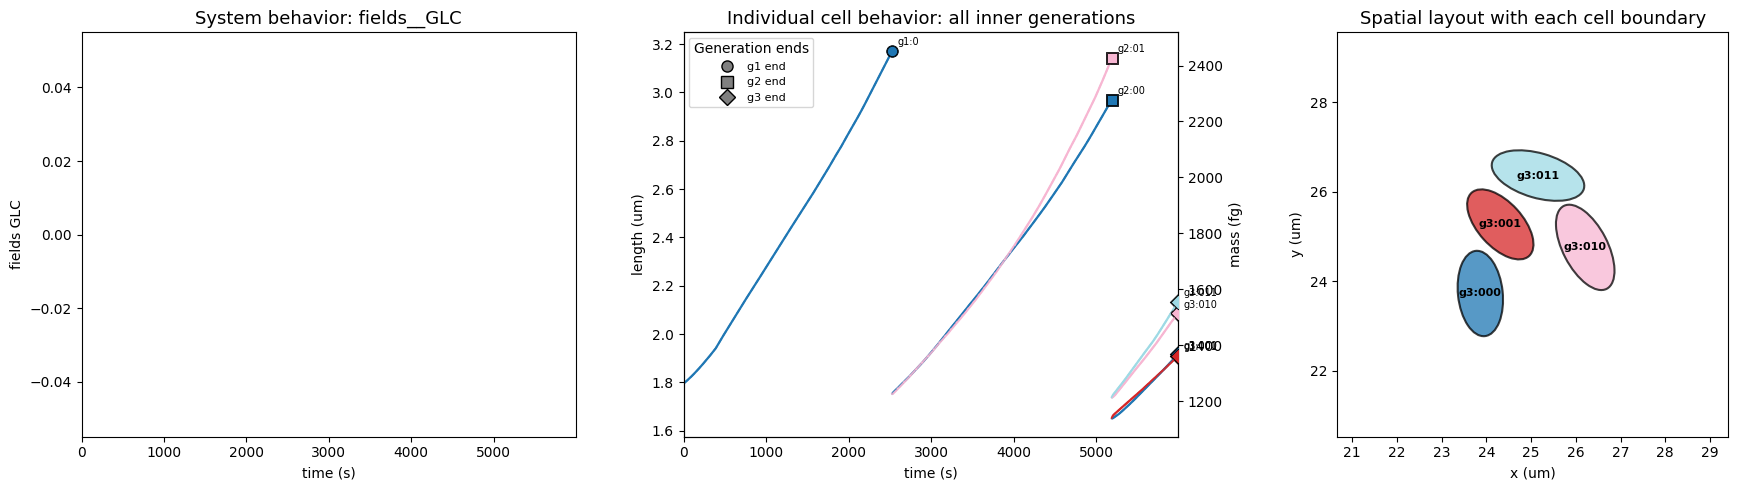

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "axes.titlesize": 13, "axes.labelsize": 10, "legend.fontsize": 8})

OUTER_RUN_DIR = Path("/home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test1/2026-08-23_20-47-32_975315%2B0000")
INNER_RUN_DIR = Path("/home/katha/dev/vEcoli-colony-sim/out/colony_runs/baseline_test1/2026-08-23_20-47-32_975315%2B0000__inner")

AMINO_ACID_HINTS = {"ALA", "ARG", "ASN", "ASP", "CYS", "GLN", "GLU", "GLY", "HIS", "ILE", "LEU", "LYS", "MET", "PHE", "PRO", "SER", "THR", "TRP", "TYR", "VAL", "L-ALANINE", "L-ASPARTATE", "L-GLUTAMATE", "L-GLUTAMINE"}


def parse_unit(value):
    if isinstance(value, str):
        match = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", value)
        return float(match.group(0)) if match else np.nan
    if isinstance(value, (list, tuple, np.ndarray)):
        return np.array([parse_unit(item) for item in value], dtype=float) if len(value) > 1 else parse_unit(value[0])
    return value


def to_numeric(series):
    return pd.to_numeric(series.map(parse_unit), errors="coerce")


def select_column(frame, suffix):
    matches = [column for column in frame.columns if column == suffix or column.endswith(suffix)]
    if not matches:
        raise KeyError(f"Could not find a column ending with {suffix!r}")
    return matches[0]


def history_root(root_dir):
    return next(root_dir.glob("history/experiment_id=*"))


def parse_agent_dir(agent_dir):
    generation = int(next(part.split("=", 1)[1] for part in agent_dir.parts if part.startswith("generation=")))
    agent_id = next(part.split("=", 1)[1] for part in agent_dir.parts if part.startswith("agent_id="))
    return generation, agent_id


def load_trajectory(agent_dir):
    generation, agent_id = parse_agent_dir(agent_dir)
    files = sorted(agent_dir.glob("*.pq"), key=lambda path: int(path.stem))
    trajectory = pd.concat([pd.read_parquet(path).assign(snapshot=int(path.stem)) for path in files], ignore_index=True)
    trajectory["time_s"] = pd.to_numeric(trajectory["time"], errors="coerce")
    trajectory["generation"] = generation
    trajectory["agent_id"] = agent_id
    trajectory["cell_id"] = f"g{generation}:{agent_id}"
    return trajectory


def load_agent_dirs(root_dir):
    return sorted([path for path in history_root(root_dir).glob("variant=0/lineage_seed=0/generation=*/agent_id=*") if path.is_dir()], key=parse_agent_dir)


def load_runs_by_generation(root_dir):
    return [load_trajectory(agent_dir) for agent_dir in load_agent_dirs(root_dir)]


def final_cell_summary(cell_runs):
    rows = []
    for trajectory in cell_runs:
        final_row = trajectory.iloc[-1]
        rows.append({
            "cell_id": trajectory["cell_id"].iat[0],
            "agent_id": trajectory["agent_id"].iat[0],
            "generation": int(trajectory["generation"].iat[0]),
            "time_s": float(final_row["time_s"]),
            "length_um": float(to_numeric(trajectory[select_column(trajectory, "boundary__length")]).iat[-1]),
            "mass_fg": float(to_numeric(trajectory[select_column(trajectory, "boundary__mass")]).iat[-1]),
            "width_um": float(parse_unit(final_row[select_column(trajectory, "boundary__width")])),
            "x_um": float(parse_unit(final_row[select_column(trajectory, "boundary__location")][0])),
            "y_um": float(parse_unit(final_row[select_column(trajectory, "boundary__location")][1])),
            "angle_rad": float(parse_unit(final_row[select_column(trajectory, "boundary__angle")])),
        })
    return pd.DataFrame(rows)


def draw_cell_boundary(ax, row, *, facecolor, edgecolor="black"):
    ax.add_patch(Ellipse((row["x_um"], row["y_um"]), width=row["length_um"], height=row["width_um"], angle=np.degrees(row["angle_rad"]), facecolor=facecolor, edgecolor=edgecolor, linewidth=1.5, alpha=0.75))
    ax.text(row["x_um"], row["y_um"], row["cell_id"], ha="center", va="center", fontsize=8, fontweight="bold", color="black")


def select_system_series(frame):
    field_cols = [c for c in frame.columns if c.startswith("fields__")]
    if field_cols:
        chosen = next((c for c in field_cols if "glc" in c.lower()), field_cols[0])
        return pd.to_numeric(frame[chosen], errors="coerce"), chosen, "raw shared-environment field value; not an average over cells"
    env_cols = [c for c in frame.columns if c.startswith("environment__exchange__")]
    aa_cols = [c for c in env_cols if any(token in c.upper() for token in AMINO_ACID_HINTS)]
    cols = aa_cols or env_cols
    if cols:
        values = frame[cols].apply(pd.to_numeric, errors="coerce")
        return values.mean(axis=1), cols[0], f"mean across {len(cols)} exchange columns"
    raise KeyError("Could not find a system-level environmental series in the outer trajectory.")


outer_trajectory = load_trajectory(load_agent_dirs(OUTER_RUN_DIR)[0])
inner_runs = load_runs_by_generation(INNER_RUN_DIR)

for trajectory in [outer_trajectory, *inner_runs]:
    trajectory["length_um"] = to_numeric(trajectory[select_column(trajectory, "boundary__length")])
    trajectory["mass_fg"] = to_numeric(trajectory[select_column(trajectory, "boundary__mass")])

leaf_generation = max(int(trajectory["generation"].iat[0]) for trajectory in inner_runs)
leaf_runs = [trajectory for trajectory in inner_runs if int(trajectory["generation"].iat[0]) == leaf_generation]
leaf_summary = final_cell_summary(leaf_runs).sort_values("agent_id").reset_index(drop=True)
leaf_agent_ids = leaf_summary["agent_id"].tolist()


def canonical_leaf_id(agent_id):
    matches = [leaf_id for leaf_id in leaf_agent_ids if leaf_id.startswith(agent_id)]
    return min(matches, key=lambda item: (len(item), item)) if matches else agent_id


color_keys = sorted({canonical_leaf_id(trajectory["agent_id"].iat[0]) for trajectory in inner_runs})
color_lookup = {key: color for key, color in zip(color_keys, plt.cm.tab20(np.linspace(0, 1, max(len(color_keys), 1))))}


def color_for_agent(agent_id):
    return color_lookup[canonical_leaf_id(agent_id)]


marker_map = {generation: marker for generation, marker in zip(sorted({int(t["generation"].iat[0]) for t in inner_runs}), ["o", "s", "D", "^", "v", "P", "X"])}
system_series, system_series_name, system_series_note = select_system_series(outer_trajectory)
outer_time_limit = float(outer_trajectory["time_s"].max())
inner_time_limit = float(max(trajectory["time_s"].max() for trajectory in inner_runs))

system_summary = pd.DataFrame({
    "plot": ["System view"],
    "tracked signal": [system_series_name.replace("__", " / ")],
    "x-axis": ["time (s)"],
    "y-axis meaning": [system_series_note],
    "value type": ["raw field" if system_series_name.startswith("fields__") else "mean exchange"],
    "x-axis max": [int(outer_time_limit)],
    "final value": [float(system_series.dropna().iat[-1]) if system_series.notna().any() else np.nan],
})

display(system_summary.round(4))
display(leaf_summary[["cell_id", "agent_id", "generation", "time_s", "length_um", "mass_fg"]].round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

system_ax = axes[0]
system_ax.plot(outer_trajectory["time_s"], system_series, color="tab:green", lw=1.8)
system_ax.set_title(f"System behavior: {system_series_name}")
system_ax.set_xlabel("time (s)", color="black")
system_ax.set_ylabel(system_series_name.replace("__", " "), color="black")
system_ax.set_xlim(0, outer_time_limit)
system_ax.tick_params(axis="both", colors="black", labelcolor="black")
for spine in system_ax.spines.values(): spine.set_color("black")

inner_ax = axes[1]
inner_mass_ax = inner_ax.twinx()
for trajectory in inner_runs:
    generation = int(trajectory["generation"].iat[0])
    agent_id = trajectory["agent_id"].iat[0]
    line_color = color_for_agent(agent_id)
    inner_ax.plot(trajectory["time_s"], trajectory["length_um"], color=line_color, lw=1.6)
    inner_mass_ax.plot(trajectory["time_s"], trajectory["mass_fg"], color=line_color, lw=1.2, ls="--", alpha=0.9)
    end_time = trajectory["time_s"].iat[-1]
    inner_ax.scatter(end_time, trajectory["length_um"].iat[-1], color=line_color, marker=marker_map[generation], s=70, edgecolor="black", linewidth=0.6, zorder=4)
    inner_mass_ax.scatter(end_time, trajectory["mass_fg"].iat[-1], color=line_color, marker=marker_map[generation], s=55, edgecolor="black", linewidth=0.6, zorder=4)
    inner_ax.annotate(f"g{generation}:{agent_id}", (end_time, trajectory["length_um"].iat[-1]), textcoords="offset points", xytext=(4, 4), fontsize=7, color="black")
inner_ax.set_title("Individual cell behavior: all inner generations")
inner_ax.set_xlabel("time (s)", color="black")
inner_ax.set_ylabel("length (um)", color="black")
inner_mass_ax.set_ylabel("mass (fg)", color="black")
inner_ax.set_xlim(0, inner_time_limit)
inner_ax.tick_params(axis="both", colors="black", labelcolor="black")
inner_mass_ax.tick_params(axis="y", colors="black", labelcolor="black")
for spine in inner_ax.spines.values(): spine.set_color("black")
for spine in inner_mass_ax.spines.values(): spine.set_color("black")
inner_ax.legend(handles=[Line2D([0], [0], marker=marker, color="w", markerfacecolor="gray", markeredgecolor="black", markersize=8, label=f"g{generation} end") for generation, marker in marker_map.items()], loc="upper left", title="Generation ends")

spatial_ax = axes[2]
for _, row in leaf_summary.iterrows():
    draw_cell_boundary(spatial_ax, row, facecolor=color_for_agent(row["agent_id"]))
x_pad = max(leaf_summary["length_um"].max(), leaf_summary["width_um"].max()) * 1.5
spatial_ax.set_xlim(leaf_summary["x_um"].min() - x_pad, leaf_summary["x_um"].max() + x_pad)
spatial_ax.set_ylim(leaf_summary["y_um"].min() - x_pad, leaf_summary["y_um"].max() + x_pad)
spatial_ax.set_aspect("equal")
spatial_ax.set_xlabel("x (um)", color="black")
spatial_ax.set_ylabel("y (um)", color="black")
spatial_ax.tick_params(axis="both", colors="black", labelcolor="black")
for spine in spatial_ax.spines.values(): spine.set_color("black")
spatial_ax.set_title("Spatial layout with each cell boundary")

fig.tight_layout()
plt.show()

# Debug - old branch

### Colony Simulation pq emission Debug

#### Debug Steps

**Problem Description**

I am using `ecoli_engine_process.py` for colony simulation under baseline conditions. While I can successfully save snapshots of the colony state, I continuously encounter errors when trying to emit Parquet files for single-cell data. I wonder if anyone has successfully done this without an online emitter?

The errors and attempted debugging steps are shown below. I noticed the implemented antibiotic simulation uses an online database as the emitter, so I included observations about that in the last section.

It could be a different underlying reason why my simulation failed, and I would appreciate any insights or suggestions!

**Environment**
- vEcoli commit: (current main branch)
- Python 3.12
- Config: `spatial.json` inheritance with `"emitter": "parquet"`

**Goal**

Resume a colony simulation from a saved JSON state file (`baseline_2gen_seed_0_colony_t6000.json`) and output to Parquet files.

**My Configuration File** / `configs/colony_baseline_test2.json`:
```json
{
    "inherit_from": ["spatial.json"],
    "description": "Test2: read from trial1, run for another generation, save parquet per cell, save final state",
    "initial_colony_file": "baseline_2gen_seed_0_colony_t6000",

    "seed": 0,
    "sim_data_path": "out/all_media_conditions1/parca/kb/simData.cPickle",
    
    "emitter": "parquet",
    "emitter_arg": {
        "out_dir": "out/colony_runs/baseline_3rd_gen_seed_0"
    },
    "emit_config": false,

    "max_duration": 9000,
    
    "save": true,
    "save_times": [9000],
    "colony_save_prefix": "baseline_3rd_gen",
    
    "parallel": false,
    
    "engine_process_reports": [
        ["boundary"],
        ["bulk"],
        ["listeners"],
        ["environment", "exchange"]
    ]
}
```

---

**Issue 1: `NumpyRandomStateSerializer` Serialization/Deserialization Mismatch**

- Command:
```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_baseline_test2.json
```

- Error:
```
Traceback (most recent call last):
  File "ecoli/experiments/ecoli_engine_process.py", line 526, in <module>
    run_simulation(config)
  File "ecoli/experiments/ecoli_engine_process.py", line 389, in run_simulation
    initial_state = get_state_from_file(...)
  File "ecoli/library/json_state.py", line 168, in get_state_from_file
    return json.loads(f.read(), object_hook=custom_decoder)
  File "ecoli/library/serialize.py", line 83, in deserialize
    data = orjson.loads(data)
orjson.JSONDecodeError: unexpected character: line 1 column 1 (char 0)
```

- Possible Root Cause:
  - `serialize()` at line 70-72 appears to output Python tuple format: `('MT19937', [...])`
  - `deserialize()` at line 82 uses `orjson.loads()` which expects JSON array format: `["MT19937", [...]]`

- File: `ecoli/library/serialize.py`

- Original code (lines 78-85):
```python
def deserialize(self, data):
    matched_regex = self.regex_for_serialized.fullmatch(data)
    if matched_regex:
        data = matched_regex.group(1)
    data = orjson.loads(data)
    rng = np.random.RandomState()
    rng.set_state(data)
    return rng
```

- Attempted Fix: Replace `orjson.loads()` with `ast.literal_eval()` to handle Python tuple format:
```python
def deserialize(self, data):
    import ast
    matched_regex = self.regex_for_serialized.fullmatch(data)
    if matched_regex:
        data = matched_regex.group(1)
    if data.startswith("("):
        data = ast.literal_eval(data)
    else:
        data = orjson.loads(data)
    rng = np.random.RandomState()
    rng.set_state(tuple(data))
    return rng
```

---

**Issue 2: Parquet Emitter Cannot Handle `pint.Quantity` in Config Metadata**

- Error (after attempting to fix Issue 1):
```
Traceback (most recent call last):
  File "ecoli/library/parquet_emitter.py", line 963, in emit
    v = np.asarray(v, dtype=np_dtype(v, k))
  File "ecoli/library/parquet_emitter.py", line 706, in np_dtype
    raise ValueError(f"{field_name} has unsupported type {type(val)}.")
ValueError: spatial_environment_config__multibody__bounds has unsupported type <class 'pint.Quantity'>.

During handling of the above exception, another exception occurred:
  File "ecoli/library/parquet_emitter.py", line 967, in emit
    v = pl.Series([v])
TypeError: not yet implemented: Nested object types
```

- Possible Root Cause:
  - `spatial.json` contains `pint.Quantity` values (e.g., `"!units[50 micrometer]"`)
  - `np_dtype()` doesn't appear to handle `pint.Quantity`, and falls back to Polars
  - `pl.Series([v])` also seems unable to handle `pint.Quantity` objects

- File: `ecoli/library/parquet_emitter.py`

- Original code (line 967):
```python
v = pl.Series([v])
```

- Attempted Fix: Convert unsupported types to string:
```python
v = pl.Series([str(v)])
```

---

**Issue 3: `emit_config` Setting Not Passed to Engine**

- Note: Even after the `str(v)` fix, I attempted to disable config emission via JSON config `"emit_config": false`, but it appeared to have no effect.

- Possible Root Cause: `ecoli_engine_process.py` does not seem to pass the `emit_config` parameter to the Engine constructor.

- File: `ecoli/experiments/ecoli_engine_process.py`

- Original code (around line 465):
```python
engine = Engine(
    processes=composite.processes,
    topology=composite.topology,
    initial_state=initial_state,
    experiment_id=experiment_id,
    emitter=emitter_config,
    progress_bar=config["progress_bar"],
    metadata=metadata,
    profile=config["profile"],
    initial_global_time=config.get("start_time", 0.0),
)
```

- Attempted Fix: Add `emit_config` parameter:
```python
engine = Engine(
    ...
    initial_global_time=config.get("start_time", 0.0),
    emit_config=config.get("emit_config", False),
)
```

---

**Issue 4: Parquet Emitter Assumes `agents` Key in Data Structure**

- Error (after attempting to fix Issues 1-3):
```
Traceback (most recent call last):
  File "ecoli/experiments/ecoli_engine_process.py", line 485, in run_simulation
    colony_save_states(engine, config)
  File "ecoli/experiments/ecoli_engine_process.py", line 255, in colony_save_states
    engine.update(time_to_next_save)
  ...
  File "ecoli/processes/engine_process.py", line 505, in next_update
    self.emitter.emit(emit_config)
  File "ecoli/library/parquet_emitter.py", line 1007, in emit
    if len(data["data"]["agents"]) > 1:
KeyError: 'agents'
```

- Possible Root Cause:
  - `ParquetEmitter.emit()` appears to expect a `data["data"]["agents"]` structure (outer simulation)
  - EngineProcess inner emitter seems to send cell data directly without the `agents` wrapper
  - The inner emitter is configured via `inner_emitter` in the EngineProcess config

- File: `ecoli/library/parquet_emitter.py` (line 1007)

- Potential Fix (not tested): Add check for both data structures:
```python
if "agents" in data["data"]:
    if len(data["data"]["agents"]) > 1:
        return
    for agent_data in data["data"]["agents"].values():
        ...
else:
    # Inner simulation from EngineProcess
    agent_data = data["data"].copy()
    ...
```

---

**Observations on Implemented Antibiotic Simulation**

The `tet_amp_sim.py` uses a different configuration that appears to avoid these issues:

```python
# From configs/cloud.json (inherited by antibiotics.json)
{
    "emitter": "database",  # MongoDB, not Parquet
    "emitter_arg": {"host": "10.138.0.75:27017", "emit_limit": 4100000}
}
```

- **MongoDB** can handle arbitrary Python objects including `pint.Quantity`
- No JSON serialization issues with `NumpyRandomState`
- No `agents` key structure assumptions

---

**Summary Table**

| Issue | File | Line | Status |
|-------|------|------|--------|
| 1. RandomState serialize/deserialize mismatch | `serialize.py` | 78-85 | Attempted fix with `ast.literal_eval()` |
| 2. `pint.Quantity` not supported | `parquet_emitter.py` | 967 | Attempted fix with `str(v)` |
| 3. `emit_config` not passed to Engine | `ecoli_engine_process.py` | ~470 | Attempted fix by adding parameter |
| 4. Missing `agents` key handling | `parquet_emitter.py` | 1007 | **UNRESOLVED** |

**Workaround**

Setting `"inner_emitter": "null"` in config may disable Parquet emission from inner EngineProcess simulations while the outer emitter should still work for colony-level data. (Not fully tested.)

#### Model Inner Structure Investigated

**Summary: Emitter System Investigation**

We traced the emitter initialization flow through vivarium-core:

- **`vivarium/core/engine.py`**: The `Engine` class constructor accepts `emitter` (string name or dict config) and `emit_config` (bool, default `False`). Calls `get_emitter()` to instantiate the emitter.

- **`vivarium/core/emitter.py`**: Contains `emitter_registry` (a `Registry` object) and `get_emitter()` function. Built-in emitters: `"timeseries"` (RAM), `"database"` (MongoDB), `"null"` (disabled). The `get_emitter()` function looks up the emitter class by name from the registry.

- **`ecoli/__init__.py`** (line 39): Registers vEcoli's custom Parquet emitter: `emitter_registry.register("parquet", ParquetEmitter)`. This makes `"emitter": "parquet"` available in config files.

Key insight: The antibiotic simulation uses `"database"` (MongoDB) which handles arbitrary Python objects natively, avoiding the serialization issues we encountered with the Parquet emitter.

### Further Debug

Debug for lower emission rate: The ecoli_master_engine has been added with emit_step and the parquet_emitter has been add boundary conditon with zero-shaped arrays.

Therefore, the 3rd gen simulation is rerun to check if these changes will make a difference in pq emission during colony simulation.

# Readings

## Env Factors - 2nd generation

### Load data

In [2]:
import json

with open('/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json', 'r') as f:
    data = json.load(f)

agents = data['agents']
agent_ids = sorted(agents.keys())

# Get all unique keys (categories) across all agents
all_keys = set()
for agent in agents.values():
    all_keys.update(agent.keys())

print("Agent names (IDs):")
print(agent_ids)
print("\nUnique categories (keys):")
print(sorted(all_keys))

Agent names (IDs):
['000', '001', '010', '011']

Unique categories (keys):
['allocate', 'allocator_rng', 'boundary', 'bulk', 'bulk_dtypes', 'cytoplasm', 'divide', 'division_threshold', 'division_trigger', 'environment', 'global_time', 'listeners', 'next_update_time', 'periplasm', 'process_state', 'request', 'timeline', 'timestep', 'unique', 'unique_dtypes']


In [3]:
# Show dtype and preview for each category for the first agent
sample_agent = agents[agent_ids[0]]
print(f"\n--- Data preview for agent '{agent_ids[0]}' ---")
for key in sorted(all_keys):
    value = sample_agent.get(key, None)
    print(f"\nCategory: '{key}'")
    print(f"Type: {type(value)}")
    if isinstance(value, dict):
        subkeys = sorted(value.keys())
        print(f"Exclusive subcategories: {subkeys}")
    elif isinstance(value, list):
        print(f"Length: {len(value)}")
        print(f"First 3 entries: {value[:3]}")
    else:
        print(f"Value: {value}")


--- Data preview for agent '000' ---

Category: 'allocate'
Type: <class 'dict'>
Exclusive subcategories: ['ecoli-chromosome-replication', 'ecoli-complexation', 'ecoli-equilibrium', 'ecoli-polypeptide-elongation', 'ecoli-polypeptide-initiation', 'ecoli-protein-degradation', 'ecoli-rna-degradation', 'ecoli-rna-maturation', 'ecoli-transcript-elongation', 'ecoli-transcript-initiation', 'ecoli-two-component-system']

Category: 'allocator_rng'
Type: <class 'str'>
Value: !RandomStateSerializer[('MT19937', [1032081874, 3921390043, 1775671866, 3050400842, 613040236, 3120117409, 313685, 4009028496, 3451362311, 1611313565, 1216908950, 1280315550, 2094310855, 486956331, 2341192965, 835091154, 3469137642, 701790974, 3147330632, 4284971845, 196483250, 3605856335, 2998782482, 1551059047, 772023894, 3028362759, 2054139155, 1697376821, 3256171168, 1295408492, 409809183, 2117531738, 1695919879, 3445769087, 3326475278, 232416836, 3552623864, 3205095980, 1077074508, 4278080904, 2968265471, 3704500986, 38

In ''bulk'', ''submass'' refers to the contribution of a chemical to a specific cellular mass compartment. The bulk_dtypes field lists submass types such as rRNA_submass, tRNA_submass, mRNA_submass, miscRNA_submass, nonspecific_RNA_submass, protein_submass, metabolite_submass, water_submass, DNA_submass.

For each chemical, only one submass field is typically non-zero, corresponding to the compartment that chemical belongs to. For example:

If the chemical is a protein, only protein_submass will be non-zero.
If it’s a metabolite, only metabolite_submass will be non-zero.
If it’s an rRNA, only rRNA_submass will be non-zero.

In [4]:
# Preview exclusive lists for both 'exchange' and 'media_id' subcategories across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_ids.add(env.get('media_id', None))

print("Exclusive list of all exchange chemicals across agents:")
print(sorted(exchange_keys))
print("\nExclusive list of all media_id values across agents:")
print(sorted(media_ids))


Exclusive list of all exchange chemicals across agents:
['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE', 'ARG', 'ASN', 'BETAINE', 'BUTANAL', 'CA+2', 'CARBON-DIOXIDE', 'CARBON-MONOXIDE', 'CH33ADO', 'CL-', 'CO+2', 'CPD-10774', 'CPD-108', 'CPD-1772', 'CPD-183', 'CPD-239', 'CPD-520', 'CPD-534', 'CPD-560', 'CPD-564', 'CPD0-1958', 'CYS', 'CYTIDINE', 'CYTOSINE', 'D-ALANINE', 'D-LACTATE', 'ETOH', 'FE+2', 'FE+3', 'FORMATE', 'FUM', 'GLC', 'GLC-D-LACTONE', 'GLN', 'GLT', 'GLY', 'GLYCEROL', 'GLYCOLALDEHYDE', 'GLYCOLLATE', 'HIS', 'HYDROGEN-MOLECULE', 'HYPOXANTHINE', 'ILE', 'IMIDAZOLE-PYRUVATE', 'INDOLE', 'K+', 'L-ALPHA-ALANINE', 'L-ASPARTATE', 'L-SELENOCYSTEINE', 'LEU', 'LYS', 'MAL', 'MET', 'METOH', 'MG+2', 'MI-PENTAKISPHOSPHATE', 'MN+2', 'NA+', 'NI+2', 'NITRATE', 'NITRITE', 'OXYGEN-MOLECULE', 'PHE', 'PRO', 'PROTON', 'Pi', 'S-ADENOSYL-4-METHYLTHIO-2-OXOBUTANOATE', 'S-ADENOSYLMETHIONINE', 'SER', 'SUC', 'SULFATE', 'THR', 'THYMINE', 'TRP', 'TUNGSTATE', 'TYR', 'UNDECAPRENYL-DIPHOSPH

**Preview of 'environment' subcategories for the first agent**

- **exchange**: Dictionary of chemicals exchanged between cell and environment.
    - Keys ex: ['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE']
    - Each key represents a chemical compound relevant to E. coli's metabolism in minimal media.
    - Example values: Show first few exchange rates if available.

- **media_id**: String indicating the media type.
    - Value ex: 'minimal'
    - This specifies the simulation is run in minimal medium, restricting available nutrients.

**Brief explanations of the first 5 exchange chemicals:**

- **4FE-4S**: Iron-sulfur cluster, essential for enzyme function and electron transfer.
- **5-Deoxy-D-Ribofuranose**: Rare sugar, involved in nucleotide metabolism.
- **ACET**: Acetate, carbon source and metabolic byproduct.
- **AMMONIUM**: Ammonium ion, primary nitrogen source.
- **ARABINOSE**: Arabinose, pentose sugar, alternative carbon source.


In [5]:
# Confirm that all agents have exactly 5 environment exchanges
exchange_counts = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_counts.append(len(exchange))

unique_counts = set(exchange_counts)
print(f"Unique exchange counts across all agents: {unique_counts}")
if unique_counts == {5}:
    print("All agents have exactly 5 environment exchanges.")
else:
    print(f"Some agents have different numbers of exchanges: {unique_counts}")
# Optionally, print agent IDs with non-5 exchanges
for agent_id, count in zip(agent_ids, exchange_counts):
    if count != 5:
        print(f"Agent {agent_id} has {count} exchanges.")


Unique exchange counts across all agents: {87}
Some agents have different numbers of exchanges: {87}
Agent 000 has 87 exchanges.
Agent 001 has 87 exchanges.
Agent 010 has 87 exchanges.
Agent 011 has 87 exchanges.


In [6]:
import os
import pandas as pd

# Collect exclusive lists for exchange chemicals and media_ids across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_id = env.get('media_id', None)
    if media_id is not None:
        media_ids.add(media_id)

# Prepare DataFrame
results_df = pd.DataFrame({
    'exchange_chemical': sorted(exchange_keys),
})

# Save unique media_ids separately
media_ids_path = '/user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv'
pd.DataFrame({'media_id': sorted(media_ids)}).to_csv(media_ids_path, index=False)

# Ensure output directory exists
output_dir = '/user/home/il22158/work/vEcoli/reading/results/colony'
os.makedirs(output_dir, exist_ok=True)

# Save unique exchange chemicals
output_path = os.path.join(output_dir, 'unique_exchanges.csv')
results_df.to_csv(output_path, index=False)
print(f"Saved unique exchange chemicals to: {output_path}")
print(f"Saved unique media_ids to: {media_ids_path}")

Saved unique exchange chemicals to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_exchanges.csv
Saved unique media_ids to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv


### Heatmap

/tmp/ipykernel_908641/95777993.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


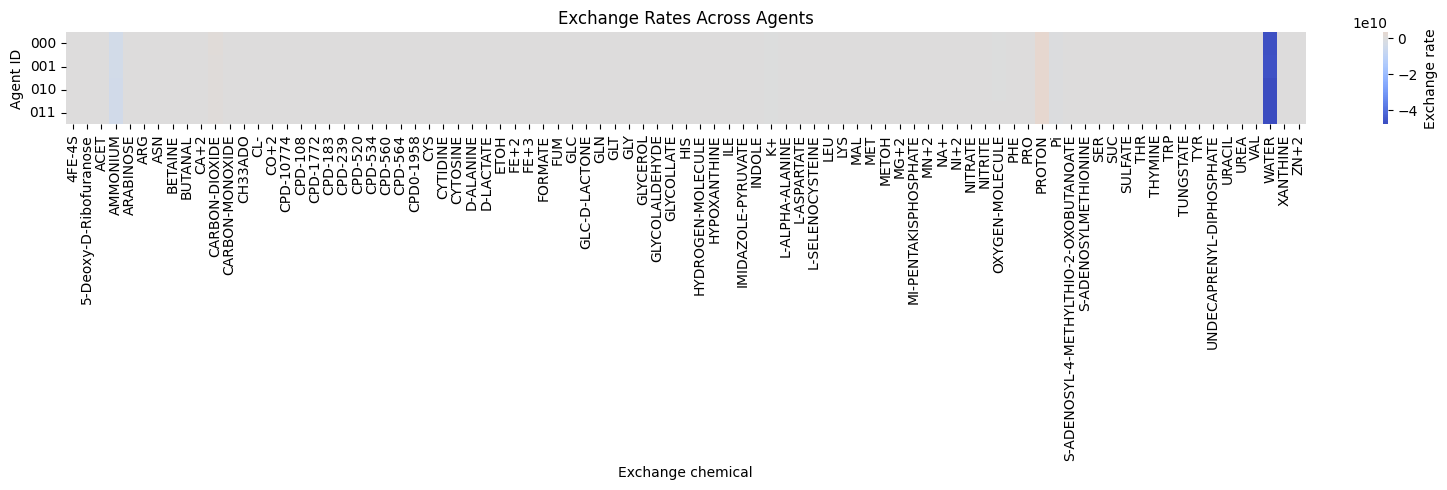

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Plot heatmap
plt.figure(figsize=(min(20, 0.5*len(exchange_df.columns)), min(12, 0.3*len(exchange_df))))
sns.heatmap(exchange_df, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Exchange rate'})
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

/tmp/ipykernel_908641/3420995705.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


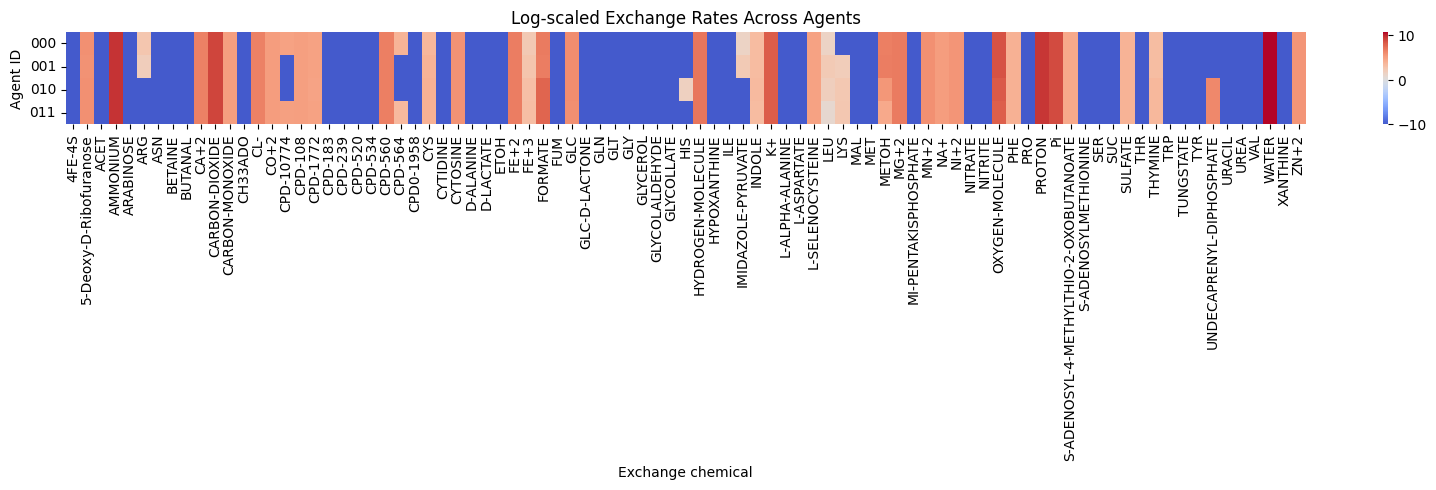

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_exchange_df = np.log10(np.abs(exchange_df) + e1)

# Plot heatmap
plt.figure(figsize=(min(20, 0.5*len(log_exchange_df.columns)), min(12, 0.3*len(log_exchange_df))))
sns.heatmap(log_exchange_df, cmap='coolwarm', center=0, annot=False)
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Log-scaled Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

/tmp/ipykernel_908641/3316751008.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


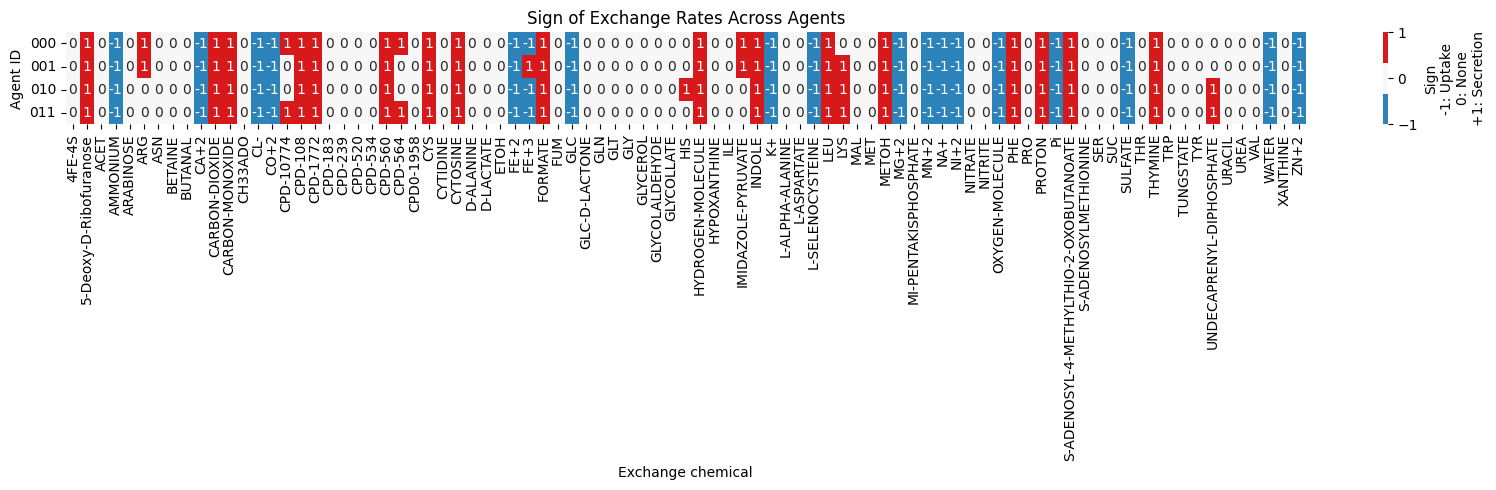

In [9]:
# Plot sign of exchange readings for each agent and chemical
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assumes exchange_df is defined: rows=agent_id, columns=chemicals
# If not, recreate exchange_df from your data as in previous cells

# Compute sign matrix: -1 (uptake), 0 (none), +1 (secretion)
sign_df = np.sign(exchange_df)

plt.figure(figsize=(min(20, 0.5*len(sign_df.columns)), min(12, 0.3*len(sign_df))))
sns.heatmap(sign_df, cmap=sns.color_palette(["#2b83ba", "#f7f7f7", "#d7191c"], as_cmap=True), center=0, annot=True, fmt="d",
            cbar_kws={'label': 'Sign\n-1: Uptake\n0: None\n+1: Secretion'})
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Sign of Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

In [10]:
# Show first 5 zero exchange readings (agent, chemical, value)
import pandas as pd

# Find zero entries in exchange_df
zero_entries = []
for agent in exchange_df.index:
    for chem in exchange_df.columns:
        if exchange_df.loc[agent, chem] == 0:
            zero_entries.append((agent, chem, 0))
            if len(zero_entries) == 5:
                break
    if len(zero_entries) == 5:
        break

# Display
print("First 5 zero exchange readings:")
for entry in zero_entries:
    print(f"Agent: {entry[0]}, Chemical: {entry[1]}, Value: {entry[2]}")

First 5 zero exchange readings:
Agent: 000, Chemical: 4FE-4S, Value: 0
Agent: 000, Chemical: ACET, Value: 0
Agent: 000, Chemical: ARABINOSE, Value: 0
Agent: 000, Chemical: ASN, Value: 0
Agent: 000, Chemical: BETAINE, Value: 0


/tmp/ipykernel_908641/1856500740.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


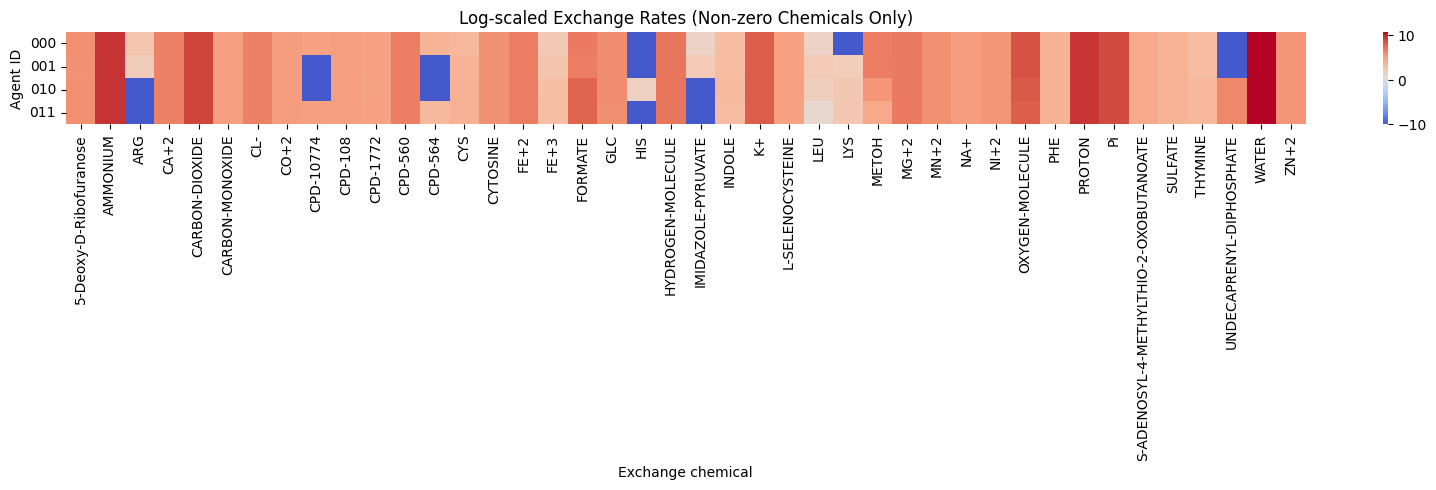

In [11]:
# Plot log-scaled heatmap for chemicals with at least one non-zero value
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter columns (chemicals) with at least one non-zero value
nonzero_chems = exchange_df.columns[(exchange_df != 0).any(axis=0)]
filtered_df = exchange_df[nonzero_chems]

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_filtered_df = np.log10(np.abs(filtered_df) + e1)

plt.figure(figsize=(min(20, 0.5*len(log_filtered_df.columns)), min(12, 0.3*len(log_filtered_df))))
sns.heatmap(log_filtered_df, cmap='coolwarm', center=0, annot=False)
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Log-scaled Exchange Rates (Non-zero Chemicals Only)')
plt.tight_layout()
plt.show()

### Extract exchange rates

In [17]:
from pathlib import Path
import re

import pandas as pd

project_name = "baseline_2gen_seed_0_colony_t6000"

def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()

# Build wide matrix first: rows=agents, columns=chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get("environment", {})
    exchange = env.get("exchange", {})

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange_rate": exchange_df.mean(axis=0).values,
        "mean_abs_exchange_rate": exchange_df.abs().mean(axis=0).values,
        "max_exchange_rate": exchange_df.max(axis=0).values,
        "min_exchange_rate": exchange_df.min(axis=0).values,
        "max_abs_exchange_rate": exchange_df.abs().max(axis=0).values,
    }
).sort_values(
    by="max_abs_exchange_rate",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange_rate,mean_abs_exchange_rate,max_exchange_rate,min_exchange_rate,max_abs_exchange_rate
0,WATER,-4.732753e+10,4.732753e+10,-46653325381,-47946468814,47946468814
1,AMMONIUM,-4.115869e+09,4.115869e+09,-4075870702,-4149945034,4149945034
2,PROTON,3.471591e+09,3.471591e+09,3493226680,3445322140,3493226680
3,CARBON-DIOXIDE,1.048475e+09,1.048475e+09,1091144721,997691067,1091144721
4,Pi,-6.368939e+08,6.368939e+08,-630611371,-642199447,642199447
...,...,...,...,...,...,...
82,TYR,0.000000e+00,0.000000e+00,0,0,0
83,UREA,0.000000e+00,0.000000e+00,0,0,0
84,URACIL,0.000000e+00,0.000000e+00,0,0,0
85,VAL,0.000000e+00,0.000000e+00,0,0,0


Shape: (87, 6)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_2gen_seed_0_colony_t6000.csv


In [12]:
import json
import math
import re

UNIT_RE = re.compile(r"^!units\[(.+?)\s+([^\]]+)\]$", re.IGNORECASE)

def parse_units_token(raw):
    """
    raw: e.g. '!units[0.987 millimolar]' or '!units[inf millimolar]'
    returns dict with value, unit, is_inf, is_units_token
    """
    if not isinstance(raw, str):
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    m = UNIT_RE.match(raw.strip())
    if not m:
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    val_str, unit = m.group(1).strip(), m.group(2).strip()
    is_inf = val_str.lower() in {"inf", "+inf", "infinity", "+infinity", "∞"}

    if is_inf:
        value = math.inf
    else:
        value = float(val_str)

    return {"value": value, "unit": unit, "is_inf": is_inf, "is_units_token": True}


# Example: read from colony JSON and mark infinite-availability entities
with open("/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json", "r") as f:
    data = json.load(f)

agents = data["agents"]
inf_entities = set()

for agent_id, agent in agents.items():
    ext = agent.get("boundary", {}).get("external", {})
    for mol, raw in ext.items():
        parsed = parse_units_token(raw)
        if parsed["is_inf"] and parsed["unit"].lower() == "millimolar":
            inf_entities.add(mol)

print("Inf-available molecules:", sorted(inf_entities))

# Later comparison: exclude these
# filtered_df = df[~df["chemical"].isin(inf_entities)]

Inf-available molecules: ['CARBON-DIOXIDE', 'CO+2', 'FE+2', 'L-SELENOCYSTEINE', 'MN+2', 'NI+2', 'OXYGEN-MOLECULE', 'WATER', 'ZN+2']


In [13]:
out_dir = Path("/user/home/il22158/work/vEcoli/reading/results/colony")
file_name = f"inf_available_chemicals__{project_name}.csv"
out_path = out_dir / file_name
pd.DataFrame({"chemical": sorted(inf_entities)}).to_csv(out_path, index=False)
print(f"Saved inf-available chemicals: {out_path}")

Saved inf-available chemicals: /user/home/il22158/work/vEcoli/reading/results/colony/inf_available_chemicals__baseline_2gen_seed_0_colony_t6000.csv


In [15]:
import json

json_path = "/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json"

with open(json_path, "r") as f:
    data = json.load(f)

agents = data["agents"]

# Print mmol_to_counts for each agent (raw value from JSON)
for agent_id in sorted(agents):
    mmol_to_counts = agents[agent_id].get("boundary", {}).get("mmol_to_counts")
    print(agent_id, mmol_to_counts)

000 !units[771553.3883459674 / millimolar]
001 !units[762474.9073928331 / millimolar]
010 !units[772383.1576104428 / millimolar]
011 !units[776935.0041671057 / millimolar]


Clarification:

In the code, mmol_to_counts is defined as Avogadro × volume, then converted to L/mmol, not as a concentration value itself: derive_globals.py:82, derive_globals.py:121, derive_globals.py:139-144.

In the exchange process, they explicitly say concentrations are mmol/L, then multiply by mmol_to_counts to get counts: exchange.py:57-64.

In [16]:
from pathlib import Path
import re
import pandas as pd

project_name = "baseline_2gen_seed_0_colony_t6000"


def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()


def parse_units_number(value):
    # Works for strings like "!units[771553.3883459674 / millimolar]"
    if isinstance(value, str):
        m = re.search(r"\[([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)", value)
        if m:
            return float(m.group(1))
    return float(value)


def counts_to_mM(delta_counts, mmol_to_counts_raw):
    mmol_to_counts = parse_units_number(mmol_to_counts_raw)  # counts per mM
    if mmol_to_counts <= 0:
        return pd.NA
    return delta_counts / mmol_to_counts  # mM per step


# Build wide matrix first: rows=agents, columns=chemicals, values=exchange (mM per step)
exchange_data = []
for agent_id in agent_ids:
    agent = agents[agent_id]
    env = agent.get("environment", {})
    boundary = agent.get("boundary", {})
    exchange = env.get("exchange", {})

    mmol_to_counts_raw = boundary.get("mmol_to_counts")

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = counts_to_mM(rate, mmol_to_counts_raw)
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange": exchange_df.mean(axis=0).values,
        "mean_abs_exchange": exchange_df.abs().mean(axis=0).values,
        "max_exchange": exchange_df.max(axis=0).values,
        "min_exchange": exchange_df.min(axis=0).values,
        "max_abs_exchange": exchange_df.abs().max(axis=0).values,
        "unit": "mM",
    }
).sort_values(
    by="max_abs_exchange",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}__mM.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange,mean_abs_exchange,max_exchange,min_exchange,max_abs_exchange,unit
0,WATER,-61396.338986,61396.338986,-60893.162160,-61793.161915,61793.161915,mM
1,AMMONIUM,-5339.490276,5339.490276,-5303.856184,-5367.093398,5367.093398,mM
2,PROTON,4503.720369,4503.720369,4518.603965,4484.076374,4518.603965,mM
3,CARBON-DIOXIDE,1360.462602,1360.462602,1414.218040,1284.137105,1414.218040,mM
4,Pi,-826.237690,826.237690,-819.899961,-831.451904,831.451904,mM
...,...,...,...,...,...,...,...
82,TYR,0.000000,0.000000,0.000000,0.000000,0.000000,mM
83,UREA,0.000000,0.000000,0.000000,0.000000,0.000000,mM
84,URACIL,0.000000,0.000000,0.000000,0.000000,0.000000,mM
85,VAL,0.000000,0.000000,0.000000,0.000000,0.000000,mM


Shape: (87, 7)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_2gen_seed_0_colony_t6000__mM.csv


gDCW means grams of Dry Cell Weight: the cell mass excluding water.

So mmol/gDCW/h means “millimoles exchanged per gram of dry biomass per hour,” which normalizes flux by cell size.

### Bar plot

<Figure size 2800x700 with 0 Axes>

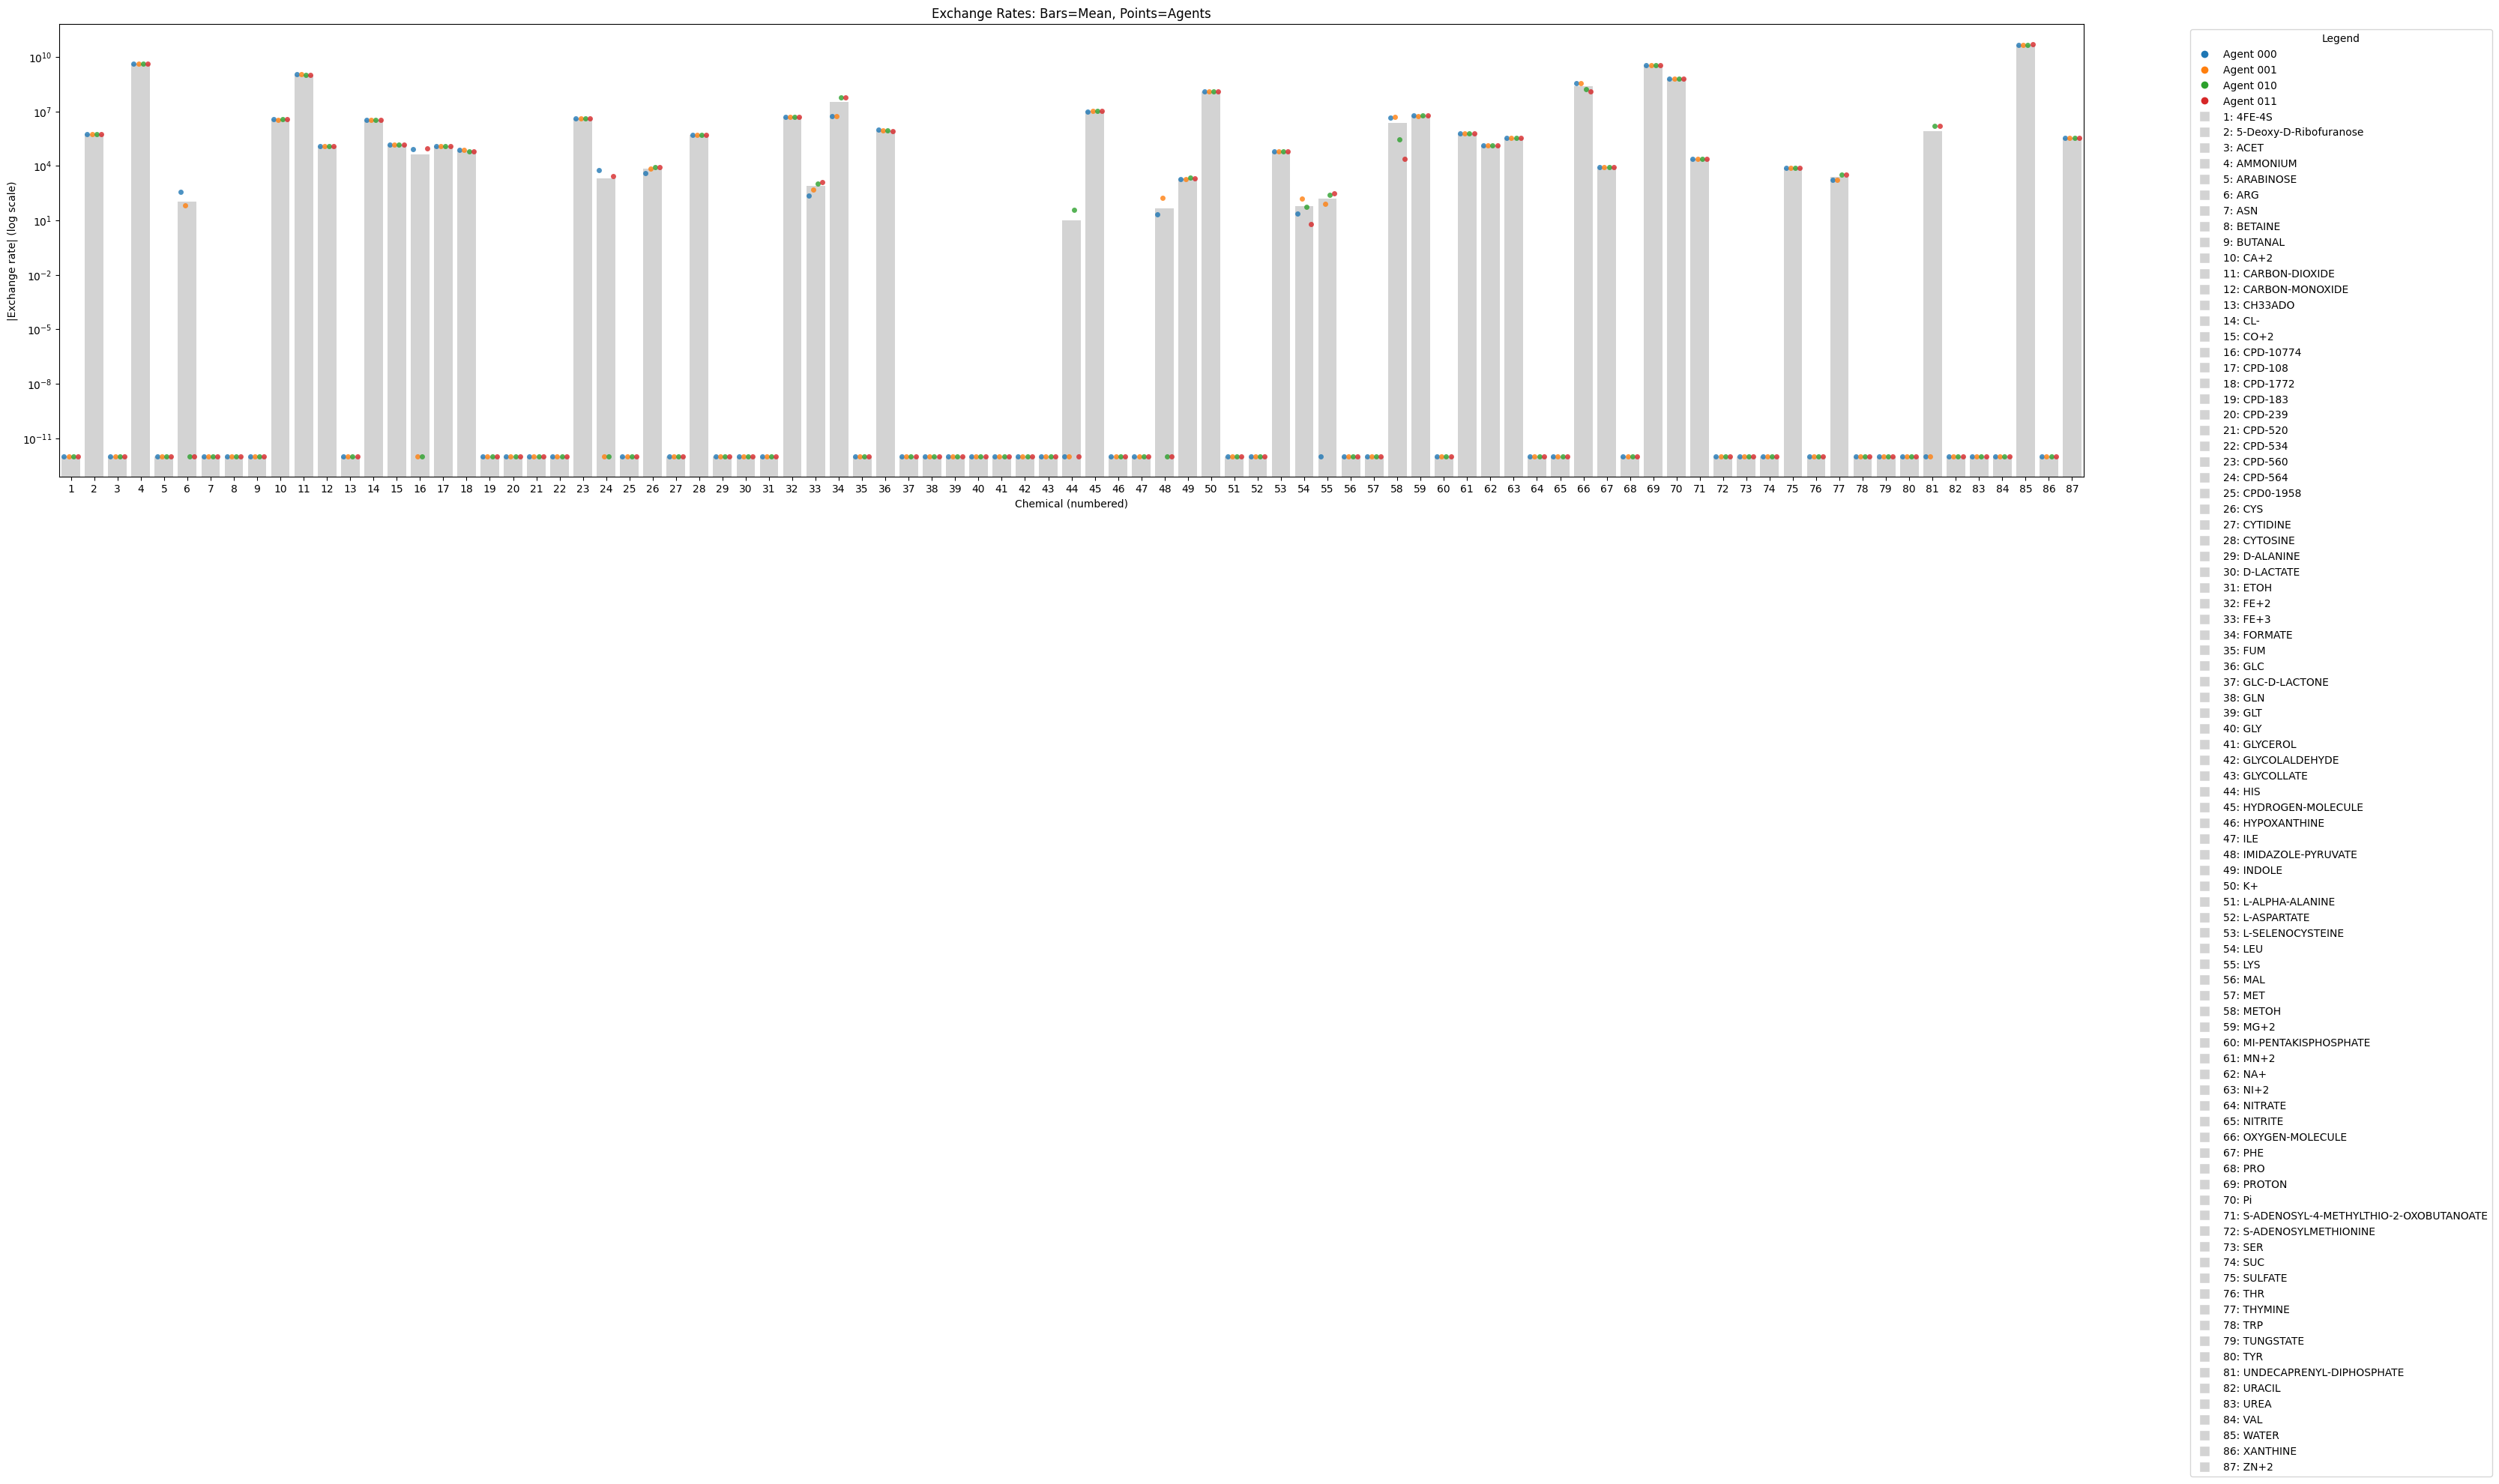

In [17]:
# Plot: Each chemical as a bar group, each agent as a point (dot strip) on log scale
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Recreate df_melt for this cell
# Assumes exchange_df is defined: rows=agent_id, columns=chemicals
# If not, you can create exchange_df from your data as in previous cells

df_melt = exchange_df.reset_index().melt(id_vars='agent_id', var_name='chemical', value_name='rate')

# Widen the figure for better x-axis spacing
fig_width = max(12, min(2 + len(exchange_df.columns) * 2.2, 28))
plt.figure(figsize=(fig_width, 7))
df_melt['abs_rate'] = np.abs(df_melt['rate']) + 1e-12
mean_rates = df_melt.groupby('chemical')['abs_rate'].mean().reset_index()

# Assign numbers to chemicals
chemical_labels = list(mean_rates['chemical'])
chemical_numbers = {chem: i+1 for i, chem in enumerate(chemical_labels)}
df_melt['chem_num'] = df_melt['chemical'].map(chemical_numbers)
mean_rates['chem_num'] = mean_rates['chemical'].map(chemical_numbers)

# Plot using chemical numbers as x
plt.figure(figsize=(fig_width, 7))
sns.barplot(data=mean_rates, x='chem_num', y='abs_rate', color='lightgray', zorder=1)
# Use hue for agent_id to color dots by agent
sns.stripplot(data=df_melt, x='chem_num', y='abs_rate', hue='agent_id',
              dodge=True, jitter=True, marker='o', alpha=0.8, zorder=2, legend=False)

plt.yscale('log')
plt.xlabel('Chemical (numbered)')
plt.ylabel('|Exchange rate| (log scale)')
plt.title('Exchange Rates: Bars=Mean, Points=Agents')
plt.tight_layout()

# Set x-ticks to numbers and show mapping in legend
plt.xticks(ticks=range(len(chemical_labels)), labels=[f"{i+1}" for i in range(len(chemical_labels))])

# Build legend: mapping number to chemical and agent colors
# Get agent colors from seaborn palette
unique_agents = sorted(df_melt['agent_id'].unique())
palette = sns.color_palette(n_colors=len(unique_agents))
agent_color_map = dict(zip(unique_agents, palette))

legend_elements = [
    *[Line2D([0], [0], marker='o', color='w', label=f"Agent {agent}", markerfacecolor=agent_color_map[agent], markersize=8)
      for agent in unique_agents],
    *[Line2D([0], [0], marker='s', color='w', label=f"{i+1}: {chem}", markerfacecolor='lightgray', markersize=10)
      for i, chem in enumerate(chemical_labels)]
]
plt.legend(handles=legend_elements, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

- Definition:
"Exchange reading" refers to the process of tracking the movement of molecules between the cell and its environment, typically implemented as "exchange reactions" in metabolic models. In the codebase, this is handled by the Exchange process, which updates molecule counts based on uptake and secretion rates.

- Directionality:
The convention in the code (see modular_fba.py) is that exchange fluxes are defined as pointing out of the system (cell), even though exchanges can represent both import (uptake) and export (secretion).
The sign of the exchange value is not always positive:
Uptake (import) is typically represented as a negative flux (into the cell).
Secretion (export) is positive (out of the cell).

- Summary:

1. Exchange readings can be positive or negative, depending on whether the molecule is being taken up or secreted.
2. The codebase uses negative values for uptake and positive for secretion, following standard metabolic modeling conventions.

- References:

1. exchange.py: Implements molecule movement with uptake and secretion rates.
2. modular_fba.py: Exchange reactions are set as pointing out of the system, but can represent both directions.

## Spatial Layout - 2nd generation

In [ ]:
import json
with open('/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json', 'r') as f:
    data = json.load(f)

# Check boundary (positions), listeners (growth rate), timeline
agent = data['agents']['000']
print('=== boundary (spatial info) ===')
print(agent.get('boundary', 'N/A'))
print()
print('=== listeners keys ===')
if 'listeners' in agent:
    print(list(agent['listeners'].keys())[:20])
print()
print('=== global_time ===')
print(agent.get('global_time', 'N/A'))
print()
print('=== timeline sample ===')
tl = agent.get('timeline', [])
print('Timeline length:', len(tl) if tl else 0)
print('First item:', tl[0][:100] if tl else 'empty')

=== boundary (spatial info) ===
{'external': {'ARG': '!units[0.0 millimolar]', 'ASN': '!units[0.0 millimolar]', 'CYS': '!units[0.0 millimolar]', 'GLN': '!units[0.0 millimolar]', 'GLT': '!units[0.0 millimolar]', 'GLY': '!units[0.0 millimolar]', 'HIS': '!units[0.0 millimolar]', 'ILE': '!units[0.0 millimolar]', 'L-ALPHA-ALANINE': '!units[0.0 millimolar]', 'L-ASPARTATE': '!units[0.0 millimolar]', 'L-SELENOCYSTEINE': '!units[inf millimolar]', 'LEU': '!units[0.0 millimolar]', 'LYS': '!units[0.0 millimolar]', 'MET': '!units[0.0 millimolar]', 'PHE': '!units[0.0 millimolar]', 'PRO': '!units[0.0 millimolar]', 'SER': '!units[0.0 millimolar]', 'THR': '!units[0.0 millimolar]', 'TRP': '!units[0.0 millimolar]', 'TYR': '!units[0.0 millimolar]', 'VAL': '!units[0.0 millimolar]', 'GLC': '!units[0.9870576641167453 millimolar]', 'ACET': '!units[0.0 millimolar]', 'FUM': '!units[0.0 millimolar]', 'MAL': '!units[0.0 millimolar]', 'SUC': '!units[0.0 millimolar]', 'OXYGEN-MOLECULE': '!units[inf millimolar]', 'A

KeyError: 0

In [ ]:
import json
with open('/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json', 'r') as f:
    data = json.load(f)

agent = data['agents']['000']
# Check mass listener for growth rate
print('=== mass listener ===')
mass = agent['listeners'].get('mass', {})
print(list(mass.keys()) if isinstance(mass, dict) else mass[:5])
print()
# Check growth_limits
print('=== growth_limits listener ===')
gl = agent['listeners'].get('growth_limits', {})
print(list(gl.keys()) if isinstance(gl, dict) else gl[:5])
print()
# Check dimensions
print('=== dimensions (spatial field) ===')
print(data['dimensions'])

=== mass listener ===
['cell_mass', 'water_mass', 'dry_mass', 'rna_mass', 'rRna_mass', 'tRna_mass', 'mRna_mass', 'dna_mass', 'protein_mass', 'smallMolecule_mass', 'volume', 'protein_mass_fraction', 'rna_mass_fraction', 'growth', 'instantaneous_growth_rate', 'dry_mass_fold_change', 'protein_mass_fold_change', 'rna_mass_fold_change', 'small_molecule_fold_change', 'projection_mass', 'cytosol_mass', 'extracellular_mass', 'flagellum_mass', 'membrane_mass', 'outer_membrane_mass', 'periplasm_mass', 'pilus_mass', 'inner_membrane_mass', 'expected_mass_fold_change']

=== growth_limits listener ===
['fraction_trna_charged', 'aa_allocated', 'aa_pool_size', 'aa_request_size', 'active_ribosome_allocated', 'net_charged', 'aas_used', 'aa_count_diff', 'original_aa_supply', 'aa_in_media', 'synthetase_conc', 'uncharged_trna_conc', 'charged_trna_conc', 'aa_conc', 'ribosome_conc', 'fraction_aa_to_elongate', 'aa_supply', 'aa_synthesis', 'aa_import', 'aa_export', 'aa_importers', 'aa_exporters', 'aa_supply_en

: 

: 

Colony snapshot at t=6000.0s | 4 cells: ['000', '001', '010', '011']
cell_id  growth_rate   length        mass  ppgpp_conc
    000     0.000268 1.964601 1409.313998   52.228365
    001     0.000257 1.945407 1392.731309   59.362662
    010     0.000260 1.966355 1410.829649   60.086722
    011     0.000231 1.975979 1419.144020   69.293385


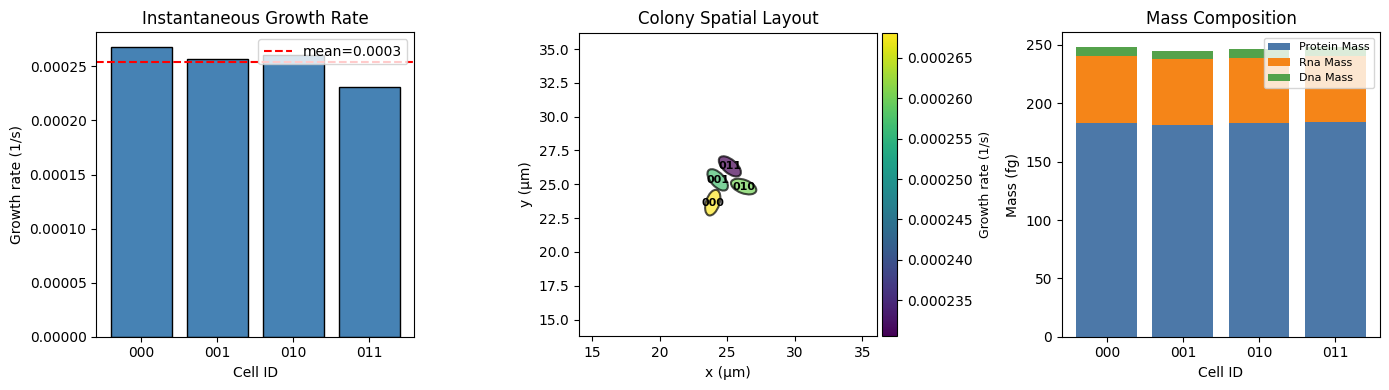


--- Colony Summary ---
Growth rate: 0.00025 ± 0.00002 /s
Cell length: 1.96 ± 0.01 μm
ppGpp conc:  60.243 ± 6.999


: 

: 

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re

# Load colony snapshot
json_path = '/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json'
with open(json_path, 'r') as f:
    colony_data = json.load(f)

def parse_unit(val):
    """Extract numeric value from unit string like '!units[1.23 micrometer]'"""
    if isinstance(val, str) and val.startswith('!units['):
        match = re.search(r'\[([-\d.eE+]+)', val)
        return float(match.group(1)) if match else np.nan
    return val

# Extract data for all cells
agents = colony_data['agents']
cell_ids = sorted(agents.keys())
print(f"Colony snapshot at t={agents[cell_ids[0]]['global_time']}s | {len(cell_ids)} cells: {cell_ids}")

# Build summary dataframe
cell_data = []
for cid in cell_ids:
    a = agents[cid]
    b = a['boundary']
    m = a['listeners']['mass']
    gl = a['listeners']['growth_limits']
    
    cell_data.append({
        'cell_id': cid,
        'x': parse_unit(b['location'][0]),
        'y': parse_unit(b['location'][1]),
        'angle': b['angle'],
        'length': parse_unit(b['length']),
        'width': parse_unit(b['width']),
        'volume': parse_unit(b['volume']),
        'mass': parse_unit(b['mass']),
        'growth_rate': m['instantaneous_growth_rate'],
        'dry_mass': m['dry_mass'],
        'protein_mass': m['protein_mass'],
        'rna_mass': m['rna_mass'],
        'dna_mass': m['dna_mass'],
        'frac_trna_charged': np.mean(gl['fraction_trna_charged']),
        'ppgpp_conc': gl['ppgpp_conc'],
    })

import pandas as pd
df = pd.DataFrame(cell_data)
print(df[['cell_id', 'growth_rate', 'length', 'mass', 'ppgpp_conc']].to_string(index=False))

# --- Plot 1: Growth rate comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.bar(df['cell_id'], df['growth_rate'], color='steelblue', edgecolor='k')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Growth rate (1/s)')
ax.set_title('Instantaneous Growth Rate')
ax.axhline(df['growth_rate'].mean(), color='red', linestyle='--', label=f"mean={df['growth_rate'].mean():.4f}")
ax.legend()

# --- Plot 2: Spatial colony layout with colorbar ---
ax = axes[1]
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Normalize growth rate for colormap
norm = mcolors.Normalize(vmin=df['growth_rate'].min(), vmax=df['growth_rate'].max())
cmap = plt.cm.viridis

for _, row in df.iterrows():
    from matplotlib.patches import Ellipse
    ellipse = Ellipse((row['x'], row['y']), width=row['length'], height=row['width'],
                      angle=np.degrees(row['angle']), alpha=0.7, edgecolor='k', linewidth=1.5,
                      facecolor=cmap(norm(row['growth_rate'])))
    ax.add_patch(ellipse)
    ax.text(row['x'], row['y'], row['cell_id'], ha='center', va='center', fontsize=8, color='black', fontweight='bold')

# Auto-scale to cell positions with padding
pad = df['length'].max() * 5
ax.set_xlim(df['x'].min() - pad, df['x'].max() + pad)
ax.set_ylim(df['y'].min() - pad, df['y'].max() + pad)
ax.set_aspect('equal')
ax.set_xlabel('x (μm)')
ax.set_ylabel('y (μm)')
ax.set_title('Colony Spatial Layout')

# Add colorbar for growth rate
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Growth rate (1/s)', fontsize=9)

# --- Plot 3: Mass composition ---
ax = axes[2]
mass_components = ['protein_mass', 'rna_mass', 'dna_mass']
x = np.arange(len(cell_ids))
bottom = np.zeros(len(cell_ids))
colors = ['#4c78a8', '#f58518', '#54a24b']
for comp, c in zip(mass_components, colors):
    ax.bar(x, df[comp], bottom=bottom, label=comp.replace('_', ' ').title(), color=c)
    bottom += df[comp].values
ax.set_xticks(x)
ax.set_xticklabels(cell_ids)
ax.set_xlabel('Cell ID')
ax.set_ylabel('Mass (fg)')
ax.set_title('Mass Composition')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# --- Additional: Key colony metrics ---
print(f"\n--- Colony Summary ---")
print(f"Growth rate: {df['growth_rate'].mean():.5f} ± {df['growth_rate'].std():.5f} /s")
print(f"Cell length: {df['length'].mean():.2f} ± {df['length'].std():.2f} μm")
print(f"ppGpp conc:  {df['ppgpp_conc'].mean():.3f} ± {df['ppgpp_conc'].std():.3f}")

**Spatial Graph Construction:**
Each cell is drawn as an **ellipse** using `matplotlib.patches.Ellipse` with:
- **Position**: `(x, y)` from `boundary['location']` (cell centroid in μm)
- **Size**: `width=length`, `height=width` (cell dimensions in μm)
- **Orientation**: `angle` from `boundary['angle']` (converted to degrees)
- **Color**: mapped to growth rate via `viridis` colormap (brighter = faster growth)

The plot auto-scales to the cell bounding box + 5× max cell length as padding.

## Spatial Layout - 3rd gen

Colony snapshot at t=9000.0s | 8 cells: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111']
cell_id  growth_rate   length        mass  ppgpp_conc
   0000     0.000235 2.019226 1456.506990   66.944305
   0001     0.000227 1.993862 1434.593506   66.348744
   0010     0.000245 1.959072 1404.536990   55.807642
   0011     0.000227 1.980989 1423.471946   63.345405
   0100     0.000221 2.091283 1518.759169   75.019626
   0101     0.000237 2.101613 1527.683674   67.311172
   0110     0.000211 2.075279 1504.933365   72.999960
   0111     0.000581 2.032847 1468.274762   65.427193


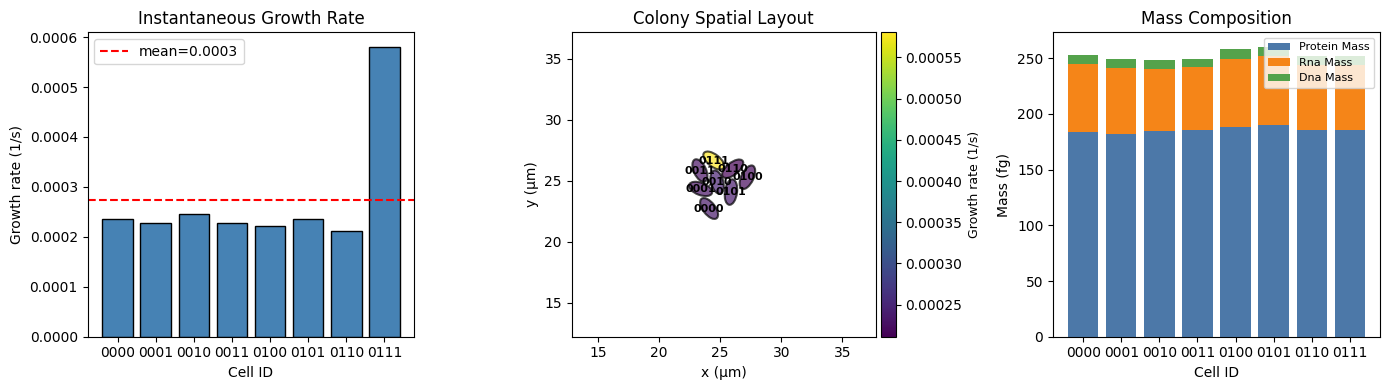


--- Colony Summary ---
Growth rate: 0.00027 ± 0.00012 /s
Cell length: 2.03 ± 0.05 μm
ppGpp conc:  66.651 ± 5.867


In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re

# Load colony snapshot
json_path = '/user/home/il22158/work/vEcoli/data/baseline_3rd_gen_seed_0_seed_0_colony_t3000.json'
with open(json_path, 'r') as f:
    colony_data = json.load(f)

def parse_unit(val):
    """Extract numeric value from unit string like '!units[1.23 micrometer]'"""
    if isinstance(val, str) and val.startswith('!units['):
        match = re.search(r'\[([-\d.eE+]+)', val)
        return float(match.group(1)) if match else np.nan
    return val

# Extract data for all cells
agents = colony_data['agents']
cell_ids = sorted(agents.keys())
print(f"Colony snapshot at t={agents[cell_ids[0]]['global_time']}s | {len(cell_ids)} cells: {cell_ids}")

# Build summary dataframe
cell_data = []
for cid in cell_ids:
    a = agents[cid]
    b = a['boundary']
    m = a['listeners']['mass']
    gl = a['listeners']['growth_limits']
    
    cell_data.append({
        'cell_id': cid,
        'x': parse_unit(b['location'][0]),
        'y': parse_unit(b['location'][1]),
        'angle': b['angle'],
        'length': parse_unit(b['length']),
        'width': parse_unit(b['width']),
        'volume': parse_unit(b['volume']),
        'mass': parse_unit(b['mass']),
        'growth_rate': m['instantaneous_growth_rate'],
        'dry_mass': m['dry_mass'],
        'protein_mass': m['protein_mass'],
        'rna_mass': m['rna_mass'],
        'dna_mass': m['dna_mass'],
        'frac_trna_charged': np.mean(gl['fraction_trna_charged']),
        'ppgpp_conc': gl['ppgpp_conc'],
    })

import pandas as pd
df = pd.DataFrame(cell_data)
print(df[['cell_id', 'growth_rate', 'length', 'mass', 'ppgpp_conc']].to_string(index=False))

# --- Plot 1: Growth rate comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.bar(df['cell_id'], df['growth_rate'], color='steelblue', edgecolor='k')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Growth rate (1/s)')
ax.set_title('Instantaneous Growth Rate')
ax.axhline(df['growth_rate'].mean(), color='red', linestyle='--', label=f"mean={df['growth_rate'].mean():.4f}")
ax.legend()

# --- Plot 2: Spatial colony layout with colorbar ---
ax = axes[1]
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Normalize growth rate for colormap
norm = mcolors.Normalize(vmin=df['growth_rate'].min(), vmax=df['growth_rate'].max())
cmap = plt.cm.viridis

for _, row in df.iterrows():
    from matplotlib.patches import Ellipse
    ellipse = Ellipse((row['x'], row['y']), width=row['length'], height=row['width'],
                      angle=np.degrees(row['angle']), alpha=0.7, edgecolor='k', linewidth=1.5,
                      facecolor=cmap(norm(row['growth_rate'])))
    ax.add_patch(ellipse)
    ax.text(row['x'], row['y'], row['cell_id'], ha='center', va='center', fontsize=8, color='black', fontweight='bold')

# Auto-scale to cell positions with padding
pad = df['length'].max() * 5
ax.set_xlim(df['x'].min() - pad, df['x'].max() + pad)
ax.set_ylim(df['y'].min() - pad, df['y'].max() + pad)
ax.set_aspect('equal')
ax.set_xlabel('x (μm)')
ax.set_ylabel('y (μm)')
ax.set_title('Colony Spatial Layout')

# Add colorbar for growth rate
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Growth rate (1/s)', fontsize=9)

# --- Plot 3: Mass composition ---
ax = axes[2]
mass_components = ['protein_mass', 'rna_mass', 'dna_mass']
x = np.arange(len(cell_ids))
bottom = np.zeros(len(cell_ids))
colors = ['#4c78a8', '#f58518', '#54a24b']
for comp, c in zip(mass_components, colors):
    ax.bar(x, df[comp], bottom=bottom, label=comp.replace('_', ' ').title(), color=c)
    bottom += df[comp].values
ax.set_xticks(x)
ax.set_xticklabels(cell_ids)
ax.set_xlabel('Cell ID')
ax.set_ylabel('Mass (fg)')
ax.set_title('Mass Composition')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# --- Additional: Key colony metrics ---
print(f"\n--- Colony Summary ---")
print(f"Growth rate: {df['growth_rate'].mean():.5f} ± {df['growth_rate'].std():.5f} /s")
print(f"Cell length: {df['length'].mean():.2f} ± {df['length'].std():.2f} μm")
print(f"ppGpp conc:  {df['ppgpp_conc'].mean():.3f} ± {df['ppgpp_conc'].std():.3f}")

**Spatial Graph Construction:**
Each cell is drawn as an **ellipse** using `matplotlib.patches.Ellipse` with:
- **Position**: `(x, y)` from `boundary['location']` (cell centroid in μm)
- **Size**: `width=length`, `height=width` (cell dimensions in μm)
- **Orientation**: `angle` from `boundary['angle']` (converted to degrees)
- **Color**: mapped to growth rate via `viridis` colormap (brighter = faster growth)

The plot auto-scales to the cell bounding box + 5× max cell length as padding.

## Env Factors - 3rd gen

### Load data

In [1]:
import json

with open('/user/home/il22158/work/vEcoli/data/baseline_3rd_gen_seed_0_seed_0_colony_t3000.json', 'r') as f:
    data = json.load(f)

agents = data['agents']
agent_ids = sorted(agents.keys())

# Get all unique keys (categories) across all agents
all_keys = set()
for agent in agents.values():
    all_keys.update(agent.keys())

print("Agent names (IDs):")
print(agent_ids)
print("\nUnique categories (keys):")
print(sorted(all_keys))

Agent names (IDs):
['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111']

Unique categories (keys):
['allocate', 'allocator_rng', 'boundary', 'bulk', 'bulk_dtypes', 'cytoplasm', 'divide', 'division_threshold', 'division_trigger', 'environment', 'global_time', 'listeners', 'next_update_time', 'periplasm', 'process_state', 'request', 'timeline', 'timestep', 'unique', 'unique_dtypes']


In [2]:
# Show dtype and preview for each category for the first agent
sample_agent = agents[agent_ids[0]]
print(f"\n--- Data preview for agent '{agent_ids[0]}' ---")
for key in sorted(all_keys):
    value = sample_agent.get(key, None)
    print(f"\nCategory: '{key}'")
    print(f"Type: {type(value)}")
    if isinstance(value, dict):
        subkeys = sorted(value.keys())
        print(f"Exclusive subcategories: {subkeys}")
    elif isinstance(value, list):
        print(f"Length: {len(value)}")
        print(f"First 3 entries: {value[:3]}")
    else:
        print(f"Value: {value}")


--- Data preview for agent '0000' ---

Category: 'allocate'
Type: <class 'dict'>
Exclusive subcategories: ['ecoli-chromosome-replication', 'ecoli-complexation', 'ecoli-equilibrium', 'ecoli-polypeptide-elongation', 'ecoli-polypeptide-initiation', 'ecoli-protein-degradation', 'ecoli-rna-degradation', 'ecoli-rna-maturation', 'ecoli-transcript-elongation', 'ecoli-transcript-initiation', 'ecoli-two-component-system']

Category: 'allocator_rng'
Type: <class 'str'>
Value: !RandomStateSerializer[('MT19937', [1032081874, 3921390043, 1775671866, 3050400842, 613040236, 3120117409, 313685, 4009028496, 3451362311, 1611313565, 1216908950, 1280315550, 2094310855, 486956331, 2341192965, 835091154, 3469137642, 701790974, 3147330632, 4284971845, 196483250, 3605856335, 2998782482, 1551059047, 772023894, 3028362759, 2054139155, 1697376821, 3256171168, 1295408492, 409809183, 2117531738, 1695919879, 3445769087, 3326475278, 232416836, 3552623864, 3205095980, 1077074508, 4278080904, 2968265471, 3704500986, 3

In ''bulk'', ''submass'' refers to the contribution of a chemical to a specific cellular mass compartment. The bulk_dtypes field lists submass types such as rRNA_submass, tRNA_submass, mRNA_submass, miscRNA_submass, nonspecific_RNA_submass, protein_submass, metabolite_submass, water_submass, DNA_submass.

For each chemical, only one submass field is typically non-zero, corresponding to the compartment that chemical belongs to. For example:

If the chemical is a protein, only protein_submass will be non-zero.
If it’s a metabolite, only metabolite_submass will be non-zero.
If it’s an rRNA, only rRNA_submass will be non-zero.

In [3]:
# Preview exclusive lists for both 'exchange' and 'media_id' subcategories across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_ids.add(env.get('media_id', None))

print("Exclusive list of all exchange chemicals across agents:")
print(sorted(exchange_keys))
print("\nExclusive list of all media_id values across agents:")
print(sorted(media_ids))


Exclusive list of all exchange chemicals across agents:
['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE', 'ARG', 'ASN', 'BETAINE', 'BUTANAL', 'CA+2', 'CARBON-DIOXIDE', 'CARBON-MONOXIDE', 'CH33ADO', 'CL-', 'CO+2', 'CPD-10774', 'CPD-108', 'CPD-1772', 'CPD-183', 'CPD-239', 'CPD-520', 'CPD-534', 'CPD-560', 'CPD-564', 'CPD0-1958', 'CYS', 'CYTIDINE', 'CYTOSINE', 'D-ALANINE', 'D-LACTATE', 'ETOH', 'FE+2', 'FE+3', 'FORMATE', 'FUM', 'GLC', 'GLC-D-LACTONE', 'GLN', 'GLT', 'GLY', 'GLYCEROL', 'GLYCOLALDEHYDE', 'GLYCOLLATE', 'HIS', 'HYDROGEN-MOLECULE', 'HYPOXANTHINE', 'ILE', 'IMIDAZOLE-PYRUVATE', 'INDOLE', 'K+', 'L-ALPHA-ALANINE', 'L-ASPARTATE', 'L-SELENOCYSTEINE', 'LEU', 'LYS', 'MAL', 'MET', 'METOH', 'MG+2', 'MI-PENTAKISPHOSPHATE', 'MN+2', 'NA+', 'NI+2', 'NITRATE', 'NITRITE', 'OXYGEN-MOLECULE', 'PHE', 'PRO', 'PROTON', 'Pi', 'S-ADENOSYL-4-METHYLTHIO-2-OXOBUTANOATE', 'S-ADENOSYLMETHIONINE', 'SER', 'SUC', 'SULFATE', 'THR', 'THYMINE', 'TRP', 'TUNGSTATE', 'TYR', 'UNDECAPRENYL-DIPHOSPH

**Preview of 'environment' subcategories for the first agent**

- **exchange**: Dictionary of chemicals exchanged between cell and environment.
    - Keys ex: ['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE']
    - Each key represents a chemical compound relevant to E. coli's metabolism in minimal media.
    - Example values: Show first few exchange rates if available.

- **media_id**: String indicating the media type.
    - Value ex: 'minimal'
    - This specifies the simulation is run in minimal medium, restricting available nutrients.

**Brief explanations of the first 5 exchange chemicals:**

- **4FE-4S**: Iron-sulfur cluster, essential for enzyme function and electron transfer.
- **5-Deoxy-D-Ribofuranose**: Rare sugar, involved in nucleotide metabolism.
- **ACET**: Acetate, carbon source and metabolic byproduct.
- **AMMONIUM**: Ammonium ion, primary nitrogen source.
- **ARABINOSE**: Arabinose, pentose sugar, alternative carbon source.


In [4]:
# Confirm that all agents have exactly 5 environment exchanges
exchange_counts = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_counts.append(len(exchange))

unique_counts = set(exchange_counts)
print(f"Unique exchange counts across all agents: {unique_counts}")
if unique_counts == {5}:
    print("All agents have exactly 5 environment exchanges.")
else:
    print(f"Some agents have different numbers of exchanges: {unique_counts}")
# Optionally, print agent IDs with non-5 exchanges
for agent_id, count in zip(agent_ids, exchange_counts):
    if count != 5:
        print(f"Agent {agent_id} has {count} exchanges.")


Unique exchange counts across all agents: {87}
Some agents have different numbers of exchanges: {87}
Agent 0000 has 87 exchanges.
Agent 0001 has 87 exchanges.
Agent 0010 has 87 exchanges.
Agent 0011 has 87 exchanges.
Agent 0100 has 87 exchanges.
Agent 0101 has 87 exchanges.
Agent 0110 has 87 exchanges.
Agent 0111 has 87 exchanges.


In [5]:
import os
import pandas as pd

# Collect exclusive lists for exchange chemicals and media_ids across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_id = env.get('media_id', None)
    if media_id is not None:
        media_ids.add(media_id)

# Prepare DataFrame
results_df = pd.DataFrame({
    'exchange_chemical': sorted(exchange_keys),
})

# Save unique media_ids separately
media_ids_path = '/user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv'
pd.DataFrame({'media_id': sorted(media_ids)}).to_csv(media_ids_path, index=False)

# Ensure output directory exists
output_dir = '/user/home/il22158/work/vEcoli/reading/results/colony'
os.makedirs(output_dir, exist_ok=True)

# Save unique exchange chemicals
output_path = os.path.join(output_dir, 'unique_exchanges.csv')
results_df.to_csv(output_path, index=False)
print(f"Saved unique exchange chemicals to: {output_path}")
print(f"Saved unique media_ids to: {media_ids_path}")

Saved unique exchange chemicals to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_exchanges.csv
Saved unique media_ids to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv


### Heatmap

/tmp/ipykernel_1581789/95777993.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


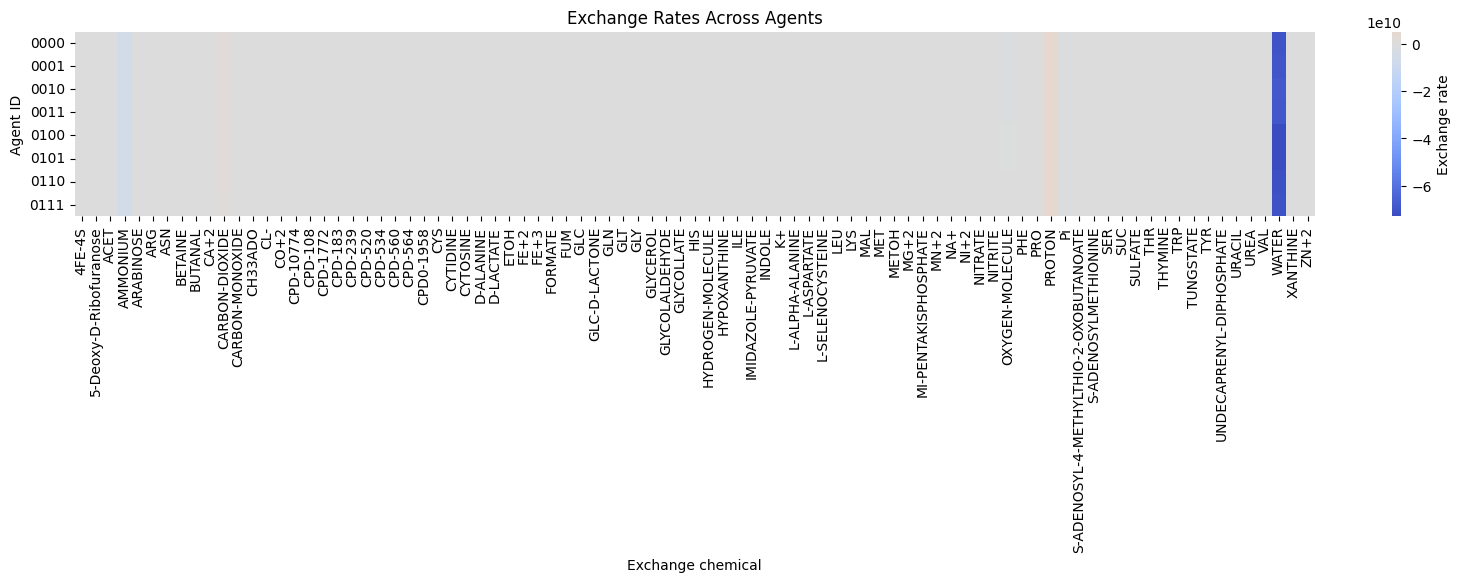

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Plot heatmap
plt.figure(figsize=(min(20, 0.5*len(exchange_df.columns)), min(12, 0.3*len(exchange_df))))
sns.heatmap(exchange_df, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Exchange rate'})
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1581789/3420995705.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


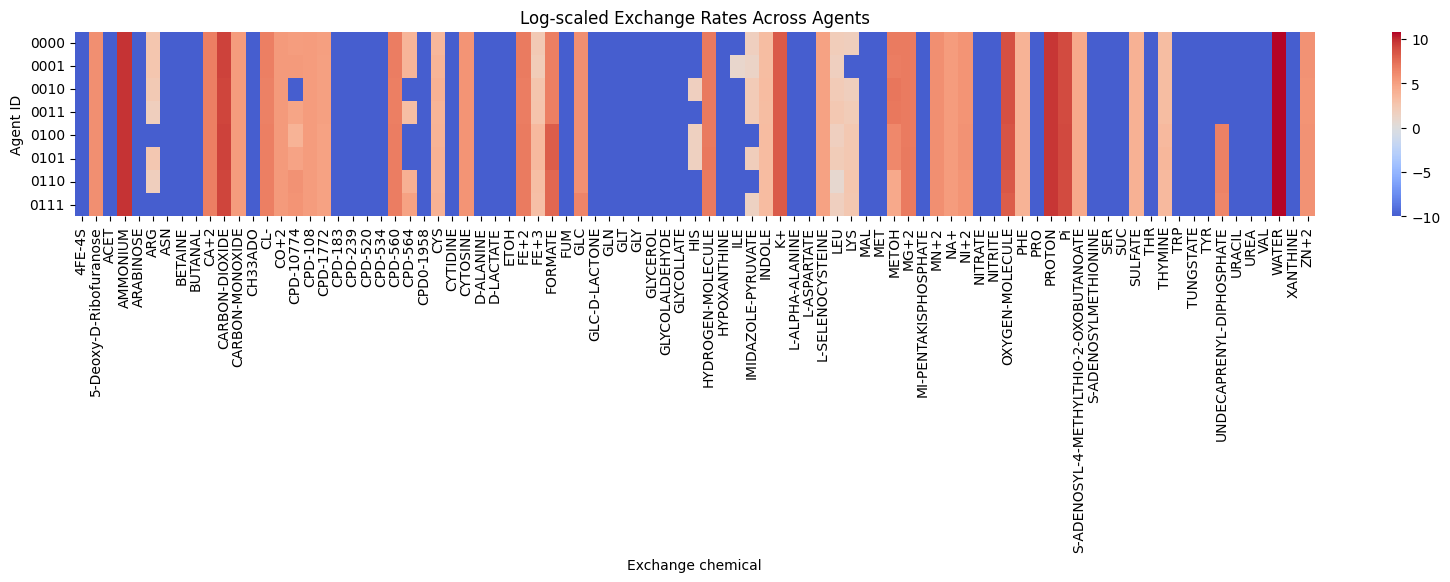

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_exchange_df = np.log10(np.abs(exchange_df) + e1)

# Plot heatmap
plt.figure(figsize=(min(20, 0.5*len(log_exchange_df.columns)), min(12, 0.3*len(log_exchange_df))))
sns.heatmap(log_exchange_df, cmap='coolwarm', center=0, annot=False)
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Log-scaled Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1581789/3316751008.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


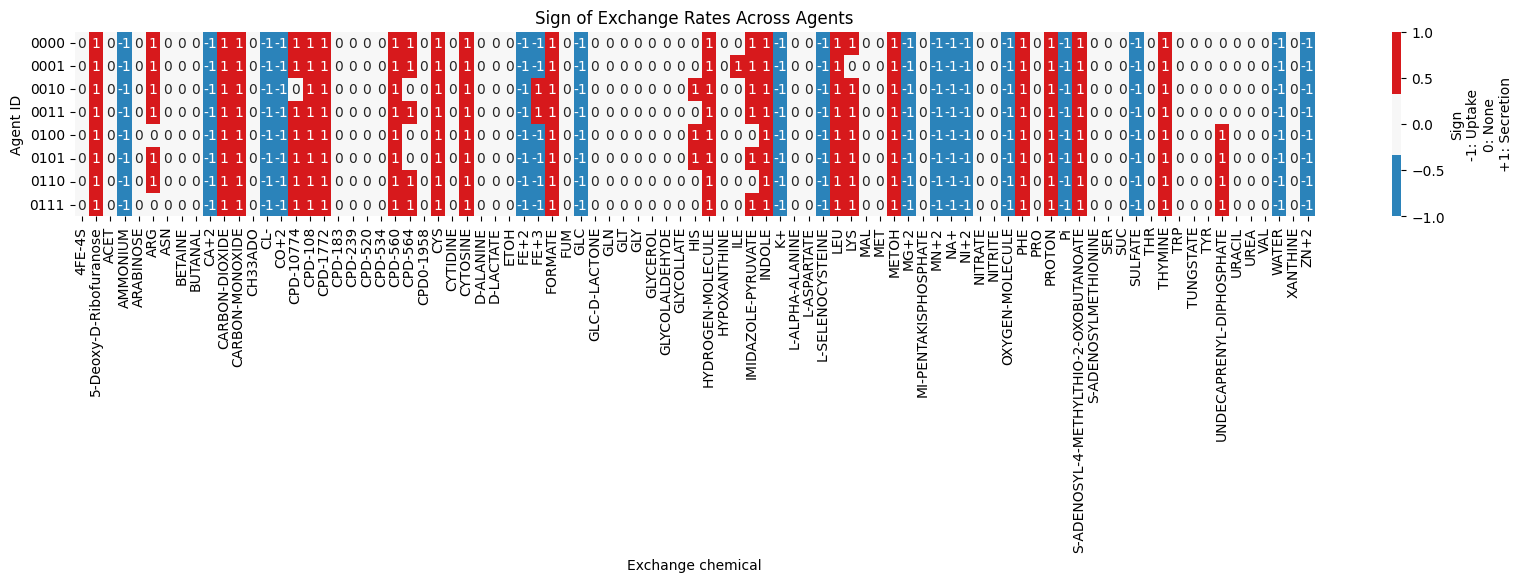

In [8]:
# Plot sign of exchange readings for each agent and chemical
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assumes exchange_df is defined: rows=agent_id, columns=chemicals
# If not, recreate exchange_df from your data as in previous cells

# Compute sign matrix: -1 (uptake), 0 (none), +1 (secretion)
sign_df = np.sign(exchange_df)

plt.figure(figsize=(min(20, 0.5*len(sign_df.columns)), min(12, 0.3*len(sign_df))))
sns.heatmap(sign_df, cmap=sns.color_palette(["#2b83ba", "#f7f7f7", "#d7191c"], as_cmap=True), center=0, annot=True, fmt="d",
            cbar_kws={'label': 'Sign\n-1: Uptake\n0: None\n+1: Secretion'})
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Sign of Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

In [9]:
# Show first 5 zero exchange readings (agent, chemical, value)
import pandas as pd

# Find zero entries in exchange_df
zero_entries = []
for agent in exchange_df.index:
    for chem in exchange_df.columns:
        if exchange_df.loc[agent, chem] == 0:
            zero_entries.append((agent, chem, 0))
            if len(zero_entries) == 5:
                break
    if len(zero_entries) == 5:
        break

# Display
print("First 5 zero exchange readings:")
for entry in zero_entries:
    print(f"Agent: {entry[0]}, Chemical: {entry[1]}, Value: {entry[2]}")

First 5 zero exchange readings:
Agent: 0000, Chemical: 4FE-4S, Value: 0
Agent: 0000, Chemical: ACET, Value: 0
Agent: 0000, Chemical: ARABINOSE, Value: 0
Agent: 0000, Chemical: ASN, Value: 0
Agent: 0000, Chemical: BETAINE, Value: 0


/tmp/ipykernel_1581789/1856500740.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


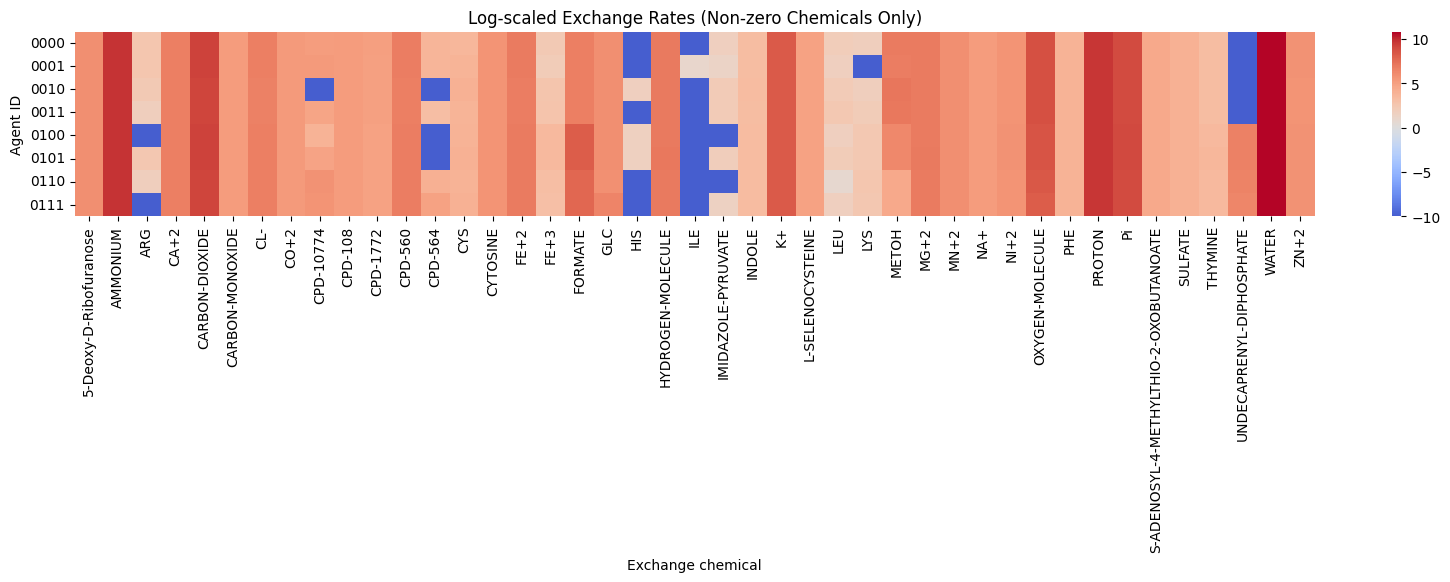

In [10]:
# Plot log-scaled heatmap for chemicals with at least one non-zero value
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter columns (chemicals) with at least one non-zero value
nonzero_chems = exchange_df.columns[(exchange_df != 0).any(axis=0)]
filtered_df = exchange_df[nonzero_chems]

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_filtered_df = np.log10(np.abs(filtered_df) + e1)

plt.figure(figsize=(min(20, 0.5*len(log_filtered_df.columns)), min(12, 0.3*len(log_filtered_df))))
sns.heatmap(log_filtered_df, cmap='coolwarm', center=0, annot=False)
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Log-scaled Exchange Rates (Non-zero Chemicals Only)')
plt.tight_layout()
plt.show()

## Spatial Layout - 4th gen

Colony snapshot at t=12000.0s | 16 cells: ['00000', '00001', '00010', '00011', '00100', '00101', '00110', '00111', '01000', '01001', '01010', '01011', '01100', '01101', '01110', '01111']
cell_id  agent_id_dec  growth_rate   length        mass  ppgpp_conc
  00000             0     0.000228 2.031997 1467.540358   73.297376
  00001             1     0.000230 2.029830 1465.667841   69.656818
  00010             2     0.000226 1.997237 1437.509491   57.996115
  00011             3     0.000283 2.055288 1487.662338   40.039530
  00100             4     0.000235 2.043992 1477.902829   55.581951
  00101             5     0.000207 2.011338 1449.691756   64.628662
  00110             6     0.000309 2.106940 1532.286394   41.802040
  00111             7     0.000231 2.023623 1460.305341   72.913985
  01000             8     0.000184 1.952747 1399.073009   89.905085
  01001             9     0.000239 2.035938 1470.945130   65.870975
  01010            10     0.000229 2.119125 1542.813018   73.2221

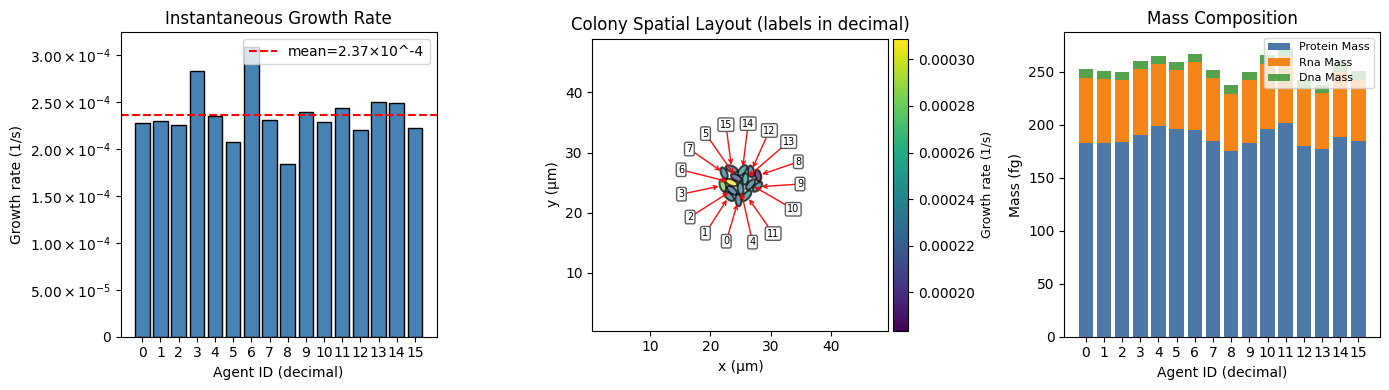


--- Colony Summary ---
Growth rate: 2.37×10^-4 ± 2.86×10^-5 /s
Cell length: 2.04 ± 0.06 μm
ppGpp conc:  64.621 ± 12.333

--- Agent ID conversion table ---


,decimal_id,binary_id
0,0,00000
1,1,00001
2,2,00010
3,3,00011
4,4,00100
5,5,00101
6,6,00110
7,7,00111
8,8,01000
9,9,01001


In [44]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.ticker import FuncFormatter

# Load colony snapshot
json_path = '/user/home/il22158/work/vEcoli/data/baseline_4th_gen_seed_0_colony_t3000.json'
with open(json_path, 'r') as f:
    colony_data = json.load(f)

def parse_unit(val):
    """Extract numeric value from unit string like '!units[1.23 micrometer]'"""
    if isinstance(val, str) and val.startswith('!units['):
        match = re.search(r'\[([-\d.eE+]+)', val)
        return float(match.group(1)) if match else np.nan
    return val

def sci_parts(value):
    if value == 0 or np.isclose(value, 0):
        return 0.0, 0
    exponent = int(np.floor(np.log10(abs(value))))
    mantissa = value / (10 ** exponent)
    return mantissa, exponent

def format_sci_mathtext(value, decimals=2):
    mantissa, exponent = sci_parts(value)
    if exponent == 0 and np.isclose(mantissa, 0):
        return "0"
    return rf"${mantissa:.{decimals}f}\times10^{{{exponent}}}$"

def format_sci_plain(value, decimals=2):
    mantissa, exponent = sci_parts(value)
    if exponent == 0 and np.isclose(mantissa, 0):
        return "0"
    return f"{mantissa:.{decimals}f}×10^{exponent}"

# Extract data for all cells
agents = colony_data['agents']
cell_ids = sorted(agents.keys())
print(f"Colony snapshot at t={agents[cell_ids[0]]['global_time']}s | {len(cell_ids)} cells: {cell_ids}")

# Build summary dataframe
cell_data = []
for cid in cell_ids:
    a = agents[cid]
    b = a['boundary']
    m = a['listeners']['mass']
    gl = a['listeners']['growth_limits']
    
    cell_data.append({
        'cell_id': cid,
        'x': parse_unit(b['location'][0]),
        'y': parse_unit(b['location'][1]),
        'angle': b['angle'],
        'length': parse_unit(b['length']),
        'width': parse_unit(b['width']),
        'volume': parse_unit(b['volume']),
        'mass': parse_unit(b['mass']),
        'growth_rate': m['instantaneous_growth_rate'],
        'dry_mass': m['dry_mass'],
        'protein_mass': m['protein_mass'],
        'rna_mass': m['rna_mass'],
        'dna_mass': m['dna_mass'],
        'frac_trna_charged': np.mean(gl['fraction_trna_charged']),
        'ppgpp_conc': gl['ppgpp_conc'],
    })

import pandas as pd
df = pd.DataFrame(cell_data)
df['agent_id_dec'] = df['cell_id'].apply(lambda s: int(str(s), 2))
print(df[['cell_id', 'agent_id_dec', 'growth_rate', 'length', 'mass', 'ppgpp_conc']].to_string(index=False))

# --- Plot 1: Growth rate comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
x = np.arange(len(df))
mean_growth = df['growth_rate'].mean()
ax.bar(x, df['growth_rate'], color='steelblue', edgecolor='k')
ax.set_xticks(x)
ax.set_xticklabels(df['agent_id_dec'], rotation=0)
ax.set_xlabel('Agent ID (decimal)')
ax.set_ylabel('Growth rate (1/s)')
ax.set_title('Instantaneous Growth Rate')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: format_sci_mathtext(v, decimals=2)))
ax.axhline(mean_growth, color='red', linestyle='--', label=f"mean={format_sci_plain(mean_growth, decimals=2)}")
ax.legend()

# --- Plot 2: Spatial colony layout with colorbar ---
ax = axes[1]
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Normalize growth rate for colormap
norm = mcolors.Normalize(vmin=df['growth_rate'].min(), vmax=df['growth_rate'].max())
cmap = plt.cm.viridis

# Colony center for outward label placement
cx, cy = df['x'].mean(), df['y'].mean()
base_offset = max(df['length'].max(), df['width'].max()) * 1.8

anchors = []
label_positions = []
preferred_dirs = []
clearance_radii = []

for i, row in df.iterrows():
    from matplotlib.patches import Ellipse
    ellipse = Ellipse((row['x'], row['y']), width=row['length'], height=row['width'],
                      angle=np.degrees(row['angle']), alpha=0.7, edgecolor='k', linewidth=1.5,
                      facecolor=cmap(norm(row['growth_rate'])))
    ax.add_patch(ellipse)

    anchors.append((row['x'], row['y'], str(row['agent_id_dec'])))

    # Initial label position: outward + slight tangential spread
    dx, dy = row['x'] - cx, row['y'] - cy
    theta = np.arctan2(dy, dx) if (dx != 0 or dy != 0) else (2 * np.pi * i / max(1, len(df)))
    ux, uy = np.cos(theta), np.sin(theta)
    preferred_dirs.append((ux, uy))

    px, py = -uy, ux
    radial = base_offset * (1 + 0.22 * (i % 3))
    tangential = base_offset * 0.35 * ((i % 5) - 2) / 2.0
    tx = row['x'] + radial * ux + tangential * px
    ty = row['y'] + radial * uy + tangential * py
    label_positions.append([tx, ty])

    # No-label zone radius for each ellipse
    cell_half_extent = 0.5 * max(row['length'], row['width'])
    label_margin = base_offset * 0.65
    clearance_radii.append(cell_half_extent + label_margin)

# Keep all labels outside the whole colony core
colony_core_radius = 0.0
for k, (cxk, cyk, _) in enumerate(anchors):
    colony_core_radius = max(colony_core_radius, np.hypot(cxk - cx, cyk - cy) + clearance_radii[k])
global_label_min_radius = colony_core_radius + base_offset * 0.8

# Repel labels from each other and from all cell no-label zones
min_dist = base_offset * 0.95
max_radius = base_offset * 6.0
for _ in range(240):
    # Pairwise label-label repulsion
    for i in range(len(label_positions)):
        for j in range(i + 1, len(label_positions)):
            dx = label_positions[j][0] - label_positions[i][0]
            dy = label_positions[j][1] - label_positions[i][1]
            dist = np.hypot(dx, dy)
            if dist < min_dist:
                if dist < 1e-9:
                    angle = 2 * np.pi * ((i + j + 1) % 16) / 16.0
                    ux, uy = np.cos(angle), np.sin(angle)
                else:
                    ux, uy = dx / dist, dy / dist
                shift = (min_dist - dist) * 0.5
                label_positions[i][0] -= ux * shift
                label_positions[i][1] -= uy * shift
                label_positions[j][0] += ux * shift
                label_positions[j][1] += uy * shift

    for i in range(len(label_positions)):
        tx, ty = label_positions[i]

        # Keep labels outside all cell no-label zones
        for k in range(len(anchors)):
            cxk, cyk, _ = anchors[k]
            dx = tx - cxk
            dy = ty - cyk
            dist = np.hypot(dx, dy)
            min_clear = clearance_radii[k]
            if dist < min_clear:
                if dist < 1e-9:
                    ux, uy = preferred_dirs[i]
                else:
                    ux, uy = dx / dist, dy / dist
                tx = cxk + ux * min_clear
                ty = cyk + uy * min_clear

        # Keep labels outside the full colony core ring
        dxc = tx - cx
        dyc = ty - cy
        rc = np.hypot(dxc, dyc)
        if rc < global_label_min_radius:
            if rc < 1e-9:
                ux, uy = preferred_dirs[i]
            else:
                ux, uy = dxc / rc, dyc / rc
            tx = cx + ux * global_label_min_radius
            ty = cy + uy * global_label_min_radius

        # Keep labels reasonably near their own anchor
        ax0, ay0, _ = anchors[i]
        vx = tx - ax0
        vy = ty - ay0
        radius = np.hypot(vx, vy)
        if radius > max_radius and radius > 0:
            scale = max_radius / radius
            tx = ax0 + vx * scale
            ty = ay0 + vy * scale

        # Final local guarantee: not inside own-cell clearance
        own_min = clearance_radii[i]
        dx0 = tx - ax0
        dy0 = ty - ay0
        dist0 = np.hypot(dx0, dy0)
        if dist0 < own_min:
            if dist0 < 1e-9:
                ux0, uy0 = preferred_dirs[i]
            else:
                ux0, uy0 = dx0 / dist0, dy0 / dist0
            tx = ax0 + ux0 * own_min
            ty = ay0 + uy0 * own_min

        label_positions[i][0] = tx
        label_positions[i][1] = ty

# Draw arrowed labels (red arrows for clear distinction)
for i, (ax0, ay0, text) in enumerate(anchors):
    tx, ty = label_positions[i]
    ax.annotate(
        text,
        xy=(ax0, ay0),
        xytext=(tx, ty),
        textcoords='data',
        ha='center',
        va='center',
        fontsize=7,
        color='black',
        bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='0.3', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.0, shrinkA=0, shrinkB=3, alpha=0.95)
    )

# Auto-scale to cell positions with padding (expanded to include external labels)
pad = df['length'].max() * 10
ax.set_xlim(df['x'].min() - pad, df['x'].max() + pad)
ax.set_ylim(df['y'].min() - pad, df['y'].max() + pad)
ax.set_aspect('equal')
ax.set_xlabel('x (μm)')
ax.set_ylabel('y (μm)')
ax.set_title('Colony Spatial Layout (labels in decimal)')

# Add colorbar for growth rate
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Growth rate (1/s)', fontsize=9)

# --- Plot 3: Mass composition ---
ax = axes[2]
mass_components = ['protein_mass', 'rna_mass', 'dna_mass']
x = np.arange(len(df))
bottom = np.zeros(len(df))
colors = ['#4c78a8', '#f58518', '#54a24b']
for comp, c in zip(mass_components, colors):
    ax.bar(x, df[comp], bottom=bottom, label=comp.replace('_', ' ').title(), color=c)
    bottom += df[comp].values
ax.set_xticks(x)
ax.set_xticklabels(df['agent_id_dec'], rotation=0)
ax.set_xlabel('Agent ID (decimal)')
ax.set_ylabel('Mass (fg)')
ax.set_title('Mass Composition')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('/user/home/il22158/work/vEcoli/reading/results/colony/4th gen/colony_spatial_layout_growth_summary.png')
plt.show()

# --- Additional: Key colony metrics ---
print(f"\n--- Colony Summary ---")
print(f"Growth rate: {format_sci_plain(df['growth_rate'].mean(), decimals=2)} ± {format_sci_plain(df['growth_rate'].std(), decimals=2)} /s")
print(f"Cell length: {df['length'].mean():.2f} ± {df['length'].std():.2f} μm")
print(f"ppGpp conc:  {df['ppgpp_conc'].mean():.3f} ± {df['ppgpp_conc'].std():.3f}")

# --- Binary-to-decimal conversion table ---
id_conversion = df[['agent_id_dec', 'cell_id']].drop_duplicates().sort_values('agent_id_dec').reset_index(drop=True)
print("\n--- Agent ID conversion table ---")
display(id_conversion.rename(columns={'agent_id_dec': 'decimal_id', 'cell_id': 'binary_id'}))

**Spatial Graph Construction:**
Each cell is drawn as an **ellipse** using `matplotlib.patches.Ellipse` with:
- **Position**: `(x, y)` from `boundary['location']` (cell centroid in μm)
- **Size**: `width=length`, `height=width` (cell dimensions in μm)
- **Orientation**: `angle` from `boundary['angle']` (converted to degrees)
- **Color**: mapped to growth rate via `viridis` colormap (brighter = faster growth)

The plot auto-scales to the cell bounding box + 5× max cell length as padding.

## Env Factors - 4th gen

### Load data

In [9]:
import json

with open('/user/home/il22158/work/vEcoli/data/baseline_4th_gen_seed_0_colony_t3000.json', 'r') as f:
    data = json.load(f)

agents = data['agents']
agent_ids = sorted(agents.keys())

# Get all unique keys (categories) across all agents
all_keys = set()
for agent in agents.values():
    all_keys.update(agent.keys())

print("Agent names (IDs):")
print(agent_ids)
print("\nUnique categories (keys):")
print(sorted(all_keys))

Agent names (IDs):
['00000', '00001', '00010', '00011', '00100', '00101', '00110', '00111', '01000', '01001', '01010', '01011', '01100', '01101', '01110', '01111']

Unique categories (keys):
['allocate', 'allocator_rng', 'boundary', 'bulk', 'bulk_dtypes', 'cytoplasm', 'divide', 'division_threshold', 'division_trigger', 'environment', 'global_time', 'listeners', 'next_update_time', 'periplasm', 'process_state', 'request', 'timeline', 'timestep', 'unique', 'unique_dtypes']


In [28]:
# Show dtype and preview for each category for the first agent
sample_agent = agents[agent_ids[0]]
print(f"\n--- Data preview for agent '{agent_ids[0]}' ---")
for key in sorted(all_keys):
    value = sample_agent.get(key, None)
    print(f"\nCategory: '{key}'")
    print(f"Type: {type(value)}")
    if isinstance(value, dict):
        subkeys = sorted(value.keys())
        print(f"Exclusive subcategories: {subkeys}")
    elif isinstance(value, list):
        print(f"Length: {len(value)}")
        print(f"First 3 entries: {value[:3]}")
    else:
        print(f"Value: {value}")


--- Data preview for agent '00000' ---

Category: 'allocate'
Type: <class 'dict'>
Exclusive subcategories: ['ecoli-chromosome-replication', 'ecoli-complexation', 'ecoli-equilibrium', 'ecoli-polypeptide-elongation', 'ecoli-polypeptide-initiation', 'ecoli-protein-degradation', 'ecoli-rna-degradation', 'ecoli-rna-maturation', 'ecoli-transcript-elongation', 'ecoli-transcript-initiation', 'ecoli-two-component-system']

Category: 'allocator_rng'
Type: <class 'str'>
Value: !RandomStateSerializer[('MT19937', [1032081874, 3921390043, 1775671866, 3050400842, 613040236, 3120117409, 313685, 4009028496, 3451362311, 1611313565, 1216908950, 1280315550, 2094310855, 486956331, 2341192965, 835091154, 3469137642, 701790974, 3147330632, 4284971845, 196483250, 3605856335, 2998782482, 1551059047, 772023894, 3028362759, 2054139155, 1697376821, 3256171168, 1295408492, 409809183, 2117531738, 1695919879, 3445769087, 3326475278, 232416836, 3552623864, 3205095980, 1077074508, 4278080904, 2968265471, 3704500986, 

In ''bulk'', ''submass'' refers to the contribution of a chemical to a specific cellular mass compartment. The bulk_dtypes field lists submass types such as rRNA_submass, tRNA_submass, mRNA_submass, miscRNA_submass, nonspecific_RNA_submass, protein_submass, metabolite_submass, water_submass, DNA_submass.

For each chemical, only one submass field is typically non-zero, corresponding to the compartment that chemical belongs to. For example:

If the chemical is a protein, only protein_submass will be non-zero.
If it’s a metabolite, only metabolite_submass will be non-zero.
If it’s an rRNA, only rRNA_submass will be non-zero.

In [11]:
# Preview exclusive lists for both 'exchange' and 'media_id' subcategories across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_ids.add(env.get('media_id', None))

print("Exclusive list of all exchange chemicals across agents:")
print(sorted(exchange_keys))
print("\nExclusive list of all media_id values across agents:")
print(sorted(media_ids))


Exclusive list of all exchange chemicals across agents:
['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE', 'ARG', 'ASN', 'BETAINE', 'BUTANAL', 'CA+2', 'CARBON-DIOXIDE', 'CARBON-MONOXIDE', 'CH33ADO', 'CL-', 'CO+2', 'CPD-10774', 'CPD-108', 'CPD-1772', 'CPD-183', 'CPD-239', 'CPD-520', 'CPD-534', 'CPD-560', 'CPD-564', 'CPD0-1958', 'CYS', 'CYTIDINE', 'CYTOSINE', 'D-ALANINE', 'D-LACTATE', 'ETOH', 'FE+2', 'FE+3', 'FORMATE', 'FUM', 'GLC', 'GLC-D-LACTONE', 'GLN', 'GLT', 'GLY', 'GLYCEROL', 'GLYCOLALDEHYDE', 'GLYCOLLATE', 'HIS', 'HYDROGEN-MOLECULE', 'HYPOXANTHINE', 'ILE', 'IMIDAZOLE-PYRUVATE', 'INDOLE', 'K+', 'L-ALPHA-ALANINE', 'L-ASPARTATE', 'L-SELENOCYSTEINE', 'LEU', 'LYS', 'MAL', 'MET', 'METOH', 'MG+2', 'MI-PENTAKISPHOSPHATE', 'MN+2', 'NA+', 'NI+2', 'NITRATE', 'NITRITE', 'OXYGEN-MOLECULE', 'PHE', 'PRO', 'PROTON', 'Pi', 'S-ADENOSYL-4-METHYLTHIO-2-OXOBUTANOATE', 'S-ADENOSYLMETHIONINE', 'SER', 'SUC', 'SULFATE', 'THR', 'THYMINE', 'TRP', 'TUNGSTATE', 'TYR', 'UNDECAPRENYL-DIPHOSPH

**Preview of 'environment' subcategories for the first agent**

- **exchange**: Dictionary of chemicals exchanged between cell and environment.
    - Keys ex: ['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE']
    - Each key represents a chemical compound relevant to E. coli's metabolism in minimal media.
    - Example values: Show first few exchange rates if available.

- **media_id**: String indicating the media type.
    - Value ex: 'minimal'
    - This specifies the simulation is run in minimal medium, restricting available nutrients.

**Brief explanations of the first 5 exchange chemicals:**

- **4FE-4S**: Iron-sulfur cluster, essential for enzyme function and electron transfer.
- **5-Deoxy-D-Ribofuranose**: Rare sugar, involved in nucleotide metabolism.
- **ACET**: Acetate, carbon source and metabolic byproduct.
- **AMMONIUM**: Ammonium ion, primary nitrogen source.
- **ARABINOSE**: Arabinose, pentose sugar, alternative carbon source.


In [12]:
# Confirm that all agents have exactly 5 environment exchanges
exchange_counts = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_counts.append(len(exchange))

unique_counts = set(exchange_counts)
print(f"Unique exchange counts across all agents: {unique_counts}")
if unique_counts == {5}:
    print("All agents have exactly 5 environment exchanges.")
else:
    print(f"Some agents have different numbers of exchanges: {unique_counts}")
# Optionally, print agent IDs with non-5 exchanges
for agent_id, count in zip(agent_ids, exchange_counts):
    if count != 5:
        print(f"Agent {agent_id} has {count} exchanges.")


Unique exchange counts across all agents: {87}
Some agents have different numbers of exchanges: {87}
Agent 00000 has 87 exchanges.
Agent 00001 has 87 exchanges.
Agent 00010 has 87 exchanges.
Agent 00011 has 87 exchanges.
Agent 00100 has 87 exchanges.
Agent 00101 has 87 exchanges.
Agent 00110 has 87 exchanges.
Agent 00111 has 87 exchanges.
Agent 01000 has 87 exchanges.
Agent 01001 has 87 exchanges.
Agent 01010 has 87 exchanges.
Agent 01011 has 87 exchanges.
Agent 01100 has 87 exchanges.
Agent 01101 has 87 exchanges.
Agent 01110 has 87 exchanges.
Agent 01111 has 87 exchanges.


In [13]:
import os
import pandas as pd

# Collect exclusive lists for exchange chemicals and media_ids across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_id = env.get('media_id', None)
    if media_id is not None:
        media_ids.add(media_id)

# Prepare DataFrame
results_df = pd.DataFrame({
    'exchange_chemical': sorted(exchange_keys),
})

# Save unique media_ids separately
media_ids_path = '/user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv'
pd.DataFrame({'media_id': sorted(media_ids)}).to_csv(media_ids_path, index=False)

# Ensure output directory exists
output_dir = '/user/home/il22158/work/vEcoli/reading/results/colony'
os.makedirs(output_dir, exist_ok=True)

# Save unique exchange chemicals
output_path = os.path.join(output_dir, 'unique_exchanges.csv')
results_df.to_csv(output_path, index=False)
print(f"Saved unique exchange chemicals to: {output_path}")
print(f"Saved unique media_ids to: {media_ids_path}")

Saved unique exchange chemicals to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_exchanges.csv
Saved unique media_ids to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv


### Heatmap

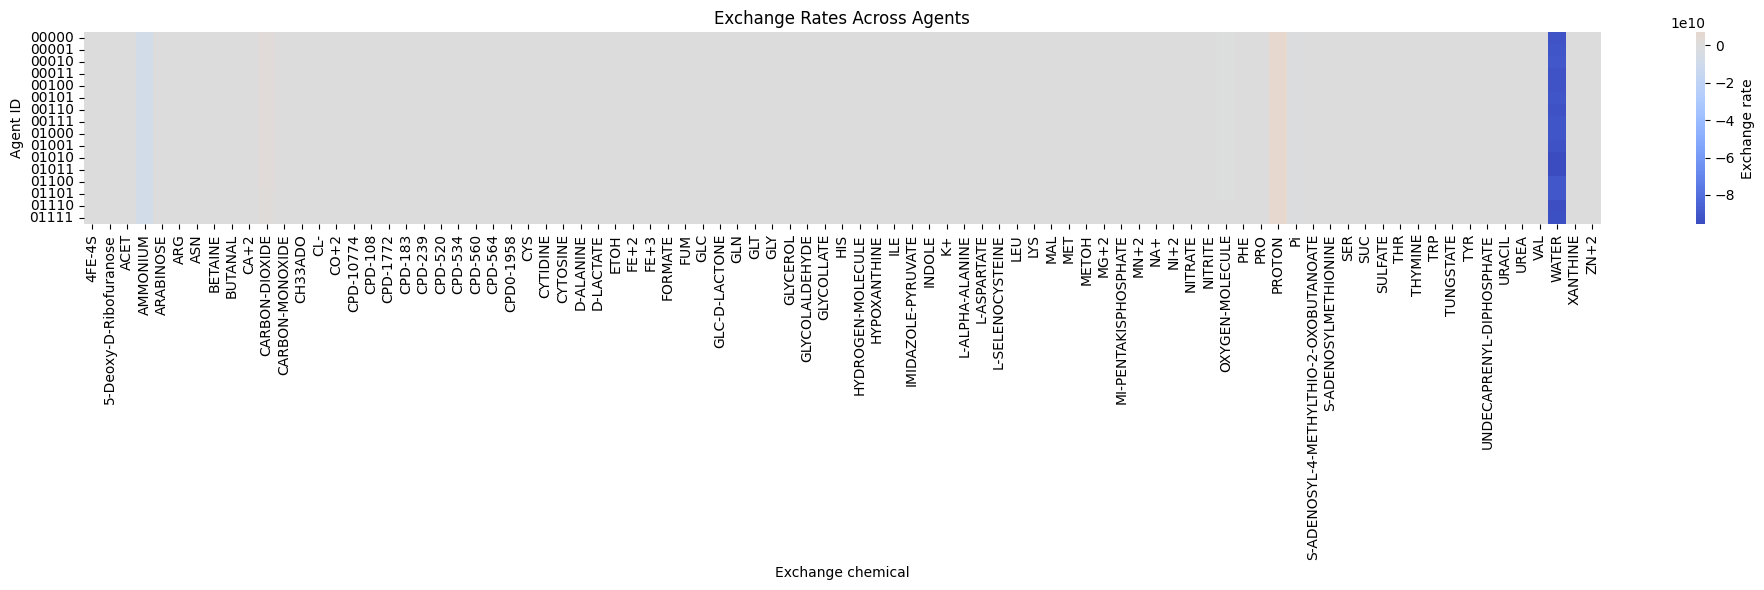

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Plot heatmap with auto-scaled height to avoid y-label overlap
fig_h = max(6, 0.22 * len(exchange_df))
fig_w = min(20, 0.5 * len(exchange_df.columns))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    exchange_df,
    cmap='coolwarm',
    center=0,
    annot=False,
    cbar_kws={'label': 'Exchange rate'},
    ax=ax
 )

# Thin y ticks when there are many agents (show at most ~40 labels)
step = max(1, len(exchange_df) // 40)
ax.set_yticks(np.arange(0, len(exchange_df), step) + 0.5)
ax.set_yticklabels(exchange_df.index[::step], rotation=0)

ax.set_xlabel('Exchange chemical')
ax.set_ylabel('Agent ID')
ax.set_title('Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

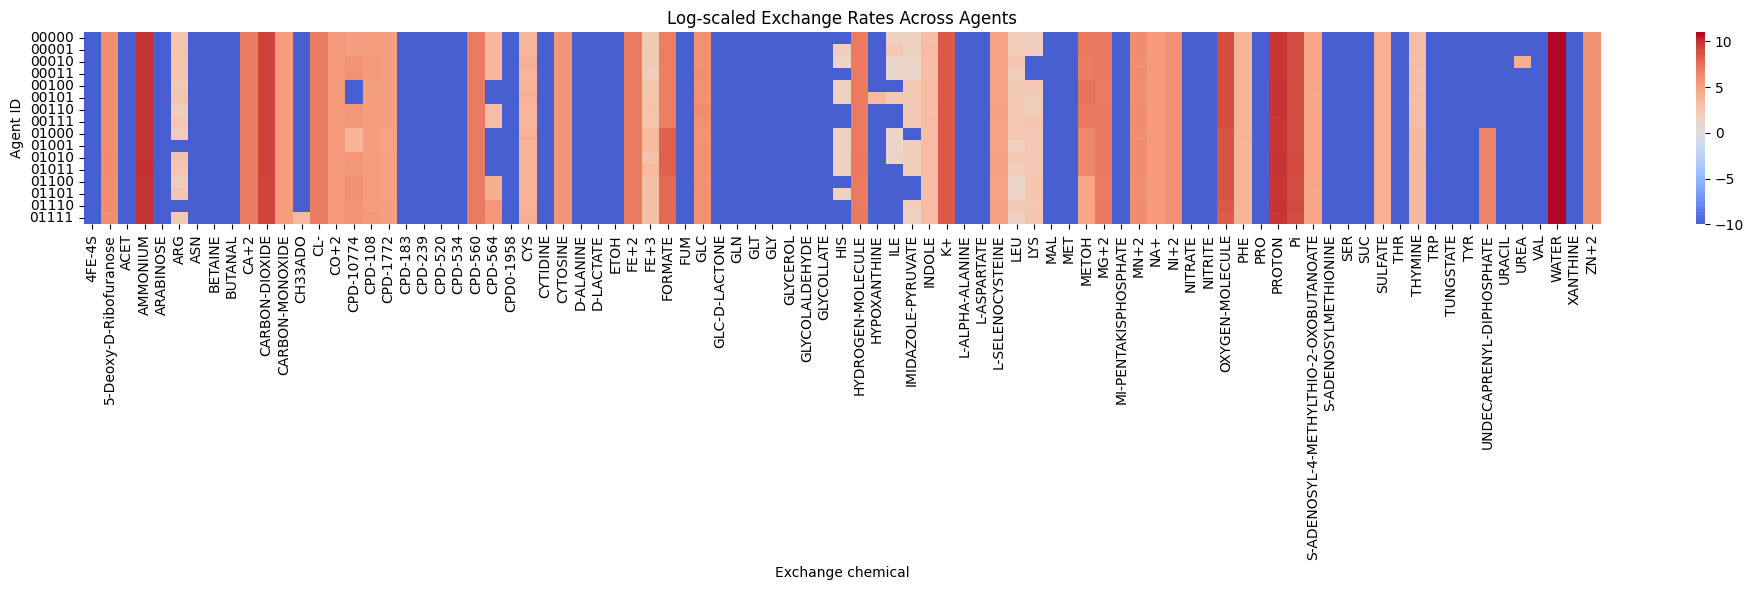

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_exchange_df = np.log10(np.abs(exchange_df) + e1)

# Plot heatmap with auto-scaled height to avoid y-label overlap
fig_h = max(6, 0.22 * len(log_exchange_df))
fig_w = min(20, 0.5 * len(log_exchange_df.columns))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(log_exchange_df, cmap='coolwarm', center=0, annot=False, ax=ax)

# Thin y ticks when there are many agents (show at most ~40 labels)
step = max(1, len(log_exchange_df) // 40)
ax.set_yticks(np.arange(0, len(log_exchange_df), step) + 0.5)
ax.set_yticklabels(log_exchange_df.index[::step], rotation=0)

ax.set_xlabel('Exchange chemical')
ax.set_ylabel('Agent ID')
ax.set_title('Log-scaled Exchange Rates Across Agents')
plt.tight_layout()
plt.savefig('/user/home/il22158/work/vEcoli/reading/results/colony/4th gen/log_scaled_exchanges_heatmap.png')
plt.show()

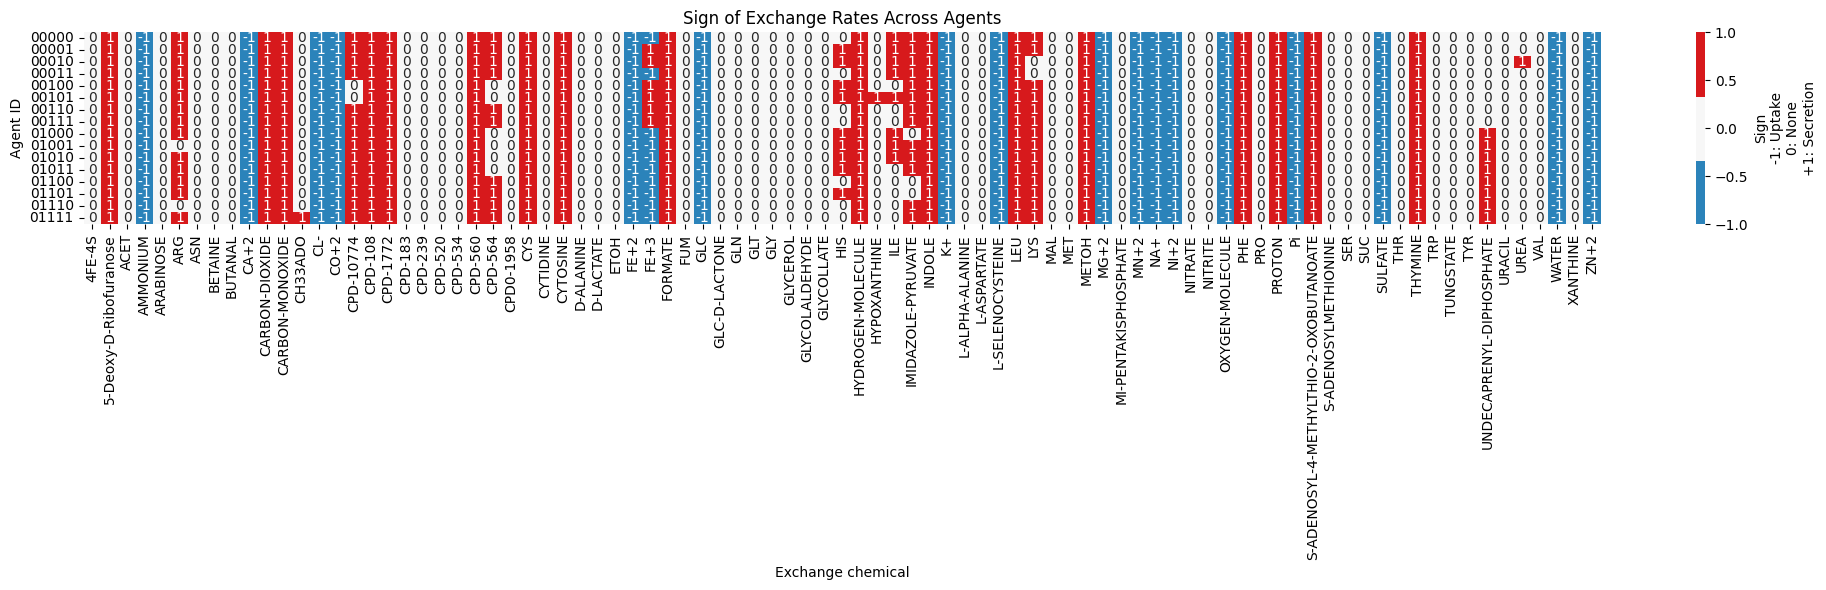

In [33]:
# Plot sign of exchange readings for each agent and chemical
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assumes exchange_df is defined: rows=agent_id, columns=chemicals
# If not, recreate exchange_df from your data as in previous cells

# Compute sign matrix: -1 (uptake), 0 (none), +1 (secretion)
sign_df = np.sign(exchange_df)

# Plot heatmap with auto-scaled height to avoid y-label overlap
fig_h = max(6, 0.22 * len(sign_df))
fig_w = min(20, 0.5 * len(sign_df.columns))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    sign_df,
    cmap=sns.color_palette(["#2b83ba", "#f7f7f7", "#d7191c"], as_cmap=True),
    center=0,
    annot=True,
    fmt="d",
    cbar_kws={'label': 'Sign\n-1: Uptake\n0: None\n+1: Secretion'},
    ax=ax
)

# Thin y ticks when there are many agents (show at most ~40 labels)
step = max(1, len(sign_df) // 40)
ax.set_yticks(np.arange(0, len(sign_df), step) + 0.5)
ax.set_yticklabels(sign_df.index[::step], rotation=0)

ax.set_xlabel('Exchange chemical')
ax.set_ylabel('Agent ID')
ax.set_title('Sign of Exchange Rates Across Agents')
plt.tight_layout()
plt.savefig('/user/home/il22158/work/vEcoli/reading/results/colony/4th gen/sign_exchanges_heatmap.png')
plt.show()

In [17]:
# Show first 5 zero exchange readings (agent, chemical, value)
import pandas as pd

# Find zero entries in exchange_df
zero_entries = []
for agent in exchange_df.index:
    for chem in exchange_df.columns:
        if exchange_df.loc[agent, chem] == 0:
            zero_entries.append((agent, chem, 0))
            if len(zero_entries) == 5:
                break
    if len(zero_entries) == 5:
        break

# Display
print("First 5 zero exchange readings:")
for entry in zero_entries:
    print(f"Agent: {entry[0]}, Chemical: {entry[1]}, Value: {entry[2]}")

First 5 zero exchange readings:
Agent: 00000, Chemical: 4FE-4S, Value: 0
Agent: 00000, Chemical: ACET, Value: 0
Agent: 00000, Chemical: ARABINOSE, Value: 0
Agent: 00000, Chemical: ASN, Value: 0
Agent: 00000, Chemical: BETAINE, Value: 0


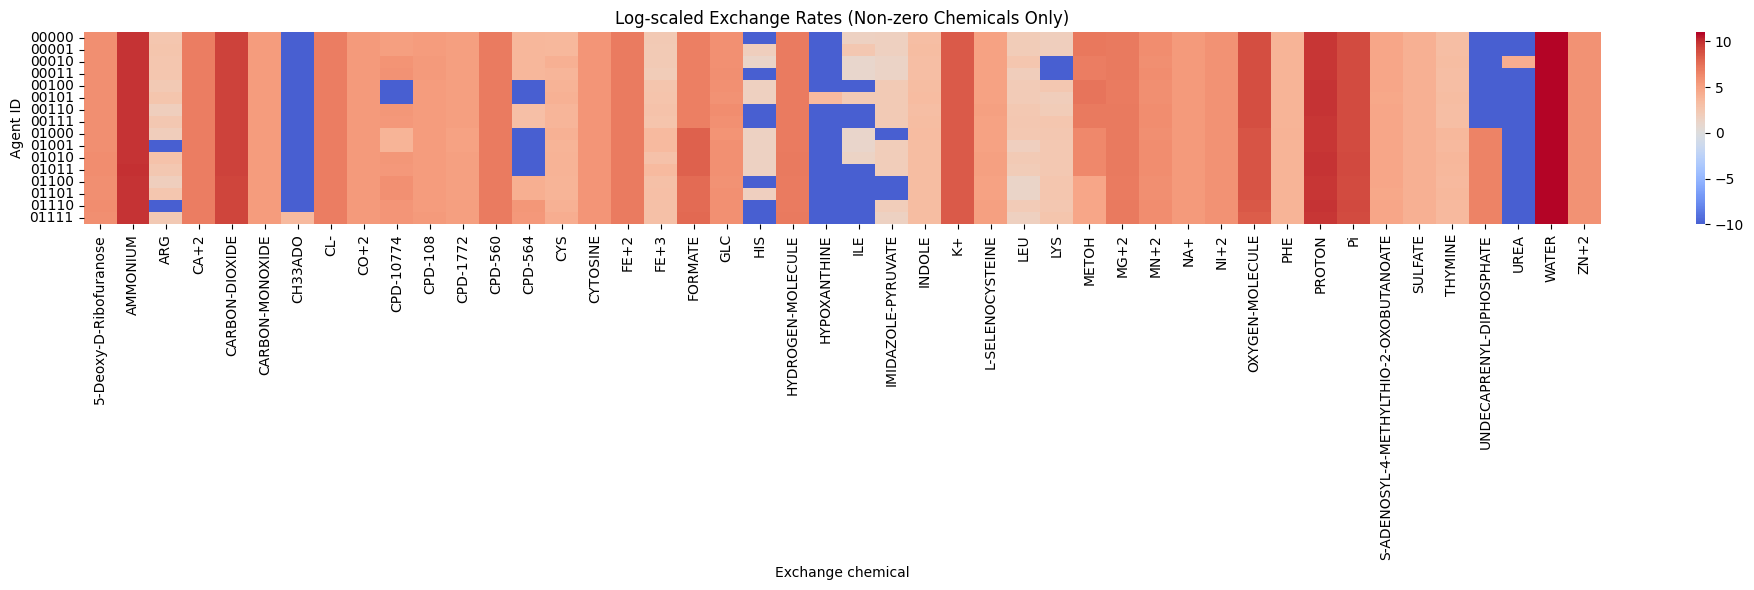

In [37]:
# Plot log-scaled heatmap for chemicals with at least one non-zero value
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter columns (chemicals) with at least one non-zero value
nonzero_chems = exchange_df.columns[(exchange_df != 0).any(axis=0)]
filtered_df = exchange_df[nonzero_chems]

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_filtered_df = np.log10(np.abs(filtered_df) + e1)

# Plot heatmap with auto-scaled height to avoid y-label overlap
fig_h = max(6, 0.22 * len(log_filtered_df))
fig_w = min(20, 0.5 * len(log_filtered_df.columns))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(log_filtered_df, cmap='coolwarm', center=0, annot=False, ax=ax)

# Thin y ticks when there are many agents (show at most ~40 labels)
step = max(1, len(log_filtered_df) // 40)
ax.set_yticks(np.arange(0, len(log_filtered_df), step) + 0.5)
ax.set_yticklabels(log_filtered_df.index[::step], rotation=0)

ax.set_xlabel('Exchange chemical')
ax.set_ylabel('Agent ID')
ax.set_title('Log-scaled Exchange Rates (Non-zero Chemicals Only)')
plt.tight_layout()
plt.savefig('/user/home/il22158/work/vEcoli/reading/results/colony/4th gen/log_scaled_nonzero_exchanges_heatmap.png')
plt.show()

## From 2gen to 8gen

### Multi-generation loading and extraction (2gen, 3rd, 4th, 5th, 7th)

This section reuses the same JSON loading style and environment-exchange extraction pattern used in **Spatial Layout - 4th gen** and **Env Factors - 4th gen**.

- Load one JSON per selected generation configuration.
- Extract agent-level environment exchange readings.
- Aggregate to generation-level summaries and chemical-level means for visual comparison.
- Current comparison intentionally excludes 6th and 8th due to missing clean snapshots.

In [13]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd

# --- Configure generation sources ---
# Compare only the generations with currently reliable snapshots.
GEN_CONFIG = [
    {"generation": 2, "path": "/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json", "target_generation": 2},
    {"generation": 3, "path": "/user/home/il22158/work/vEcoli/data/baseline_3rd_gen_seed_0_colony_t3000.json", "target_generation": 3},
    {"generation": 4, "path": "/user/home/il22158/work/vEcoli/data/baseline_4th_gen_seed_0_colony_t3000.json", "target_generation": 4},
    {"generation": 5, "path": "/user/home/il22158/work/vEcoli/data/baseline_5th_to_8th_gen_seed_0_colony_t3000.json", "target_generation": 5},
    {"generation": 7, "path": "/user/home/il22158/work/vEcoli/data/baseline_5th_to_8th_gen_seed_0_colony_t9000.json", "target_generation": 7},
]


def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()


def generation_from_agent_id(agent_id):
    # Binary lineage ID depth used throughout this notebook
    return len(str(agent_id)) - 1


def parse_unit(value):
    # Handles strings like '!units[12.34 micrometer]' and regular numerics
    if isinstance(value, str) and value.startswith("!units["):
        match = re.search(r"\[([-\d.eE+]+)", value)
        return float(match.group(1)) if match else np.nan
    return pd.to_numeric(value, errors="coerce")


records = []
all_chemicals = set()
available_generations = []

for item in GEN_CONFIG:
    gen = item["generation"]
    json_path = Path(item["path"])
    target_gen = item.get("target_generation", gen)

    if not json_path.exists():
        print(f"[skip] Gen {gen}: file not found -> {json_path}")
        continue

    with open(json_path, "r") as f:
        data = json.load(f)

    agents = data.get("agents", {})
    if not agents:
        print(f"[skip] Gen {gen}: no agents in file -> {json_path.name}")
        continue

    selected_agents = {
        aid: a for aid, a in agents.items()
        if generation_from_agent_id(aid) == target_gen
    }

    if not selected_agents:
        print(
            f"[skip] Gen {gen}: no agents matched target_generation={target_gen} "
            f"in {json_path.name}"
        )
        continue

    available_generations.append(gen)

    for agent_id, agent in selected_agents.items():
        env = agent.get("environment", {})
        exchange = env.get("exchange", {})
        boundary = agent.get("boundary", {})
        listeners = agent.get("listeners", {})
        mass_listener = listeners.get("mass", {})

        location = boundary.get("location", [np.nan, np.nan])
        x = parse_unit(location[0] if isinstance(location, (list, tuple)) and len(location) > 0 else np.nan)
        y = parse_unit(location[1] if isinstance(location, (list, tuple)) and len(location) > 1 else np.nan)

        instantaneous_growth_rate = pd.to_numeric(
            mass_listener.get("instantaneous_growth_rate", mass_listener.get("growth", np.nan)),
            errors="coerce"
        )

        row = {
            "generation": gen,
            "agent_id": agent_id,
            "global_time": pd.to_numeric(agent.get("global_time", np.nan), errors="coerce"),
            "media_id": env.get("media_id", None),
            "x": x,
            "y": y,
            "n_exchanges": len(exchange),
            "instantaneous_growth_rate": instantaneous_growth_rate,
        }

        for chem, rate in exchange.items():
            chem_name = normalize_exchange_name(chem)
            row[f"ex__{chem_name}"] = rate
            all_chemicals.add(chem_name)

        records.append(row)

multi_gen_df = pd.DataFrame(records)
exchange_cols = sorted([c for c in multi_gen_df.columns if c.startswith("ex__")])

if len(exchange_cols) > 0:
    multi_gen_df[exchange_cols] = multi_gen_df[exchange_cols].fillna(0.0)

# Generation-level summary
summary_rows = []
for gen, sub in multi_gen_df.groupby("generation", sort=True):
    x_vals = pd.to_numeric(sub["x"], errors="coerce")
    y_vals = pd.to_numeric(sub["y"], errors="coerce")

    if len(exchange_cols) > 0:
        ex_values = sub[exchange_cols].to_numpy(dtype=float)
        mean_abs_exchange = np.abs(ex_values).mean()
        net_exchange = ex_values.sum()
    else:
        mean_abs_exchange = np.nan
        net_exchange = np.nan

    summary_rows.append({
        "generation": gen,
        "n_cells": len(sub),
        "global_time": pd.to_numeric(sub["global_time"], errors="coerce").mean(),
        "mean_n_exchanges": pd.to_numeric(sub["n_exchanges"], errors="coerce").mean(),
        "mean_growth_rate_json": pd.to_numeric(sub["instantaneous_growth_rate"], errors="coerce").mean(),
        "mean_abs_exchange": mean_abs_exchange,
        "net_exchange": net_exchange,
        "x_span": x_vals.max() - x_vals.min(),
        "y_span": y_vals.max() - y_vals.min(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("generation")

# Chemical-level mean exchange by generation (heatmap matrix)
if len(exchange_cols) > 0:
    chemical_matrix = (
        multi_gen_df
        .groupby("generation", sort=True)[exchange_cols]
        .mean()
        .rename(columns=lambda c: c.replace("ex__", ""))
    )
else:
    chemical_matrix = pd.DataFrame()

print("Available generations:", sorted(available_generations))
print("Rows in multi_gen_df:", len(multi_gen_df))
print("\nGeneration summary:")
display(summary_df)

if not chemical_matrix.empty:
    print("\nChemical matrix shape (generation x chemical):", chemical_matrix.shape)
else:
    print("\nChemical matrix is empty (no exchange data found).")

Available generations: [2, 3, 4, 5, 7]
Rows in multi_gen_df: 180

Generation summary:


,generation,n_cells,global_time,mean_n_exchanges,mean_growth_rate_json,mean_abs_exchange,net_exchange,x_span,y_span
0,2,4,6000.0,87.0,0.000254,6.556996e+08,-1.916056e+11,2.283273,2.682633
1,3,8,9000.0,87.0,0.000273,9.822350e+08,-5.721869e+11,3.892374,3.929725
2,4,16,12000.0,87.0,0.000237,1.283228e+09,-1.494574e+12,5.856142,5.186683
3,5,32,15000.0,87.0,0.000235,1.581871e+09,-3.682636e+12,8.980611,8.138641
4,7,120,21000.0,87.0,0.000224,2.184935e+09,-1.906275e+13,18.505664,17.194990



Chemical matrix shape (generation x chemical): (5, 87)


In [4]:
# Save extracted chemical matrix to CSV
if not chemical_matrix.empty:
    chemical_matrix_path = "/user/home/il22158/work/vEcoli/reading/results/colony/exchange_chemical_matrix_23457_gen.csv"
    chemical_matrix.to_csv(chemical_matrix_path)
    print(f"Saved chemical matrix to: {chemical_matrix_path}")

Saved chemical matrix to: /user/home/il22158/work/vEcoli/reading/results/colony/exchange_chemical_matrix_23457_gen.csv


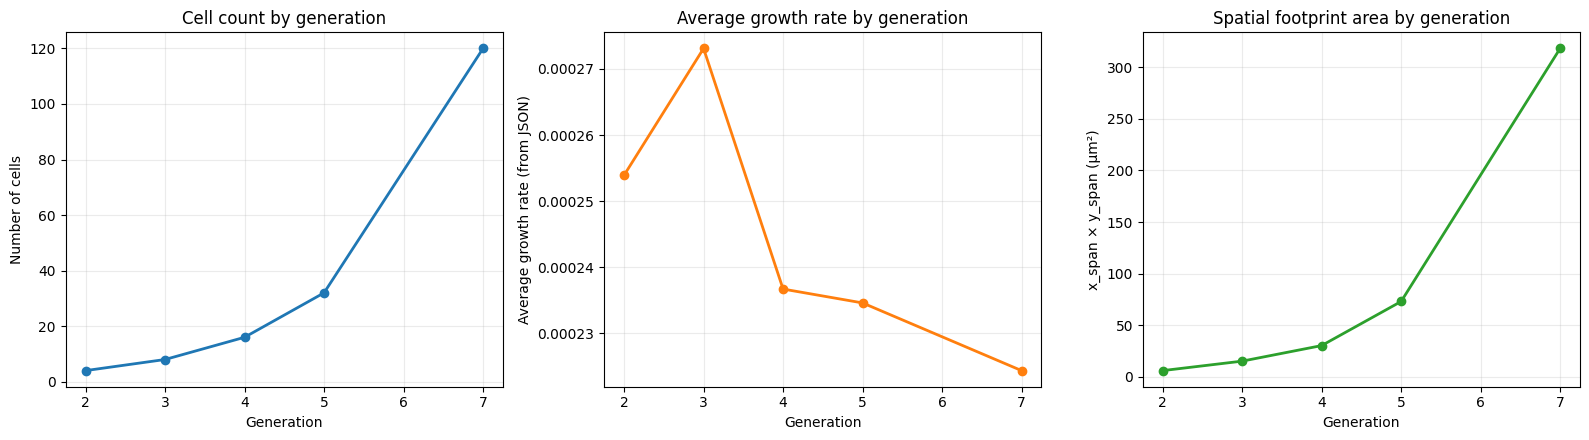

Saved: /user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen/generation_summary_trends.png


/tmp/ipykernel_92713/3765105434.py:66: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


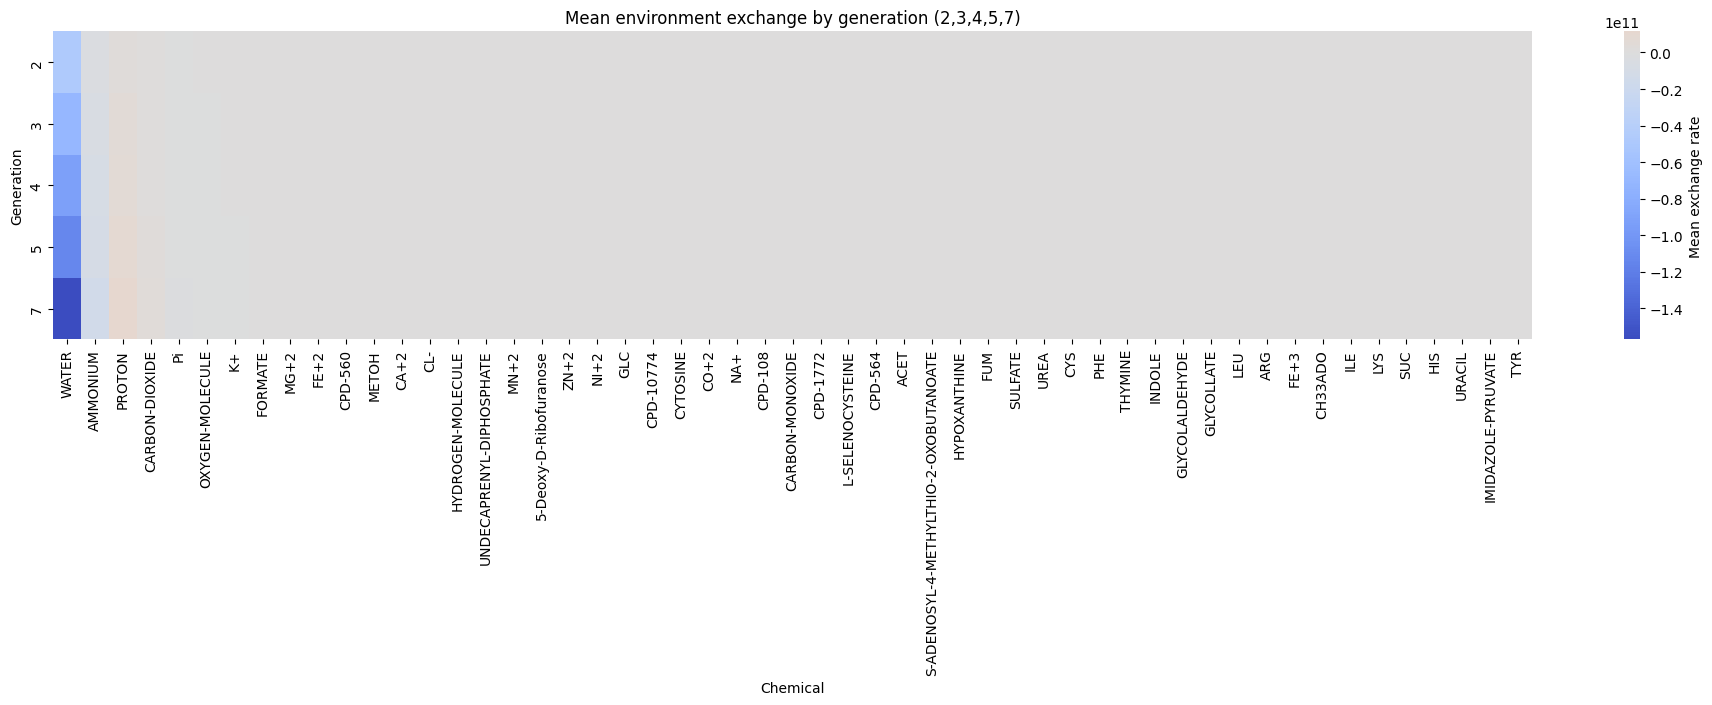

Saved: /user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen/mean_exchange_heatmap_by_generation.png
Saved: /user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen/generation_summary.csv
Saved: /user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen/chemical_mean_exchange_matrix.csv


In [14]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

out_dir = Path('/user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen')
out_dir.mkdir(parents=True, exist_ok=True)

# --- Figure 1: generation-wise summary trends ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) Number of cells
axes[0].plot(summary_df['generation'], summary_df['n_cells'], marker='o', linewidth=2)
axes[0].set_title('Cell count by generation')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Number of cells')
axes[0].grid(alpha=0.25)

# 2) Average growth rate read directly from JSON
axes[1].plot(summary_df['generation'], summary_df['mean_growth_rate_json'], marker='o', linewidth=2, color='tab:orange')
axes[1].set_title('Average growth rate by generation')
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Average growth rate (from JSON)')
axes[1].grid(alpha=0.25)

# 3) Spatial footprint area (x_span * y_span) in square micrometers
spatial_area_um2 = np.clip(summary_df['x_span'] * summary_df['y_span'], a_min=0, a_max=None)
axes[2].plot(summary_df['generation'], spatial_area_um2, marker='o', linewidth=2, color='tab:green')
axes[2].set_title('Spatial footprint area by generation')
axes[2].set_xlabel('Generation')
axes[2].set_ylabel('x_span × y_span (μm²)')
axes[2].grid(alpha=0.25)

plt.tight_layout()
fig1_path = out_dir / 'generation_summary_trends.png'
plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig1_path}')

# --- Figure 2: heatmap of mean exchange per chemical across generations ---
if chemical_matrix.empty:
    print('No exchange matrix to plot.')
else:
    # Keep only informative chemicals (at least one non-zero mean)
    informative = chemical_matrix.columns[(chemical_matrix.abs().sum(axis=0) > 0)]
    heat_df = chemical_matrix[informative]

    # Optional: rank chemicals by max absolute signal across generations
    ranked_cols = heat_df.abs().max(axis=0).sort_values(ascending=False).index
    heat_df = heat_df[ranked_cols]

    fig_w = max(10, 0.45 * max(1, heat_df.shape[1]))
    fig_h = max(4, 0.65 * max(1, heat_df.shape[0]))

    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(
        heat_df,
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Mean exchange rate'}
    )
    plt.title('Mean environment exchange by generation (2,3,4,5,7)')
    plt.xlabel('Chemical')
    plt.ylabel('Generation')
    plt.tight_layout()

    fig2_path = out_dir / 'mean_exchange_heatmap_by_generation.png'
    plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig2_path}')

# Save extracted tables for downstream analysis
summary_path = out_dir / 'generation_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f'Saved: {summary_path}')

if not chemical_matrix.empty:
    matrix_path = out_dir / 'chemical_mean_exchange_matrix.csv'
    chemical_matrix.to_csv(matrix_path)
    print(f'Saved: {matrix_path}')

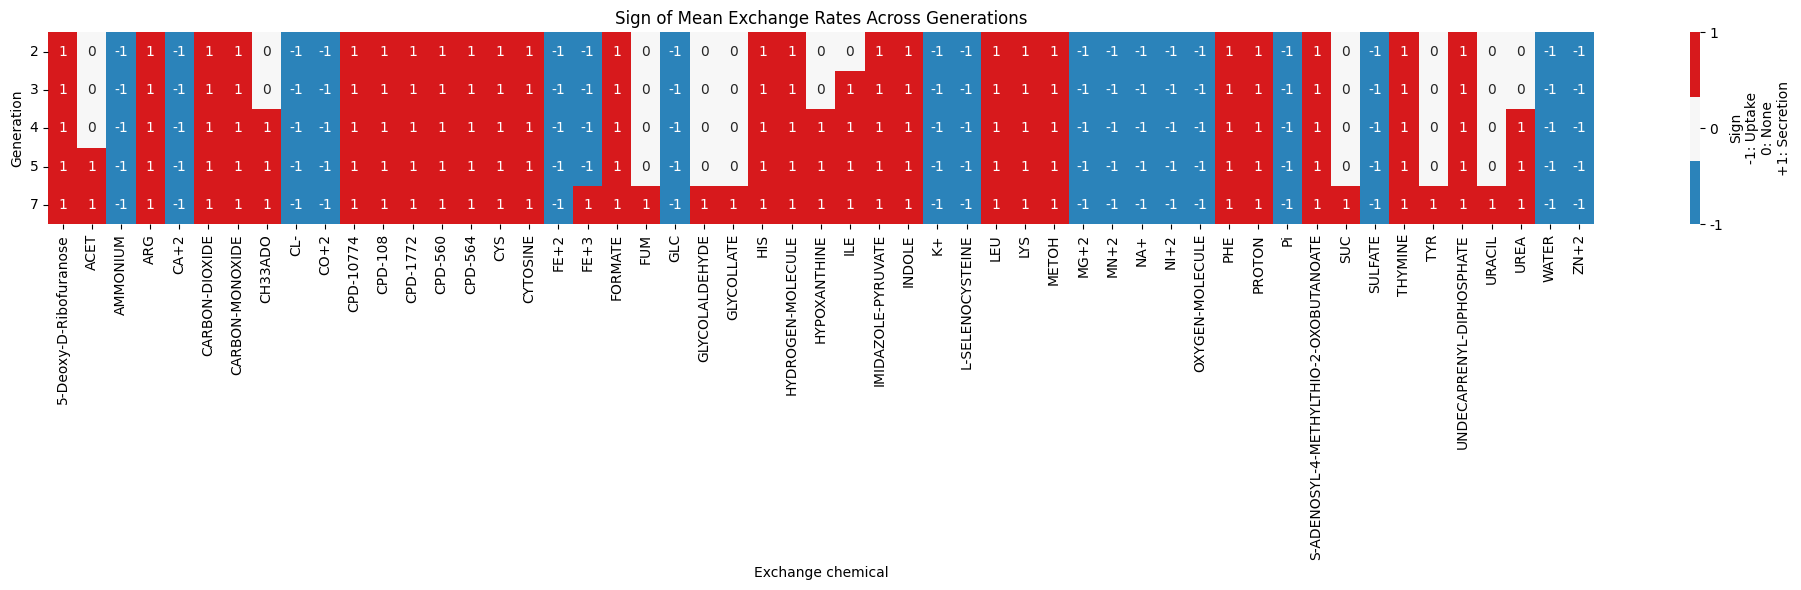

Saved: /user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen/sign_exchanges_heatmap_by_generation.png


In [19]:
# Plot sign of exchange readings for each generation and chemical
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Use generation-level exchange matrix from previous cells
if 'chemical_matrix' not in globals() or chemical_matrix.empty:
    raise ValueError('chemical_matrix is missing or empty. Run the extraction/summary cell first.')

# Keep all chemicals with at least one non-zero reading across generations
non_zero_cols = chemical_matrix.columns[(chemical_matrix.abs().sum(axis=0) > 0)]
exchange_df = chemical_matrix[non_zero_cols].copy()

# Compute sign matrix: -1 (uptake), 0 (none), +1 (secretion)
sign_df = np.sign(exchange_df).astype(int)

# Plot heatmap with early-code auto-scaled sizing
fig_h = max(6, 0.22 * len(sign_df))
fig_w = min(20, 0.5 * len(sign_df.columns))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

heat = sns.heatmap(
    sign_df,
    cmap=sns.color_palette(["#2b83ba", "#f7f7f7", "#d7191c"], as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='d',
    cbar_kws={'label': 'Sign\n-1: Uptake\n0: None\n+1: Secretion', 'ticks': [-1, 0, 1]},
    ax=ax
)

# Force legend ticks to only -1, 0, 1
colorbar = heat.collections[0].colorbar
colorbar.set_ticks([-1, 0, 1])
colorbar.set_ticklabels(['-1', '0', '1'])

# Thin y ticks when there are many rows
step = max(1, len(sign_df) // 40)
ax.set_yticks(np.arange(0, len(sign_df), step) + 0.5)
ax.set_yticklabels(sign_df.index.astype(str)[::step], rotation=0)

ax.set_xlabel('Exchange chemical')
ax.set_ylabel('Generation')
ax.set_title('Sign of Mean Exchange Rates Across Generations')
plt.tight_layout()

out_dir = Path('/user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen')
out_dir.mkdir(parents=True, exist_ok=True)
sign_fig_path = out_dir / 'sign_exchanges_heatmap_by_generation.png'
plt.savefig(sign_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {sign_fig_path}')

/tmp/ipykernel_92713/3614784631.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


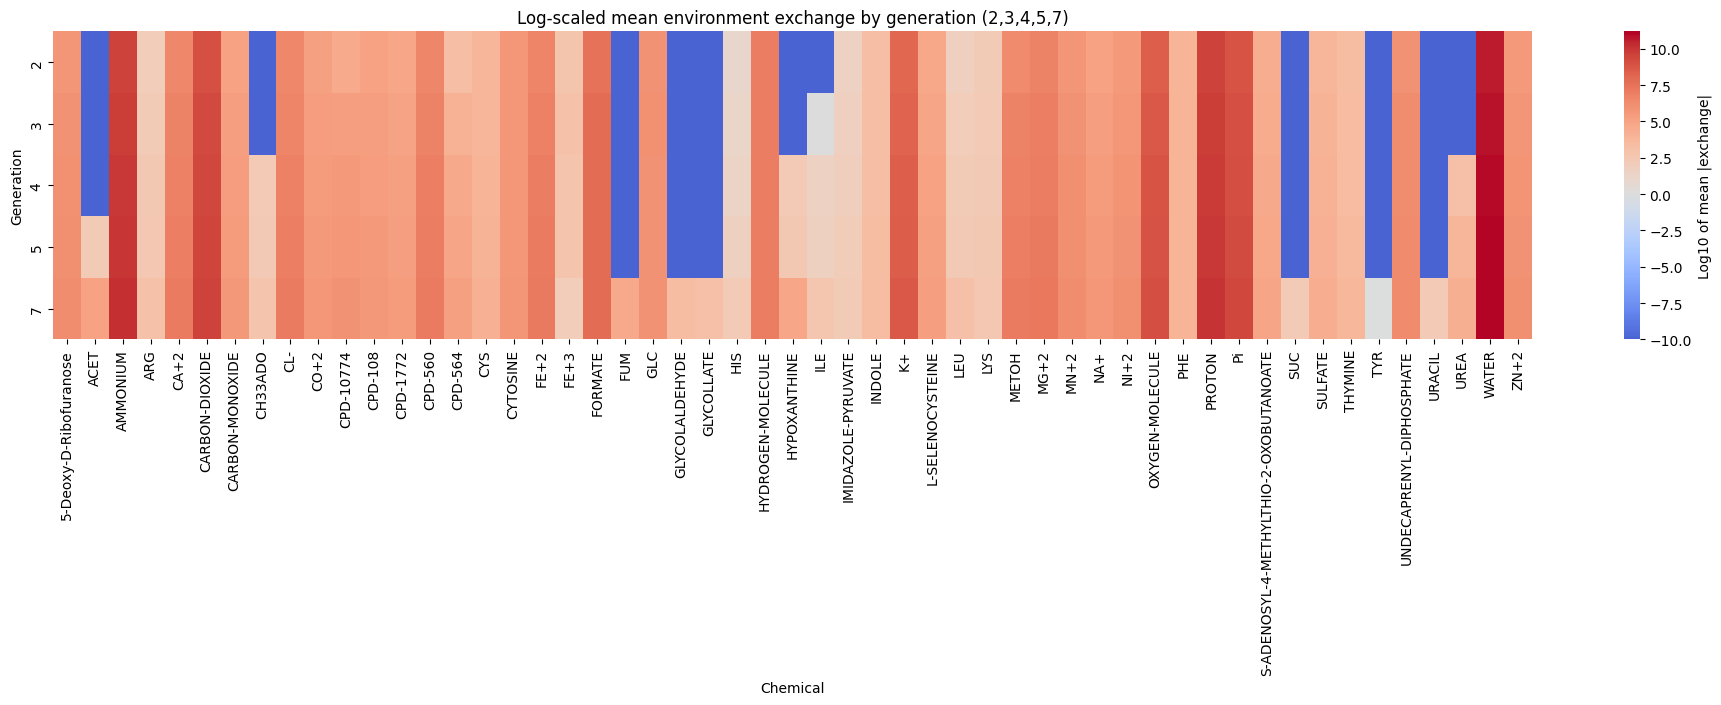

Saved: /user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_8gen/log_scaled_mean_exchange_heatmap_by_generation.png


In [6]:
# Use log-scaled heatmap for better visibility of smaller exchange values across generations
if chemical_matrix.empty:
    print('No exchange matrix to plot.')
else:   
    informative = chemical_matrix.columns[(chemical_matrix.abs().sum(axis=0) > 0)]
    filtered_df = chemical_matrix[informative]

    e1 = 1e-10
    log_filtered_df = np.log10(np.abs(filtered_df) + e1)

    fig_w = max(10, 0.45 * max(1, log_filtered_df.shape[1]))
    fig_h = max(4, 0.65 * max(1, log_filtered_df.shape[0]))

    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(
        log_filtered_df,
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Log10 of mean |exchange|'}
    )
    plt.title('Log-scaled mean environment exchange by generation (2,3,4,5,7)')
    plt.xlabel('Chemical')
    plt.ylabel('Generation')
    plt.tight_layout()

    log_fig_path = out_dir / 'log_scaled_mean_exchange_heatmap_by_generation.png'
    plt.savefig(log_fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {log_fig_path}')

# Compare 2th generation colony simulation with single-cell

## Load data

In [ ]:
import json

with open('/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json', 'r') as f:
    data = json.load(f)

agents = data['agents']
agent_ids = sorted(agents.keys())

# Get all unique keys (categories) across all agents
all_keys = set()
for agent in agents.values():
    all_keys.update(agent.keys())

print("Agent names (IDs):")
print(agent_ids)
print("\nUnique categories (keys):")
print(sorted(all_keys)

Agent names (IDs):
['000', '001', '010', '011']

Unique categories (keys):
['allocate', 'allocator_rng', 'boundary', 'bulk', 'bulk_dtypes', 'cytoplasm', 'divide', 'division_threshold', 'division_trigger', 'environment', 'global_time', 'listeners', 'next_update_time', 'periplasm', 'process_state', 'request', 'timeline', 'timestep', 'unique', 'unique_dtypes']


In [4]:
# Show dtype and preview for each category for the first agent
sample_agent = agents[agent_ids[0]]
print(f"\n--- Data preview for agent '{agent_ids[0]}' ---")
for key in sorted(all_keys):
    value = sample_agent.get(key, None)
    print(f"\nCategory: '{key}'")
    print(f"Type: {type(value)}")
    if isinstance(value, dict):
        subkeys = sorted(value.keys())
        print(f"Exclusive subcategories: {subkeys}")
    elif isinstance(value, list):
        print(f"Length: {len(value)}")
        print(f"First 3 entries: {value[:3]}")
    else:
        print(f"Value: {value}")


--- Data preview for agent '000' ---

Category: 'allocate'
Type: <class 'dict'>
Exclusive subcategories: ['ecoli-chromosome-replication', 'ecoli-complexation', 'ecoli-equilibrium', 'ecoli-polypeptide-elongation', 'ecoli-polypeptide-initiation', 'ecoli-protein-degradation', 'ecoli-rna-degradation', 'ecoli-rna-maturation', 'ecoli-transcript-elongation', 'ecoli-transcript-initiation', 'ecoli-two-component-system']

Category: 'allocator_rng'
Type: <class 'str'>
Value: !RandomStateSerializer[('MT19937', [1032081874, 3921390043, 1775671866, 3050400842, 613040236, 3120117409, 313685, 4009028496, 3451362311, 1611313565, 1216908950, 1280315550, 2094310855, 486956331, 2341192965, 835091154, 3469137642, 701790974, 3147330632, 4284971845, 196483250, 3605856335, 2998782482, 1551059047, 772023894, 3028362759, 2054139155, 1697376821, 3256171168, 1295408492, 409809183, 2117531738, 1695919879, 3445769087, 3326475278, 232416836, 3552623864, 3205095980, 1077074508, 4278080904, 2968265471, 3704500986, 38

In ''bulk'', ''submass'' refers to the contribution of a chemical to a specific cellular mass compartment. The bulk_dtypes field lists submass types such as rRNA_submass, tRNA_submass, mRNA_submass, miscRNA_submass, nonspecific_RNA_submass, protein_submass, metabolite_submass, water_submass, DNA_submass.

For each chemical, only one submass field is typically non-zero, corresponding to the compartment that chemical belongs to. For example:

If the chemical is a protein, only protein_submass will be non-zero.
If it’s a metabolite, only metabolite_submass will be non-zero.
If it’s an rRNA, only rRNA_submass will be non-zero.

In [5]:
# Preview exclusive lists for both 'exchange' and 'media_id' subcategories across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_ids.add(env.get('media_id', None))

print("Exclusive list of all exchange chemicals across agents:")
print(sorted(exchange_keys))
print("\nExclusive list of all media_id values across agents:")
print(sorted(media_ids))


Exclusive list of all exchange chemicals across agents:
['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE', 'ARG', 'ASN', 'BETAINE', 'BUTANAL', 'CA+2', 'CARBON-DIOXIDE', 'CARBON-MONOXIDE', 'CH33ADO', 'CL-', 'CO+2', 'CPD-10774', 'CPD-108', 'CPD-1772', 'CPD-183', 'CPD-239', 'CPD-520', 'CPD-534', 'CPD-560', 'CPD-564', 'CPD0-1958', 'CYS', 'CYTIDINE', 'CYTOSINE', 'D-ALANINE', 'D-LACTATE', 'ETOH', 'FE+2', 'FE+3', 'FORMATE', 'FUM', 'GLC', 'GLC-D-LACTONE', 'GLN', 'GLT', 'GLY', 'GLYCEROL', 'GLYCOLALDEHYDE', 'GLYCOLLATE', 'HIS', 'HYDROGEN-MOLECULE', 'HYPOXANTHINE', 'ILE', 'IMIDAZOLE-PYRUVATE', 'INDOLE', 'K+', 'L-ALPHA-ALANINE', 'L-ASPARTATE', 'L-SELENOCYSTEINE', 'LEU', 'LYS', 'MAL', 'MET', 'METOH', 'MG+2', 'MI-PENTAKISPHOSPHATE', 'MN+2', 'NA+', 'NI+2', 'NITRATE', 'NITRITE', 'OXYGEN-MOLECULE', 'PHE', 'PRO', 'PROTON', 'Pi', 'S-ADENOSYL-4-METHYLTHIO-2-OXOBUTANOATE', 'S-ADENOSYLMETHIONINE', 'SER', 'SUC', 'SULFATE', 'THR', 'THYMINE', 'TRP', 'TUNGSTATE', 'TYR', 'UNDECAPRENYL-DIPHOSPH

**Preview of 'environment' subcategories for the first agent**

- **exchange**: Dictionary of chemicals exchanged between cell and environment.
    - Keys ex: ['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE']
    - Each key represents a chemical compound relevant to E. coli's metabolism in minimal media.
    - Example values: Show first few exchange rates if available.

- **media_id**: String indicating the media type.
    - Value ex: 'minimal'
    - This specifies the simulation is run in minimal medium, restricting available nutrients.

**Brief explanations of the first 5 exchange chemicals:**

- **4FE-4S**: Iron-sulfur cluster, essential for enzyme function and electron transfer.
- **5-Deoxy-D-Ribofuranose**: Rare sugar, involved in nucleotide metabolism.
- **ACET**: Acetate, carbon source and metabolic byproduct.
- **AMMONIUM**: Ammonium ion, primary nitrogen source.
- **ARABINOSE**: Arabinose, pentose sugar, alternative carbon source.


In [6]:
# Confirm that all agents have exactly 5 environment exchanges
exchange_counts = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_counts.append(len(exchange))

unique_counts = set(exchange_counts)
print(f"Unique exchange counts across all agents: {unique_counts}")
if unique_counts == {5}:
    print("All agents have exactly 5 environment exchanges.")
else:
    print(f"Some agents have different numbers of exchanges: {unique_counts}")
# Optionally, print agent IDs with non-5 exchanges
for agent_id, count in zip(agent_ids, exchange_counts):
    if count != 5:
        print(f"Agent {agent_id} has {count} exchanges.")


Unique exchange counts across all agents: {87}
Some agents have different numbers of exchanges: {87}
Agent 000 has 87 exchanges.
Agent 001 has 87 exchanges.
Agent 010 has 87 exchanges.
Agent 011 has 87 exchanges.


In [7]:
import os
import pandas as pd

# Collect exclusive lists for exchange chemicals and media_ids across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_id = env.get('media_id', None)
    if media_id is not None:
        media_ids.add(media_id)

# Prepare DataFrame
results_df = pd.DataFrame({
    'exchange_chemical': sorted(exchange_keys),
})

# Save unique media_ids separately
media_ids_path = '/user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv'
pd.DataFrame({'media_id': sorted(media_ids)}).to_csv(media_ids_path, index=False)

# Ensure output directory exists
output_dir = '/user/home/il22158/work/vEcoli/reading/results/colony'
os.makedirs(output_dir, exist_ok=True)

# Save unique exchange chemicals
output_path = os.path.join(output_dir, 'unique_exchanges.csv')
results_df.to_csv(output_path, index=False)
print(f"Saved unique exchange chemicals to: {output_path}")
print(f"Saved unique media_ids to: {media_ids_path}")

Saved unique exchange chemicals to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_exchanges.csv
Saved unique media_ids to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv


## Extract exchange rates

In [8]:
from pathlib import Path
import re

import pandas as pd

project_name = "baseline_2gen_seed_0_colony_t6000"

def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()

# Build wide matrix first: rows=agents, columns=chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get("environment", {})
    exchange = env.get("exchange", {})

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange_rate": exchange_df.mean(axis=0).values,
        "mean_abs_exchange_rate": exchange_df.abs().mean(axis=0).values,
        "max_exchange_rate": exchange_df.max(axis=0).values,
        "min_exchange_rate": exchange_df.min(axis=0).values,
        "max_abs_exchange_rate": exchange_df.abs().max(axis=0).values,
    }
).sort_values(
    by="max_abs_exchange_rate",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange_rate,mean_abs_exchange_rate,max_exchange_rate,min_exchange_rate,max_abs_exchange_rate
0,WATER,-4.732753e+10,4.732753e+10,-46653325381,-47946468814,47946468814
1,AMMONIUM,-4.115869e+09,4.115869e+09,-4075870702,-4149945034,4149945034
2,PROTON,3.471591e+09,3.471591e+09,3493226680,3445322140,3493226680
3,CARBON-DIOXIDE,1.048475e+09,1.048475e+09,1091144721,997691067,1091144721
4,Pi,-6.368939e+08,6.368939e+08,-630611371,-642199447,642199447
...,...,...,...,...,...,...
82,TYR,0.000000e+00,0.000000e+00,0,0,0
83,UREA,0.000000e+00,0.000000e+00,0,0,0
84,URACIL,0.000000e+00,0.000000e+00,0,0,0
85,VAL,0.000000e+00,0.000000e+00,0,0,0


Shape: (87, 6)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_2gen_seed_0_colony_t6000.csv


In [ ]:
import json
import math
import re

UNIT_RE = re.compile(r"^!units\[(.+?)\s+([^\]]+)\]$", re.IGNORECASE)

def parse_units_token(raw):
    """
    raw: e.g. '!units[0.987 millimolar]' or '!units[inf millimolar]'
    returns dict with value, unit, is_inf, is_units_token
    """
    if not isinstance(raw, str):
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    m = UNIT_RE.match(raw.strip())
    if not m:
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    val_str, unit = m.group(1).strip(), m.group(2).strip()
    is_inf = val_str.lower() in {"inf", "+inf", "infinity", "+infinity", "∞"}

    if is_inf:
        value = math.inf
    else:
        value = float(val_str)

    return {"value": value, "unit": unit, "is_inf": is_inf, "is_units_token": True}


# Example: read from colony JSON and mark infinite-availability entities
with open("/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json", "r") as f:
    data = json.load(f)

agents = data["agents"]
inf_entities = set()

for agent_id, agent in agents.items():
    ext = agent.get("boundary", {}).get("external", {})
    for mol, raw in ext.items():
        parsed = parse_units_token(raw)
        if parsed["is_inf"] and parsed["unit"].lower() == "millimolar":
            inf_entities.add(mol)

print("Inf-available molecules:", sorted(inf_entities))

# Later comparison: exclude these
# filtered_df = df[~df["chemical"].isin(inf_entities)]

Inf-available molecules: ['CARBON-DIOXIDE', 'CO+2', 'FE+2', 'L-SELENOCYSTEINE', 'MN+2', 'NI+2', 'OXYGEN-MOLECULE', 'WATER', 'ZN+2']


In [ ]:
out_dir = Path("/user/home/il22158/work/vEcoli/reading/results/colony")
file_name = f"inf_available_chemicals__{project_name}.csv"
out_path = out_dir / file_name
pd.DataFrame({"chemical": sorted(inf_entities)}).to_csv(out_path, index=False)
print(f"Saved inf-available chemicals: {out_path}")

Saved inf-available chemicals: /user/home/il22158/work/vEcoli/reading/results/colony/inf_available_chemicals__baseline_2gen_seed_0_colony_t6000.csv


In [ ]:
import json

json_path = "/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json"

with open(json_path, "r") as f:
    data = json.load(f)

agents = data["agents"]

# Print mmol_to_counts for each agent (raw value from JSON)
for agent_id in sorted(agents):
    mmol_to_counts = agents[agent_id].get("boundary", {}).get("mmol_to_counts")
    print(agent_id, mmol_to_counts)

000 !units[771553.3883459674 / millimolar]
001 !units[762474.9073928331 / millimolar]
010 !units[772383.1576104428 / millimolar]
011 !units[776935.0041671057 / millimolar]


Clarification:

In the code, mmol_to_counts is defined as Avogadro × volume, then converted to L/mmol, not as a concentration value itself: derive_globals.py:82, derive_globals.py:121, derive_globals.py:139-144.

In the exchange process, they explicitly say concentrations are mmol/L, then multiply by mmol_to_counts to get counts: exchange.py:57-64.

In [ ]:
from pathlib import Path
import re
import pandas as pd

project_name = "baseline_2gen_seed_0_colony_t6000"


def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()


def parse_units_number(value):
    # Works for strings like "!units[771553.3883459674 / millimolar]"
    if isinstance(value, str):
        m = re.search(r"\[([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)", value)
        if m:
            return float(m.group(1))
    return float(value)


def counts_to_mM(delta_counts, mmol_to_counts_raw):
    mmol_to_counts = parse_units_number(mmol_to_counts_raw)  # counts per mM
    if mmol_to_counts <= 0:
        return pd.NA
    return delta_counts / mmol_to_counts  # mM per step


# Build wide matrix first: rows=agents, columns=chemicals, values=exchange (mM per step)
exchange_data = []
for agent_id in agent_ids:
    agent = agents[agent_id]
    env = agent.get("environment", {})
    boundary = agent.get("boundary", {})
    exchange = env.get("exchange", {})

    mmol_to_counts_raw = boundary.get("mmol_to_counts")

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = counts_to_mM(rate, mmol_to_counts_raw)
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange": exchange_df.mean(axis=0).values,
        "mean_abs_exchange": exchange_df.abs().mean(axis=0).values,
        "max_exchange": exchange_df.max(axis=0).values,
        "min_exchange": exchange_df.min(axis=0).values,
        "max_abs_exchange": exchange_df.abs().max(axis=0).values,
        "unit": "mM",
    }
).sort_values(
    by="max_abs_exchange",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}__mM.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange,mean_abs_exchange,max_exchange,min_exchange,max_abs_exchange,unit
0,WATER,-61396.338986,61396.338986,-60893.162160,-61793.161915,61793.161915,mM
1,AMMONIUM,-5339.490276,5339.490276,-5303.856184,-5367.093398,5367.093398,mM
2,PROTON,4503.720369,4503.720369,4518.603965,4484.076374,4518.603965,mM
3,CARBON-DIOXIDE,1360.462602,1360.462602,1414.218040,1284.137105,1414.218040,mM
4,Pi,-826.237690,826.237690,-819.899961,-831.451904,831.451904,mM
...,...,...,...,...,...,...,...
82,TYR,0.000000,0.000000,0.000000,0.000000,0.000000,mM
83,UREA,0.000000,0.000000,0.000000,0.000000,0.000000,mM
84,URACIL,0.000000,0.000000,0.000000,0.000000,0.000000,mM
85,VAL,0.000000,0.000000,0.000000,0.000000,0.000000,mM


Shape: (87, 7)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_2gen_seed_0_colony_t6000__mM.csv


gDCW means grams of Dry Cell Weight: the cell mass excluding water.

So mmol/gDCW/h means “millimoles exchanged per gram of dry biomass per hour,” which normalizes flux by cell size.

- Definition:
"Exchange reading" refers to the process of tracking the movement of molecules between the cell and its environment, typically implemented as "exchange reactions" in metabolic models. In the codebase, this is handled by the Exchange process, which updates molecule counts based on uptake and secretion rates.

- Directionality:
The convention in the code (see modular_fba.py) is that exchange fluxes are defined as pointing out of the system (cell), even though exchanges can represent both import (uptake) and export (secretion).
The sign of the exchange value is not always positive:
Uptake (import) is typically represented as a negative flux (into the cell).
Secretion (export) is positive (out of the cell).

- Summary:

1. Exchange readings can be positive or negative, depending on whether the molecule is being taken up or secreted.
2. The codebase uses negative values for uptake and positive for secretion, following standard metabolic modeling conventions.

- References:

1. exchange.py: Implements molecule movement with uptake and secretion rates.
2. modular_fba.py: Exchange reactions are set as pointing out of the system, but can represent both directions.

# Compare 8th generation colony simulation with single-cell

## Load data

In [26]:
import json
import pandas as pd
from pathlib import Path

# Fast path: load precomputed chemical matrix first
cached_matrix_path = Path('/user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen/chemical_mean_exchange_matrix.csv')
raw_json_path = Path('/user/home/il22158/work/vEcoli/data/baseline_5th_to_8th_gen_seed_0_colony_t9000.json')

chemical_matrix_cached = None
if cached_matrix_path.exists():
    chemical_matrix_cached = pd.read_csv(cached_matrix_path, index_col=0)
    print(f'Loaded cached chemical matrix: {cached_matrix_path}')
    print(f'Shape (generation x chemical): {chemical_matrix_cached.shape}')
else:
    print(f'Cached matrix not found: {cached_matrix_path}')

# Shared globals for later cells (lazy full JSON load)
data = None
agents = None
agent_ids = None
all_keys = None

def ensure_agents_loaded():
    global data, agents, agent_ids, all_keys
    if agents is not None:
        return

    if not raw_json_path.exists():
        raise FileNotFoundError(f'Raw JSON file not found: {raw_json_path}')

    with open(raw_json_path, 'r') as f:
        data = json.load(f)

    agents = data.get('agents', {})
    agent_ids = sorted(agents.keys())

    all_keys = set()
    for agent in agents.values():
        all_keys.update(agent.keys())

    print(f'Loaded full agent JSON on demand: {raw_json_path}')
    print(f'Number of agents: {len(agent_ids)}')

# Quick exchange-key preview from cached matrix (no full JSON needed)
if chemical_matrix_cached is not None:
    print('\nUnique exchange chemicals from cached matrix:')
    print(sorted(chemical_matrix_cached.columns.tolist()))
    print('\nGenerations in cached matrix:')
    print(chemical_matrix_cached.index.tolist())
else:
    print('\nRun ensure_agents_loaded() if you need raw per-agent inspection.')

Loaded cached chemical matrix: /user/home/il22158/work/vEcoli/reading/results/colony/from_2gen_to_7gen/chemical_mean_exchange_matrix.csv
Shape (generation x chemical): (5, 87)

Unique exchange chemicals from cached matrix:
['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE', 'ARG', 'ASN', 'BETAINE', 'BUTANAL', 'CA+2', 'CARBON-DIOXIDE', 'CARBON-MONOXIDE', 'CH33ADO', 'CL-', 'CO+2', 'CPD-10774', 'CPD-108', 'CPD-1772', 'CPD-183', 'CPD-239', 'CPD-520', 'CPD-534', 'CPD-560', 'CPD-564', 'CPD0-1958', 'CYS', 'CYTIDINE', 'CYTOSINE', 'D-ALANINE', 'D-LACTATE', 'ETOH', 'FE+2', 'FE+3', 'FORMATE', 'FUM', 'GLC', 'GLC-D-LACTONE', 'GLN', 'GLT', 'GLY', 'GLYCEROL', 'GLYCOLALDEHYDE', 'GLYCOLLATE', 'HIS', 'HYDROGEN-MOLECULE', 'HYPOXANTHINE', 'ILE', 'IMIDAZOLE-PYRUVATE', 'INDOLE', 'K+', 'L-ALPHA-ALANINE', 'L-ASPARTATE', 'L-SELENOCYSTEINE', 'LEU', 'LYS', 'MAL', 'MET', 'METOH', 'MG+2', 'MI-PENTAKISPHOSPHATE', 'MN+2', 'NA+', 'NI+2', 'NITRATE', 'NITRITE', 'OXYGEN-MOLECULE', 'PHE', 'PRO', 'PROTON

In [27]:
# Show dtype and preview for each category for the first agent
ensure_agents_loaded()

sample_agent = agents[agent_ids[0]]
print(f"\n--- Data preview for agent '{agent_ids[0]}' ---")
for key in sorted(all_keys):
    value = sample_agent.get(key, None)
    print(f"\nCategory: '{key}'")
    print(f"Type: {type(value)}")
    if isinstance(value, dict):
        subkeys = sorted(value.keys())
        print(f"Exclusive subcategories: {subkeys}")
    elif isinstance(value, list):
        print(f"Length: {len(value)}")
        print(f"First 3 entries: {value[:3]}")
    else:
        print(f"Value: {value}")

Loaded full agent JSON on demand: /user/home/il22158/work/vEcoli/data/baseline_5th_to_8th_gen_seed_0_colony_t9000.json
Number of agents: 124

--- Data preview for agent '00000000' ---

Category: 'allocate'
Type: <class 'dict'>
Exclusive subcategories: ['ecoli-chromosome-replication', 'ecoli-complexation', 'ecoli-equilibrium', 'ecoli-polypeptide-elongation', 'ecoli-polypeptide-initiation', 'ecoli-protein-degradation', 'ecoli-rna-degradation', 'ecoli-rna-maturation', 'ecoli-transcript-elongation', 'ecoli-transcript-initiation', 'ecoli-two-component-system']

Category: 'allocator_rng'
Type: <class 'str'>
Value: !RandomStateSerializer[('MT19937', [1032081874, 3921390043, 1775671866, 3050400842, 613040236, 3120117409, 313685, 4009028496, 3451362311, 1611313565, 1216908950, 1280315550, 2094310855, 486956331, 2341192965, 835091154, 3469137642, 701790974, 3147330632, 4284971845, 196483250, 3605856335, 2998782482, 1551059047, 772023894, 3028362759, 2054139155, 1697376821, 3256171168, 1295408492

In ''bulk'', ''submass'' refers to the contribution of a chemical to a specific cellular mass compartment. The bulk_dtypes field lists submass types such as rRNA_submass, tRNA_submass, mRNA_submass, miscRNA_submass, nonspecific_RNA_submass, protein_submass, metabolite_submass, water_submass, DNA_submass.

For each chemical, only one submass field is typically non-zero, corresponding to the compartment that chemical belongs to. For example:

If the chemical is a protein, only protein_submass will be non-zero.
If it’s a metabolite, only metabolite_submass will be non-zero.
If it’s an rRNA, only rRNA_submass will be non-zero.

In [28]:
# Preview exclusive lists for both 'exchange' and 'media_id' subcategories across all agents
ensure_agents_loaded()

exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_ids.add(env.get('media_id', None))

print("Exclusive list of all exchange chemicals across agents:")
print(sorted(exchange_keys))
print("\nExclusive list of all media_id values across agents:")
print(sorted(media_ids))

Exclusive list of all exchange chemicals across agents:
['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE', 'ARG', 'ASN', 'BETAINE', 'BUTANAL', 'CA+2', 'CARBON-DIOXIDE', 'CARBON-MONOXIDE', 'CH33ADO', 'CL-', 'CO+2', 'CPD-10774', 'CPD-108', 'CPD-1772', 'CPD-183', 'CPD-239', 'CPD-520', 'CPD-534', 'CPD-560', 'CPD-564', 'CPD0-1958', 'CYS', 'CYTIDINE', 'CYTOSINE', 'D-ALANINE', 'D-LACTATE', 'ETOH', 'FE+2', 'FE+3', 'FORMATE', 'FUM', 'GLC', 'GLC-D-LACTONE', 'GLN', 'GLT', 'GLY', 'GLYCEROL', 'GLYCOLALDEHYDE', 'GLYCOLLATE', 'HIS', 'HYDROGEN-MOLECULE', 'HYPOXANTHINE', 'ILE', 'IMIDAZOLE-PYRUVATE', 'INDOLE', 'K+', 'L-ALPHA-ALANINE', 'L-ASPARTATE', 'L-SELENOCYSTEINE', 'LEU', 'LYS', 'MAL', 'MET', 'METOH', 'MG+2', 'MI-PENTAKISPHOSPHATE', 'MN+2', 'NA+', 'NI+2', 'NITRATE', 'NITRITE', 'OXYGEN-MOLECULE', 'PHE', 'PRO', 'PROTON', 'Pi', 'S-ADENOSYL-4-METHYLTHIO-2-OXOBUTANOATE', 'S-ADENOSYLMETHIONINE', 'SER', 'SUC', 'SULFATE', 'THR', 'THYMINE', 'TRP', 'TUNGSTATE', 'TYR', 'UNDECAPRENYL-DIPHOSPH

**Preview of 'environment' subcategories for the first agent**

- **exchange**: Dictionary of chemicals exchanged between cell and environment.
    - Keys ex: ['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE']
    - Each key represents a chemical compound relevant to E. coli's metabolism in minimal media.
    - Example values: Show first few exchange rates if available.

- **media_id**: String indicating the media type.
    - Value ex: 'minimal'
    - This specifies the simulation is run in minimal medium, restricting available nutrients.

**Brief explanations of the first 5 exchange chemicals:**

- **4FE-4S**: Iron-sulfur cluster, essential for enzyme function and electron transfer.
- **5-Deoxy-D-Ribofuranose**: Rare sugar, involved in nucleotide metabolism.
- **ACET**: Acetate, carbon source and metabolic byproduct.
- **AMMONIUM**: Ammonium ion, primary nitrogen source.
- **ARABINOSE**: Arabinose, pentose sugar, alternative carbon source.


In [29]:
# Confirm that all agents have exactly 5 environment exchanges
ensure_agents_loaded()

exchange_counts = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_counts.append(len(exchange))

unique_counts = set(exchange_counts)
print(f"Unique exchange counts across all agents: {unique_counts}")
if unique_counts == {5}:
    print("All agents have exactly 5 environment exchanges.")
else:
    print(f"Some agents have different numbers of exchanges: {unique_counts}")

# Optionally, print agent IDs with non-5 exchanges
for agent_id, count in zip(agent_ids, exchange_counts):
    if count != 5:
        print(f"Agent {agent_id} has {count} exchanges.")

Unique exchange counts across all agents: {87}
Some agents have different numbers of exchanges: {87}
Agent 00000000 has 87 exchanges.
Agent 00000001 has 87 exchanges.
Agent 00000010 has 87 exchanges.
Agent 00000011 has 87 exchanges.
Agent 00000100 has 87 exchanges.
Agent 00000101 has 87 exchanges.
Agent 00000110 has 87 exchanges.
Agent 00000111 has 87 exchanges.
Agent 00001000 has 87 exchanges.
Agent 00001001 has 87 exchanges.
Agent 00001010 has 87 exchanges.
Agent 00001011 has 87 exchanges.
Agent 00001100 has 87 exchanges.
Agent 00001101 has 87 exchanges.
Agent 00001110 has 87 exchanges.
Agent 00001111 has 87 exchanges.
Agent 00010000 has 87 exchanges.
Agent 00010001 has 87 exchanges.
Agent 00010010 has 87 exchanges.
Agent 00010011 has 87 exchanges.
Agent 00010100 has 87 exchanges.
Agent 00010101 has 87 exchanges.
Agent 00010110 has 87 exchanges.
Agent 00010111 has 87 exchanges.
Agent 00011000 has 87 exchanges.
Agent 00011001 has 87 exchanges.
Agent 00011010 has 87 exchanges.
Agent 00

In [30]:
import os
import pandas as pd

ensure_agents_loaded()

# Collect exclusive lists for exchange chemicals and media_ids across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_id = env.get('media_id', None)
    if media_id is not None:
        media_ids.add(media_id)

# Prepare DataFrame
results_df = pd.DataFrame({
    'exchange_chemical': sorted(exchange_keys),
})

# Save unique media_ids separately
media_ids_path = '/user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv'
pd.DataFrame({'media_id': sorted(media_ids)}).to_csv(media_ids_path, index=False)

# Ensure output directory exists
output_dir = '/user/home/il22158/work/vEcoli/reading/results/colony'
os.makedirs(output_dir, exist_ok=True)

# Save unique exchange chemicals
output_path = os.path.join(output_dir, 'unique_exchanges.csv')
results_df.to_csv(output_path, index=False)
print(f"Saved unique exchange chemicals to: {output_path}")
print(f"Saved unique media_ids to: {media_ids_path}")

Saved unique exchange chemicals to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_exchanges.csv
Saved unique media_ids to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv


## Extract exchange rates

In [39]:
from pathlib import Path
import json
import re

import pandas as pd

project_name = "baseline_5th_to_8th_gen_seed_0_colony_t9000"
json_path = Path(f"/user/home/il22158/work/vEcoli/data/{project_name}.json")

def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()

if not json_path.exists():
    raise FileNotFoundError(f"JSON file not found: {json_path}")

with open(json_path, "r") as f:
    data = json.load(f)

agents_local = data.get("agents", {})
agent_ids_local = sorted(agents_local.keys(), key=str)

# Build wide matrix first: rows=agents, columns=chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids_local:
    agent = agents_local.get(agent_id, {})
    env = agent.get("environment", {})
    exchange = env.get("exchange", {})

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange_rate": exchange_df.mean(axis=0).values,
        "mean_abs_exchange_rate": exchange_df.abs().mean(axis=0).values,
        "max_exchange_rate": exchange_df.max(axis=0).values,
        "min_exchange_rate": exchange_df.min(axis=0).values,
        "max_abs_exchange_rate": exchange_df.abs().max(axis=0).values,
    }
).sort_values(
    by="max_abs_exchange_rate",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange_rate,mean_abs_exchange_rate,max_exchange_rate,min_exchange_rate,max_abs_exchange_rate
0,WATER,-1.561958e+11,1.561958e+11,-128182373861,-177305805843,177305805843
1,AMMONIUM,-1.360009e+10,1.360009e+10,-11262012058,-15471882137,15471882137
2,PROTON,1.151631e+10,1.151631e+10,13089218060,9570813863,13089218060
3,CARBON-DIOXIDE,3.907783e+09,3.907783e+09,4908529198,2883224724,4908529198
4,Pi,-2.054246e+09,2.054246e+09,-1674979228,-2346450614,2346450614
...,...,...,...,...,...,...
82,S-ADENOSYLMETHIONINE,0.000000e+00,0.000000e+00,0,0,0
83,SER,0.000000e+00,0.000000e+00,0,0,0
84,TRP,0.000000e+00,0.000000e+00,0,0,0
85,VAL,0.000000e+00,0.000000e+00,0,0,0


Shape: (87, 6)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_5th_to_8th_gen_seed_0_colony_t9000.csv


In [41]:
import json
import math
import re

UNIT_RE = re.compile(r"^!units\[(.+?)\s+([^\]]+)\]$", re.IGNORECASE)

def parse_units_token(raw):
    """
    raw: e.g. '!units[0.987 millimolar]' or '!units[inf millimolar]'
    returns dict with value, unit, is_inf, is_units_token
    """
    if not isinstance(raw, str):
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    m = UNIT_RE.match(raw.strip())
    if not m:
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    val_str, unit = m.group(1).strip(), m.group(2).strip()
    is_inf = val_str.lower() in {"inf", "+inf", "infinity", "+infinity", "∞"}

    if is_inf:
        value = math.inf
    else:
        value = float(val_str)

    return {"value": value, "unit": unit, "is_inf": is_inf, "is_units_token": True}


# Example: read from colony JSON and mark infinite-availability entities
with open("/user/home/il22158/work/vEcoli/data/baseline_5th_to_8th_gen_seed_0_colony_t9000.json", "r") as f:
    data = json.load(f)

agents = data["agents"]
inf_entities = set()

for agent_id, agent in agents.items():
    ext = agent.get("boundary", {}).get("external", {})
    for mol, raw in ext.items():
        parsed = parse_units_token(raw)
        if parsed["is_inf"] and parsed["unit"].lower() == "millimolar":
            inf_entities.add(mol)

print("Inf-available molecules:", sorted(inf_entities))

# Later comparison: exclude these
# filtered_df = df[~df["chemical"].isin(inf_entities)]

Inf-available molecules: ['CARBON-DIOXIDE', 'CO+2', 'FE+2', 'L-SELENOCYSTEINE', 'MN+2', 'NI+2', 'OXYGEN-MOLECULE', 'WATER', 'ZN+2']


In [42]:
out_dir = Path("/user/home/il22158/work/vEcoli/reading/results/colony")
file_name = f"inf_available_chemicals__{project_name}.csv"
out_path = out_dir / file_name
pd.DataFrame({"chemical": sorted(inf_entities)}).to_csv(out_path, index=False)
print(f"Saved inf-available chemicals: {out_path}")

Saved inf-available chemicals: /user/home/il22158/work/vEcoli/reading/results/colony/inf_available_chemicals__baseline_5th_to_8th_gen_seed_0_colony_t9000.csv


Clarification:

In the code, mmol_to_counts is defined as Avogadro × volume, then converted to L/mmol, not as a concentration value itself: derive_globals.py:82, derive_globals.py:121, derive_globals.py:139-144.

In the exchange process, they explicitly say concentrations are mmol/L, then multiply by mmol_to_counts to get counts: exchange.py:57-64.

gDCW means grams of Dry Cell Weight: the cell mass excluding water.

So mmol/gDCW/h means “millimoles exchanged per gram of dry biomass per hour,” which normalizes flux by cell size.

- Definition:
"Exchange reading" refers to the process of tracking the movement of molecules between the cell and its environment, typically implemented as "exchange reactions" in metabolic models. In the codebase, this is handled by the Exchange process, which updates molecule counts based on uptake and secretion rates.

- Directionality:
The convention in the code (see modular_fba.py) is that exchange fluxes are defined as pointing out of the system (cell), even though exchanges can represent both import (uptake) and export (secretion).
The sign of the exchange value is not always positive:
Uptake (import) is typically represented as a negative flux (into the cell).
Secretion (export) is positive (out of the cell).

- Summary:

1. Exchange readings can be positive or negative, depending on whether the molecule is being taken up or secreted.
2. The codebase uses negative values for uptake and positive for secretion, following standard metabolic modeling conventions.

- References:

1. exchange.py: Implements molecule movement with uptake and secretion rates.
2. modular_fba.py: Exchange reactions are set as pointing out of the system, but can represent both directions.

# Estimate cycle time from single-cell

### Basline media, 4 generations

Reference from previous study:
- Baseline wrapper with generation hints (still hard-coded times): tet_amp_sim.py:77-83 comments 26000 ≈ 8th division round and sets save_times [11550, 23100].

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# Variant-0 baseline timeseries
ts_path = Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet')
if not ts_path.exists():
    raise FileNotFoundError(ts_path)

df = pd.read_parquet(ts_path)
if 'project' in df.columns:
    df = df[df['project'].astype(str).str.contains('all_media_conditions1', na=False)]
df = df[df['variant'] == 0].copy()

time_col = 'time'
mass_col = 'listeners__mass__dry_mass'
mu_col = 'listeners__mass__instantaneous_growth_rate'
df = df[[time_col, mass_col, mu_col]].dropna()
df = df[df[mass_col] > 0].sort_values(time_col).reset_index(drop=True)

# If multiple rows per time exist, aggregate first (prevents random drop_duplicates artifacts)
df = df.groupby(time_col, as_index=False).agg({mass_col: 'median', mu_col: 'median'})

# Robust μ-based estimate (works with division sawtooth)
mu_pos = df.loc[df[mu_col] > 0, mu_col]
tau_mu_sec = np.log(2) / mu_pos.median()

# Segment-wise mass fits between division events (mass drops)
mass = df[mass_col].to_numpy()
time = df[time_col].to_numpy()
drop_frac = np.diff(mass) / mass[:-1]
break_idx = np.where(drop_frac < -0.2)[0] + 1  # division-like drops >20%
starts = np.r_[0, break_idx]
ends = np.r_[break_idx, len(df)]

taus_mass = []
for s, e in zip(starts, ends):
    seg_t = time[s:e]
    seg_m = mass[s:e]
    if len(seg_t) < 8:
        continue
    if seg_t[-1] - seg_t[0] < 600:  # require >=10 min segment
        continue
    k, _ = np.polyfit(seg_t, np.log(seg_m), 1)
    if k > 0:
        taus_mass.append(np.log(2) / k)

tau_mass_sec = float(np.median(taus_mass)) if taus_mass else np.nan

print(f'Using file: {ts_path}')
print(f'Variant 0 aggregated points: {len(df)}, time span: {time.min():.1f} to {time.max():.1f} s')
print(f'Doubling time from median positive mu: {tau_mu_sec:.1f} s ({tau_mu_sec/60:.2f} min)')
if np.isfinite(tau_mass_sec):
    print(f'Doubling time from segment-wise log-mass fits (median): {tau_mass_sec:.1f} s ({tau_mass_sec/60:.2f} min)')
    tau_use = tau_mass_sec
else:
    print('Segment-wise mass fit unavailable; using mu-based estimate.')
    tau_use = tau_mu_sec

n_generations = 4
save_times = [int(round(i * tau_use)) for i in range(1, n_generations + 1)]
print(f'Suggested save_times for {n_generations} generations: {save_times}')

Using file: /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet
Variant 0 aggregated points: 1205, time span: 0.0 to 24009.0 s
Doubling time from median positive mu: 2909.8 s (48.50 min)
Doubling time from segment-wise log-mass fits (median): 2867.3 s (47.79 min)
Suggested save_times for 4 generations: [2867, 5735, 8602, 11469]


****Segment-wise log-mass fit****
- Segment-wise means the time step is not 1 sec so we don't assume each data point is 1 sec apart from each other.
- A single global fit of `log(dry_mass)` over multi-generation data is biased because division creates sawtooth drops in mass.
- We first detect division-like breakpoints where relative mass drop is `< -0.2` between adjacent points.
- Then we fit `log(M)=a+kt` separately on each growth segment (minimum length and duration filters).
- For each valid segment, doubling time is `tau = ln(2)/k` (only positive `k`).
- Final mass-based estimate is the median of segment-level `tau` values, which is robust to noisy/atypical segments.
- This gives a biologically consistent estimate and matches the independent `mu`-based estimate much better than a global fit.

### All media, 8 generations

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

path_candidates = {
    "seed100": [Path("/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet")],
    "seed0": [Path("/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_default_all.parquet")],
}

labels = ["baseline", "with_aa", "acetate", "succinate", "no_oxygen"]
time_col = "time"
total_generations = 8

resolved = {k: next((p for p in v if p.exists()), None) for k, v in path_candidates.items()}
for source, p in resolved.items():
    print(f"[info] {source} -> {p.name}" if p is not None else f"[warn] No existing file found for {source}")

grid = pd.MultiIndex.from_product([path_candidates.keys(), labels], names=["source", "label"]).to_frame(index=False)

rows = []
for source, p in resolved.items():
    if p is None:
        rows.append(pd.DataFrame({
            "source": source,
            "file": np.nan,
            "label": labels,
            "n_rows_used": 0,
            "n_variants": 0,
            "max_time_seconds": np.nan,
            "estimated_cycle_length_seconds": np.nan,
        }))
        continue

    df = pd.read_parquet(p, columns=["label", "variant", time_col])
    df = df[df["label"].isin(labels)]

    if df.empty:
        print(f"[warn] No target labels found in {p.name}")
        rows.append(pd.DataFrame({
            "source": source,
            "file": p.name,
            "label": labels,
            "n_rows_used": 0,
            "n_variants": 0,
            "max_time_seconds": np.nan,
            "estimated_cycle_length_seconds": np.nan,
        }))
        continue

    agg = (
        df.groupby("label", as_index=False)
        .agg(n_rows_used=(time_col, "size"), n_variants=("variant", "nunique"), max_time_seconds=(time_col, "max"))
    )
    agg["estimated_cycle_length_seconds"] = agg["max_time_seconds"] / total_generations
    agg["source"] = source
    agg["file"] = p.name

    out = grid[grid["source"] == source].merge(agg, on=["source", "label"], how="left")
    out["file"] = out["file"].fillna(p.name)
    out["n_rows_used"] = out["n_rows_used"].fillna(0).astype(int)
    out["n_variants"] = out["n_variants"].fillna(0).astype(int)
    rows.append(out)

result = pd.concat(rows, ignore_index=True).sort_values(["label", "source"]).reset_index(drop=True)

stats = result.groupby("label", as_index=False)["estimated_cycle_length_seconds"].agg(
    estimated_cycle_length_ave_2_seeds="mean",
    sd_2_seeds=lambda s: s.std(ddof=0),
)
result = result.merge(stats, on="label", how="left")

print("Per-source cycle length estimate (max time / 8 generations), seconds only:")
print(result[[
    "source", "file", "label", "n_rows_used", "n_variants", "max_time_seconds",
    "estimated_cycle_length_seconds", "estimated_cycle_length_ave_2_seeds", "sd_2_seeds"
]].to_string(index=False))

dest = Path("/user/home/il22158/work/vEcoli/reading/results/colony/cycle_length_estimates_by_single-cell_sims.csv")
dest.parent.mkdir(parents=True, exist_ok=True)

result.to_csv(dest, index=False)
print(f"Saved to: {dest}")

[info] seed100 -> growth_rate_timeseries_seed100_all.parquet
[info] seed0 -> growth_rate_timeseries_default_all.parquet
Per-source cycle length estimate (max time / 8 generations), seconds only:
 source                                       file     label  n_rows_used  n_variants  max_time_seconds  estimated_cycle_length_seconds  estimated_cycle_length_ave_2_seeds  sd_2_seeds
  seed0 growth_rate_timeseries_default_all.parquet   acetate         1366           1           27223.0                        3402.875                           1926.4375   1476.4375
seed100 growth_rate_timeseries_seed100_all.parquet   acetate          181           1            3600.0                         450.000                           1926.4375   1476.4375
  seed0 growth_rate_timeseries_default_all.parquet  baseline         1179           1           23471.0                        2933.875                           2967.5000     33.6250
seed100 growth_rate_timeseries_seed100_all.parquet  baseline         

In [ ]:
import pandas as pd

# Use one row per condition label from previously calculated summary.
base = (
    result[["label", "estimated_cycle_length_ave_2_seeds", "sd_2_seeds"]]
    .drop_duplicates(subset=["label"])
    .sort_values("label")
    .reset_index(drop=True)
)

generations = 7
rows = []
for _, r in base.iterrows():
    increment = int(round(r["estimated_cycle_length_ave_2_seeds"] + r["sd_2_seeds"]))

    # Cumulative recording times after each division.
    t = 0
    save_times = []
    for _ in range(generations):
        t += increment
        save_times.append(t)

    rows.append(
        {
            "label": r["label"],
            "recording_increment_seconds": increment,
            "save_times_7_generations": save_times,
        }
    )

recording_plan = pd.DataFrame(rows)
print("Proposed recording time plan (7 generations, increment = round(average + sd)):")
print(recording_plan.to_string(index=False))

Proposed recording time plan (7 generations, increment = round(average + sd)):
    label  recording_increment_seconds                        save_times_7_generations
  acetate                         3403 [3403, 6806, 10209, 13612, 17015, 20418, 23821]
 baseline                         3001  [3001, 6002, 9003, 12004, 15005, 18006, 21007]
no_oxygen                         3894 [3894, 7788, 11682, 15576, 19470, 23364, 27258]
succinate                         3451 [3451, 6902, 10353, 13804, 17255, 20706, 24157]
  with_aa                         2065   [2065, 4130, 6195, 8260, 10325, 12390, 14455]


In [ ]:
import pandas as pd

# Build a coarser schedule on a 20-second grid.
timestep_seconds = 20
generations = 7

base = (
    result[["label", "estimated_cycle_length_ave_2_seeds", "sd_2_seeds"]]
    .drop_duplicates(subset=["label"])
    .sort_values("label")
    .reset_index(drop=True)
)

rows = []
for _, r in base.iterrows():
    raw_increment = r["estimated_cycle_length_ave_2_seeds"] + r["sd_2_seeds"]
    increment_on_grid = int(round(raw_increment / timestep_seconds) * timestep_seconds)

    save_times = [increment_on_grid * i for i in range(1, generations + 1)]

    rows.append(
        {
            "label": r["label"],
            "raw_increment_seconds": raw_increment,
            "recording_increment_seconds_on_20s_grid": increment_on_grid,
            "save_times_7_generations": save_times,
        }
    )

recording_plan_20s = pd.DataFrame(rows)
print("Proposed recording plan on 20-second grid (7 generations):")
print(recording_plan_20s.to_string(index=False))

dest = Path("/user/home/il22158/work/vEcoli/reading/results/colony/cycle_save_times_20s_grid.csv")
dest.parent.mkdir(parents=True, exist_ok=True)
rows_pd = pd.DataFrame(rows)
rows_pd.to_csv(dest, index=False)
print(f"Saved to: {dest}")

Proposed recording plan on 20-second grid (7 generations):
    label  raw_increment_seconds  recording_increment_seconds_on_20s_grid                        save_times_7_generations
  acetate               3402.875                                     3400 [3400, 6800, 10200, 13600, 17000, 20400, 23800]
 baseline               3001.125                                     3000  [3000, 6000, 9000, 12000, 15000, 18000, 21000]
no_oxygen               3894.375                                     3900 [3900, 7800, 11700, 15600, 19500, 23400, 27300]
succinate               3450.750                                     3460 [3460, 6920, 10380, 13840, 17300, 20760, 24220]
  with_aa               2065.000                                     2060   [2060, 4120, 6180, 8240, 10300, 12360, 14420]
Saved to: /user/home/il22158/work/vEcoli/reading/results/colony/cycle_save_times_20s_grid.csv


### Problems for varied media condition

- Your command reads the config and runs the colony EngineProcess:
  `python ecoli/experiments/ecoli_engine_process.py --config configs/colony_no_oxygen_7_gen.json`
- In this code path, media/condition is controlled by runtime config fields passed into `LoadSimData` (not by a `variants` block in the JSON):
  - `condition`
  - `fixed_media`
  - `media_timeline`
- We did not find logic in the colony EngineProcess path that applies `config["variants"]` to switch media.
- Your current `sim_data_path` file was inspected and has default values like `sim_data.condition = basal` unless overridden by those runtime fields.

**Conclusion:** for colony engine runs, treat `variants` in this config as non-controlling for media condition. To force no_oxygen, set `condition` / `fixed_media` / `media_timeline` explicitly in the config used by `ecoli_engine_process.py`.

- Cell media condition defaults for ecoli_engine_process.py

If you do nothing, defaults from configs/default.json apply (condition: basal, fixed_media: minimal).

So if you want no_oxygen, you should explicitly set condition and/or fixed_media/media_timeline in your run config.

- Spatial environment field defaults

Since your config inherits spatial settings, defaults from configs/spatial.json are used unless overridden.

That includes field size, bins, diffusion, and the default glucose gradient setup.

# Colony Simulation Basics

## Colony Simulation Setup (from `doc/experiments.rst`)

### Inherting previous simulation

- Resuming from `initial_colony_file` loads the saved state, but simulation clock does **not** auto-inherit from filename `_tXXXX`.
> `ecoli/experiments/ecoli_engine_process.py:375-377` loads `data/{initial_colony_file}.json`, while `:386` uses `_tXXXX` only for seed offset logic.

- Global time starts from `start_time` (default `0`) unless explicitly set.
 > `ecoli/experiments/ecoli_engine_process.py:369` sets `start_time = config.get('start_time', 0)`; `:478` passes `initial_global_time=config.get('start_time', 0.0)` to Engine.

- The docs confirm `initial_global_time` is the explicit control, and hard stop is `initial_global_time + max_duration`.
 > `doc/experiments.rst:171-178`

- Practical implication: restarting from `..._t6000` with no `start_time` still starts at global time 0 in the new run metadata/timeline.

****Code check + proposed routine****

- `initial_colony_file` restores states, but **time does not auto-inherit** from `_tXXXX` unless `start_time` is set.
- `max_duration` is segment runtime (seconds), not generation-aware.
- For continuity, set `start_time` to previous snapshot time.

**Routine for next inherited run**
1. Parse previous snapshot time (e.g., `baseline_2gen_seed_0_colony_t6000` → `6000`).
2. Set in config: `initial_colony_file`, `start_time=6000`.
3. Set `max_duration` to extra runtime you want (not absolute end time).
4. Set `save_times` as times within this segment.
5. Optional: if you need absolute time in output names, patch naming logic (current filename uses segment `save_times`).

**Example**
```json
{
  "initial_colony_file": "baseline_2gen_seed_0_colony_t6000",
  "start_time": 6000,
  "max_duration": 3000,
  "save": true,
  "save_times": [3000]
}
```

****Clarification about start_time and save_times:****

save_times is treated as segment-local times:
- validated against max_duration: ecoli_engine_process.py:243-247
- used to compute update intervals (time_to_next_save): ecoli_engine_process.py:249-254
- used directly in output filename _t{time_elapsed}: ecoli_engine_process.py:256-294

start_time is used to set global simulation clock offset:
- read into base config: ecoli_engine_process.py:369
- pass to Engine as initial_global_time: ecoli_engine_process.py:47

So counter-intuitively—if you manually set start_time, it is considered for global time progression; it does not change how save_times is interpreted or validated.

### Basic Configuration Parameters

**Key Module**: `ecoli.experiments.ecoli_engine_process` - designed for multi-cell colonies in shared spatial environments.

**How it works**: Each cell is wrapped in an `EngineProcess` that can be run in parallel and interact with other cells in a shared environment.

**Colony-specific config options**:
- `engine_process_reports`: Paths inside each cell to save (e.g., `["bulk"]`, `["boundary"]`)
- `emit_paths`: Paths in outer simulation to save (e.g., cell locations)
- `parallel`: Run cells in parallel for speedup

**Useful options for colony**:
- `save` & `save_times`: Create colony state snapshots (e.g., 16-cell state)
- `colony_save_prefix`: Prefix for saved state files
- `initial_colony_file`: Start from a saved colony state
- `spatial_environment: true` & `spatial_environment_config`: Enable shared spatial environment

**Example config** (see `configs/spatial.json`):
```json
{
    "spatial_environment": true,
    "spatial_environment_config": {
        "multibody": {"bounds": ["50 μm", "50 μm"]},
        "reaction_diffusion": {"molecules": ["GLC"], ...}
    }
}
```

**Note**: Current `workflow.py` has `generate_colony()` as a stub (returns empty lists) - colony simulations are run via `ecoli_engine_process.py` directly, not through the Nextflow workflow.

## How to Run Colony Simulation

**Two scripts available:**

| Script | Purpose | Use When |
|--------|---------|----------|
| `ecoli_engine_process.py` | Core engine | Clean baseline, custom experiments |
| `tet_amp_sim.py` | Wrapper + antibiotic setup | Antibiotic experiments |

**Option 1: Clean baseline** (recommended):
```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_customised.json
```

**Option 2: Quick test via tet_amp_sim** (has antibiotic overhead):
```bash
python ecoli/experiments/tet_amp_sim.py --baseline --seed 0 --local
```

**`tet_amp_sim.py --baseline` still adds:**
- Extra processes: `ecoli-cell-wall`, `ecoli-pbp-binding`, `ecoli-lysis-initiation`, `murein-division`
- Antibiotic bulk molecules (tetracycline, ampicillin, marR-tet, etc.) with count=0
- MarA/MarR TF binding sites to all promoters

**CLI flags** (`tet_amp_sim.py`): `-b` baseline, `-s` seed, `-l` local, `-r` runtime, `-i` initial_colony_file

Note: The CellWall process (in cell_wall.py) is a coarse-grained model for predicting cell wall cracking and lysis. It:

Simulates peptidoglycan (murein) lattice structure
Detects "holes" in the lattice that could lead to membrane bulging
Triggers lysis when holes exceed a critical radius

## Colony Simulation Output

**Where files are saved:**
- Snapshots: `data/{colony_save_prefix}_seed_{seed}_colony_t{time}.json`
- Example: `data/glc_combined_seed_0_colony_t11550.json`

**Data saved in each snapshot:**
- Full colony state (all agents/cells)
- Per-cell internal state: `bulk`, `unique`, environment exchange data
- Bulk/unique dtypes for proper reconstruction
- Cell boundary & spatial info (if `spatial_environment: true`)

**Customizing snapshots (more than default 2):**
```python
config["save"] = True
config["save_times"] = [5000, 10000, 15000, 20000, 25000]  # 5 snapshots
```
- `save_times` is a list of simulation times (in seconds) at which to save
- Default baseline: `[11550, 23100]` (~4th and ~7th generation)
- Times must be ≤ `max_duration`

### Trial Run Design

```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_baseline_test.json
```

#### Trial 1
Implemented in: `colony_baseline_test.json`

**Goal**: 2 generations (1 cell → 4 cells), save parquet for each cell, save final state for later continuation.

```json
{
    "inherit_from": ["spatial.json"],
    "description": "Test: 2 generations (4 cells), save parquet per cell, save final state",
    
    "seed": 0,
    "sim_data_path": "out/all_media_conditions1/parca/kb/simData.cPickle",
    
    "emitter": "timeseries",
    "emitter_arg": {},
    
    "inner_emitter": "parquet",
    
    "max_duration": 6000,
    
    "save": true,
    "save_times": [6000],
    "colony_save_prefix": "baseline_2gen",
    
    "parallel": false,
    
    "engine_process_reports": [
        ["boundary"],
        ["bulk"],
        ["listeners"],
        ["environment", "exchange"]
    ]
}
```

**Key Options Explained:**

| Option | Value | Reason |
|--------|-------|--------|
| `inherit_from` | `["spatial.json"]` | Gets spatial environment config + ecoli-shape process |
| `sim_data_path` | existing parca output | Required! Points to pre-computed simulation parameters |
| `emitter` | `"timeseries"` | Outer sim uses timeseries (avoids pint.Quantity serialization bug with parquet) |
| `inner_emitter` | `"parquet"` | Each cell's data saved to parquet files |
| `max_duration` | `6000` | ~100 min, enough for 2 generations (~44 min each on minimal) |
| `save` + `save_times` | `true`, `[6000]` | Save colony state at end for later continuation |
| `colony_save_prefix` | `"baseline_2gen"` | Output: `data/baseline_2gen_seed_{seed}_colony_t6000.json` |
| `engine_process_reports` | 4 paths | What gets emitted per cell |

**Known Issue**: Parquet emitter cannot serialize `pint.Quantity` in spatial_environment_config. Workaround: use `timeseries` for outer emitter, `parquet` for inner (per-cell) emitter.

**Output Files:**
- **Parquet**: `out/[timestamp_id]/.../*.parquet` - Per-cell time-series data
- **State JSON**: `data/baseline_2gen_seed_0_colony_t6000.json` - Full colony state for restart

**Run Command:**
```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_baseline_test.json
```

**To Continue from Saved State:**
```json
{
    "inherit_from": ["spatial.json"],
    "initial_state_file": "data/baseline_2gen_seed_0_colony_t6000.json",
    "max_duration": 12000
}
```